# Lección 10.1 · Hardy-Weinberg y deriva génica: el modelo nulo de la genética de poblaciones

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-10-poblaciones-gwas/10.1_hardy_weinberg_deriva.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 10 — Genómica de poblaciones y GWAS** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lección 9.3 (VCF y genotipos), probabilidad básica (binomial, χ²), NumPy y pandas |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Calcular** frecuencias alélicas y genotípicas a partir de recuentos (o de un VCF) y **explicar** por qué las
   genotípicas determinan las alélicas, pero no al revés.
2. **Derivar** el equilibrio de Hardy-Weinberg, **leerlo** en el triángulo de De Finetti e **interpretar** el
   coeficiente de endogamia $F$.
3. **Contrastar** el equilibrio con el estadístico $X^2$ de Pearson y con la **prueba exacta** de Wigginton et al.
   (2005), y **saber** cuándo la aproximación $\chi^2$ engaña.
4. **Formular** el modelo de **Wright-Fisher** como una cadena de Márkov binomial, **simularlo** y **deducir** de él la
   probabilidad de fijación neutral $u(p_0)=p_0$ y la **pérdida de heterocigosidad** $H_t=H_0(1-1/2N)^t$.
5. **Calcular** el **tamaño efectivo** $N_e$ (media armónica, proporción de sexos) y **aplicarlo** a una población
   cautiva de un programa de conservación.
6. **Usar** la aproximación por **difusión de Kimura**: distribución de $p_t$, probabilidad de fijación con selección
   $u(p)$ y tiempo medio de absorción $\bar t(p)$.
7. **Aplicar** todo lo anterior a datos **reales** del Proyecto 1000 Genomas: equilibrio por población frente a
   poblaciones mezcladas (**efecto Wahlund**), la variante de persistencia de la lactasa, la heterocigosidad por
   población (**efecto fundador en serie**) y los espectros de frecuencias.

## 🗺️ Mapa de la clase

1. Frecuencias alélicas y genotípicas
2. El principio de Hardy-Weinberg (y el triángulo de De Finetti)
3. Contrastar el equilibrio: $X^2$, endogamia y prueba exacta
4. Deriva génica: el modelo de Wright-Fisher (🎬 animación, 🎛️ simulador interactivo)
5. Pérdida de heterocigosidad y una población cautiva
6. El tamaño efectivo de la población
7. La aproximación por difusión de Kimura (🎬 animación) y el coalescente
8. Datos reales: 1000 Genomas (🎛️ triángulo de De Finetti de 26 poblaciones)
9. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Hardy-Weinberg y deriva génica» del capítulo 10 del
> libro *Bioinformática Práctica*. Usamos exactamente sus símbolos ($p$, $q$, $H$, $F$, $X^2$, $N$, $X_t$, $p_t$,
> $F_t$, $N_e$, $\phi$, $u$, $\bar t$), reproducimos con código sus ejemplos resueltos cifra por cifra y volvemos a
> correr sus simulaciones **con la misma semilla**; pero el notebook se puede seguir sin el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import math, gzip
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name):
    """Ruta local de un archivo del curso: 1) copia en ../data; 2) descarga desde el repositorio en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        try:
            urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
        except Exception as err:
            raise RuntimeError(f"No se pudo obtener {name}: {err}")
    return name

# Colores de los tres genotipos (los mismos del libro): AA azul, Aa violeta, aa naranja
GENO_COLORS = {"AA": ec.BLUE, "Aa": ec.VIOLET, "aa": ec.ORANGE}
print("NumPy", np.__version__)

Entorno listo ✔  |  Colab: False


NumPy 2.0.2


## 1. Frecuencias alélicas y genotípicas

### Una bolsa de canicas que se rellena a ciegas

Imagine una bolsa con cien canicas, cincuenta azules y cincuenta naranjas. Cada generación se construye así: se saca
una canica al azar, se anota su color, se devuelve a la bolsa y se repite cien veces; la bolsa nueva contendrá
exactamente los colores anotados. Nadie prefiere un color y, sin embargo, la proporción no se queda quieta: 54
azules, luego 49, luego 57… Tarde o temprano, por pura acumulación de pequeños accidentes, un color desaparece. Con
diez mil canicas los accidentes serían más pequeños y el proceso más lento, pero el destino sería el mismo.

La bolsa es la **población**; las canicas son las **copias de un gen**; el muestreo es la **reproducción**. Toda la
clase responde a dos preguntas: ¿qué ocurre en **una** extracción (Hardy-Weinberg)? y ¿qué ocurre al repetirla
indefinidamente (deriva)?

### Contar alelos y genotipos

Tomemos un locus **bialélico**, con alelos $A$ y $a$, en una muestra de $n$ individuos **diploides**. Cada persona
tiene uno de tres genotipos, $AA$, $Aa$ o $aa$, con recuentos $n_{AA}$, $n_{Aa}$ y $n_{aa}$. En un VCF (Módulo 9) son
`0/0`, `0/1` y `1/1`, y en los estudios de asociación se codifican como el número de copias del alelo alternativo,
$g\in\{0,1,2\}$.

**Ejemplo a mano.** En una clínica de Mánchester se genotipan 10 personas para un SNP y se obtienen 4 $AA$, 4 $Aa$ y
2 $aa$. Hay $2n=20$ copias del gen; las $AA$ aportan $2\times4=8$ copias de $A$ y las $Aa$ aportan $4$, así que
$p=12/20=0{,}6$ y $q=0{,}4$. La heterocigosidad observada es $4/10=0{,}4$ y la esperada, $2pq=0{,}48$.

$$
P_{AA}=\frac{n_{AA}}{n},\quad P_{Aa}=\frac{n_{Aa}}{n},\quad P_{aa}=\frac{n_{aa}}{n},\qquad
p=\frac{2n_{AA}+n_{Aa}}{2n}=P_{AA}+\tfrac12P_{Aa},\qquad q=1-p
$$

La **heterocigosidad observada** es $H_{\text{obs}}=P_{Aa}$; la **heterocigosidad esperada** (o diversidad génica)
es $H=2pq$, la probabilidad de que dos copias tomadas al azar de la población sean distintas.

| Símbolo | Significado |
|---|---|
| $n$ | número de individuos diploides muestreados ($2n$ copias del gen) |
| $n_{AA},\,n_{Aa},\,n_{aa}$ | número de individuos con cada genotipo |
| $P_{AA},\,P_{Aa},\,P_{aa}$ | frecuencias genotípicas |
| $p,\ q$ | frecuencias de los alelos $A$ y $a$; en GWAS se reporta la del menos frecuente (MAF) |
| $H_{\text{obs}}$ | proporción observada de heterocigotos |
| $H$ | heterocigosidad esperada $2pq$; máximo $1/2$ cuando $p=q=1/2$ |

In [2]:
def allele_freqs(n_AA, n_Aa, n_aa):
    """Frecuencias genotípicas, alélicas y heterocigosidades (ecuación 10.1 del libro)."""
    n = n_AA + n_Aa + n_aa
    p = (2 * n_AA + n_Aa) / (2 * n)
    return dict(n=n, P_AA=n_AA / n, P_Aa=n_Aa / n, P_aa=n_aa / n, p=p, q=1 - p,
                H_obs=n_Aa / n, H=2 * p * (1 - p))

print(allele_freqs(4, 4, 2))

{'n': 10, 'P_AA': 0.4, 'P_Aa': 0.4, 'P_aa': 0.2, 'p': 0.6, 'q': 0.4, 'H_obs': 0.4, 'H': 0.48}


Observe la **asimetría**: las frecuencias genotípicas determinan las alélicas, pero no al revés. Tres poblaciones
distintas pueden tener exactamente $p=1/2$:

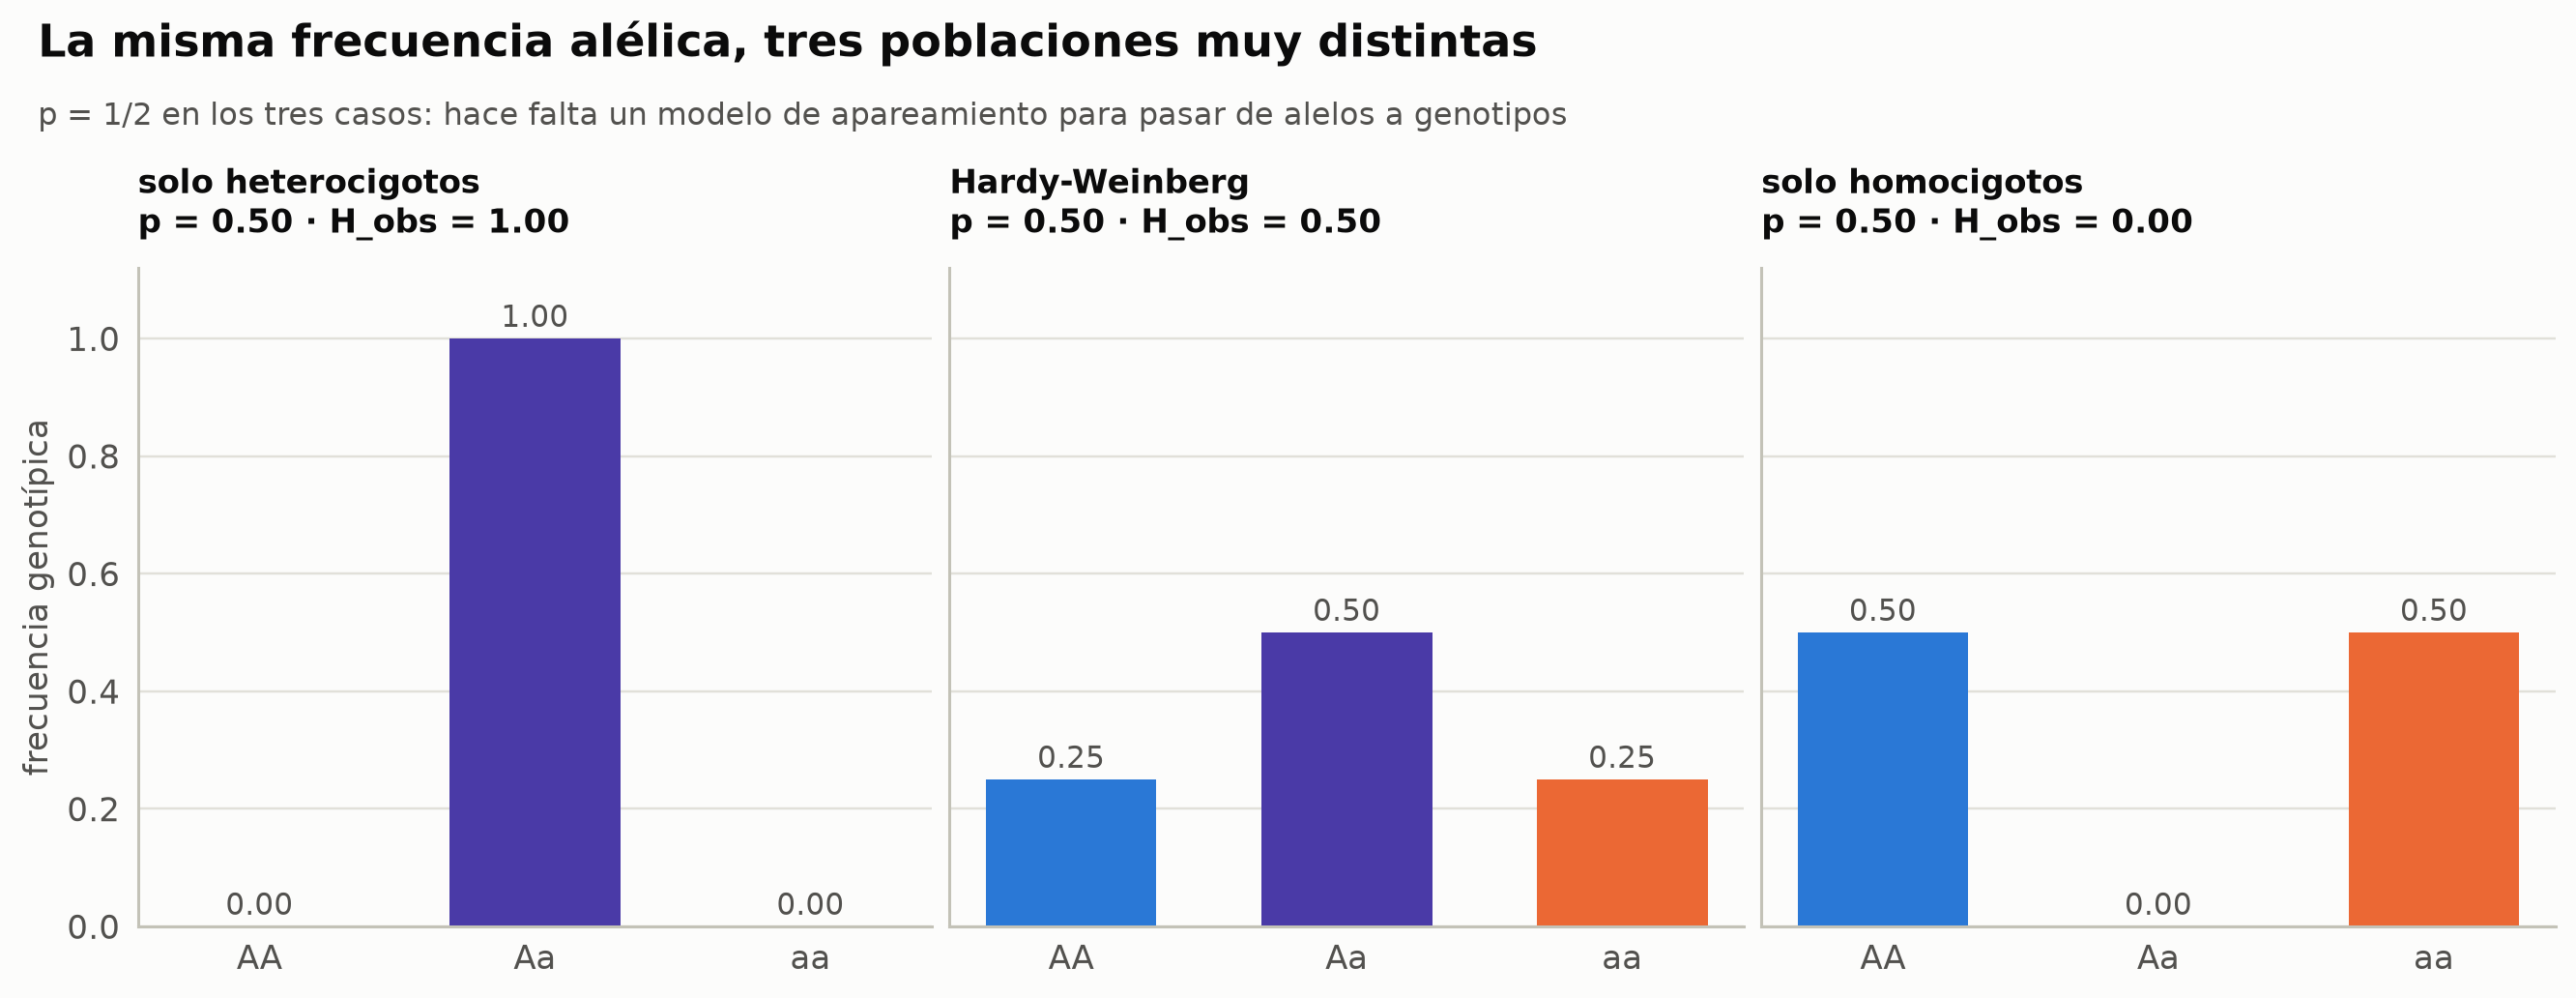

In [3]:
pops = {"solo heterocigotos": (0, 100, 0), "Hardy-Weinberg": (25, 50, 25), "solo homocigotos": (50, 0, 50)}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.9), sharey=True)
for ax, (name, c) in zip(axes, pops.items()):
    f = allele_freqs(*c)
    bars = ax.bar(["AA", "Aa", "aa"], [f["P_AA"], f["P_Aa"], f["P_aa"]],
                  color=[GENO_COLORS[g] for g in ("AA", "Aa", "aa")], width=0.62)
    for b, v in zip(bars, (f["P_AA"], f["P_Aa"], f["P_aa"])):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=10, color=ec.INK_2)
    ax.set_title(f"{name}\np = {f['p']:.2f} · H_obs = {f['H_obs']:.2f}", fontsize=11, color=ec.INK)
    ax.set_ylim(0, 1.12)
axes[0].set_ylabel("frecuencia genotípica")
ec.fig_title(fig, "La misma frecuencia alélica, tres poblaciones muy distintas",
             "p = 1/2 en los tres casos: hace falta un modelo de apareamiento para pasar de alelos a genotipos")
plt.show()

> 🔎 **Qué observamos.** Las tres barras de la izquierda y de la derecha tienen $p=0{,}5$, pero una población es
> toda heterocigota y la otra no tiene ni un heterocigoto. El paso de alelos a genotipos exige un **modelo** de cómo
> se forman las parejas: ese modelo es el principio de Hardy-Weinberg.

## 2. El principio de Hardy-Weinberg

Suponga una población **muy grande**, con apareamiento **al azar** respecto del locus y sin selección, mutación ni
migración. Cada individuo de la generación siguiente nace de unir **dos gametos** tomados independientemente de un
mismo «fondo» de gametos en el que el alelo $A$ tiene frecuencia $p$. Es como sacar dos canicas de la bolsa:

* ambas $A$: $p\cdot p=p^2$;
* ambas $a$: $q\cdot q=q^2$;
* una de cada: $pq+qp=2pq$, porque la $A$ puede venir del padre **o** de la madre.

**A mano.** Con $p=0{,}6$: $P_{AA}=0{,}36$, $P_{Aa}=2(0{,}6)(0{,}4)=0{,}48$, $P_{aa}=0{,}16$; suman 1. Y la frecuencia
alélica de los hijos es $0{,}36+\tfrac12\,0{,}48=0{,}6$: no cambió.

**Equilibrio de Hardy-Weinberg (ecuación 10.2 del libro).** Bajo apareamiento aleatorio en una población infinita,
sin selección, mutación ni migración, tras **una sola** generación

$$
P_{AA}=p^2,\qquad P_{Aa}=2pq,\qquad P_{aa}=q^2,\qquad\text{y}\qquad p'=p^2+\tfrac12\,2pq=p(p+q)=p .
$$

| Símbolo | Significado |
|---|---|
| $p^2,\ 2pq,\ q^2$ | términos de $(p+q)^2$: probabilidades de los tres genotipos al unir dos gametos independientes |
| $p'$ | frecuencia del alelo $A$ en la generación siguiente |

Dos consecuencias: el equilibrio se alcanza en **una** generación desde cualquier punto de partida, y la herencia
mendeliana **conserva** la variación: un alelo dominante no aumenta por ser dominante, ni un recesivo desaparece por
quedar oculto en los heterocigotos.

> 📜 **Un poco de historia: un matemático puro responde a los biólogos.** En 1908, varios biólogos británicos
> discutían si un carácter dominante, como la braquidactilia, debía volverse inevitablemente más frecuente hasta la
> proporción mendeliana 3:1. G. H. Hardy, matemático orgulloso de la inutilidad práctica de su obra, escribió a
> *Science* una carta de dos páginas mostrando, con álgebra de bachillerato, que cualquier proporción $p^2:2pq:q^2$ es
> estable (Hardy, 1908). El médico alemán Wilhelm Weinberg llegó al mismo resultado ese año, y por eso el principio
> lleva ambos nombres.

> 🤔 **Antes de ejecutar, prediga.** Una población fundada solo con homocigotos, 500 $AA$ y 500 $aa$, se aparea al
> azar. ¿Qué fracción de heterocigotos tendrá la primera generación de hijos? ¿Y la segunda?

In [4]:
rng_demo = np.random.default_rng(2024)

def random_mating(genotypes, n_offspring, rng):
    """Una generación de apareamiento aleatorio: cada hijo recibe un alelo al azar de cada uno de dos padres
    elegidos al azar. Los genotipos se codifican como copias de A (0, 1, 2)."""
    mothers = rng.choice(genotypes, n_offspring)
    fathers = rng.choice(genotypes, n_offspring)
    return rng.binomial(1, mothers / 2) + rng.binomial(1, fathers / 2)

pop = np.array([2] * 500 + [0] * 500)
rows = []
for gen in range(4):
    rows.append(dict(generación=gen, AA=(pop == 2).mean(), Aa=(pop == 1).mean(), aa=(pop == 0).mean(),
                     p=pop.mean() / 2))
    pop = random_mating(pop, 100_000, rng_demo)   # hijos numerosos: casi una población infinita
pd.DataFrame(rows).round(3)

,generación,AA,Aa,aa,p
0,0,0.500,0.000,0.500,0.500
1,1,0.250,0.500,0.250,0.500
2,2,0.252,0.497,0.251,0.500
3,3,0.250,0.501,0.248,0.501


> 🔎 **Qué observamos.** De $0:1{:}0$ heterocigotos se pasa en **una** generación a $\approx\tfrac14:\tfrac12:\tfrac14$,
> y allí se queda. La frecuencia alélica tampoco se mueve de 0,5.

### Dos maneras de mirar el equilibrio

La figura de la izquierda dibuja $p^2$, $2pq$ y $q^2$ en función de $p$. La de la derecha es el **triángulo de De
Finetti**: cada población es un punto cuyas **distancias a los tres lados** son sus tres frecuencias genotípicas (el
vértice $Aa$ arriba es una población de puros heterocigotos). Las poblaciones en equilibrio viven sobre una
**parábola**. Reproducimos la figura del libro con **su misma semilla** (1908): 25 muestras de 200 personas de
poblaciones en equilibrio y 12 de poblaciones endogámicas con $F=0{,}3$ (el parámetro $F$ se explica en la sección 3).

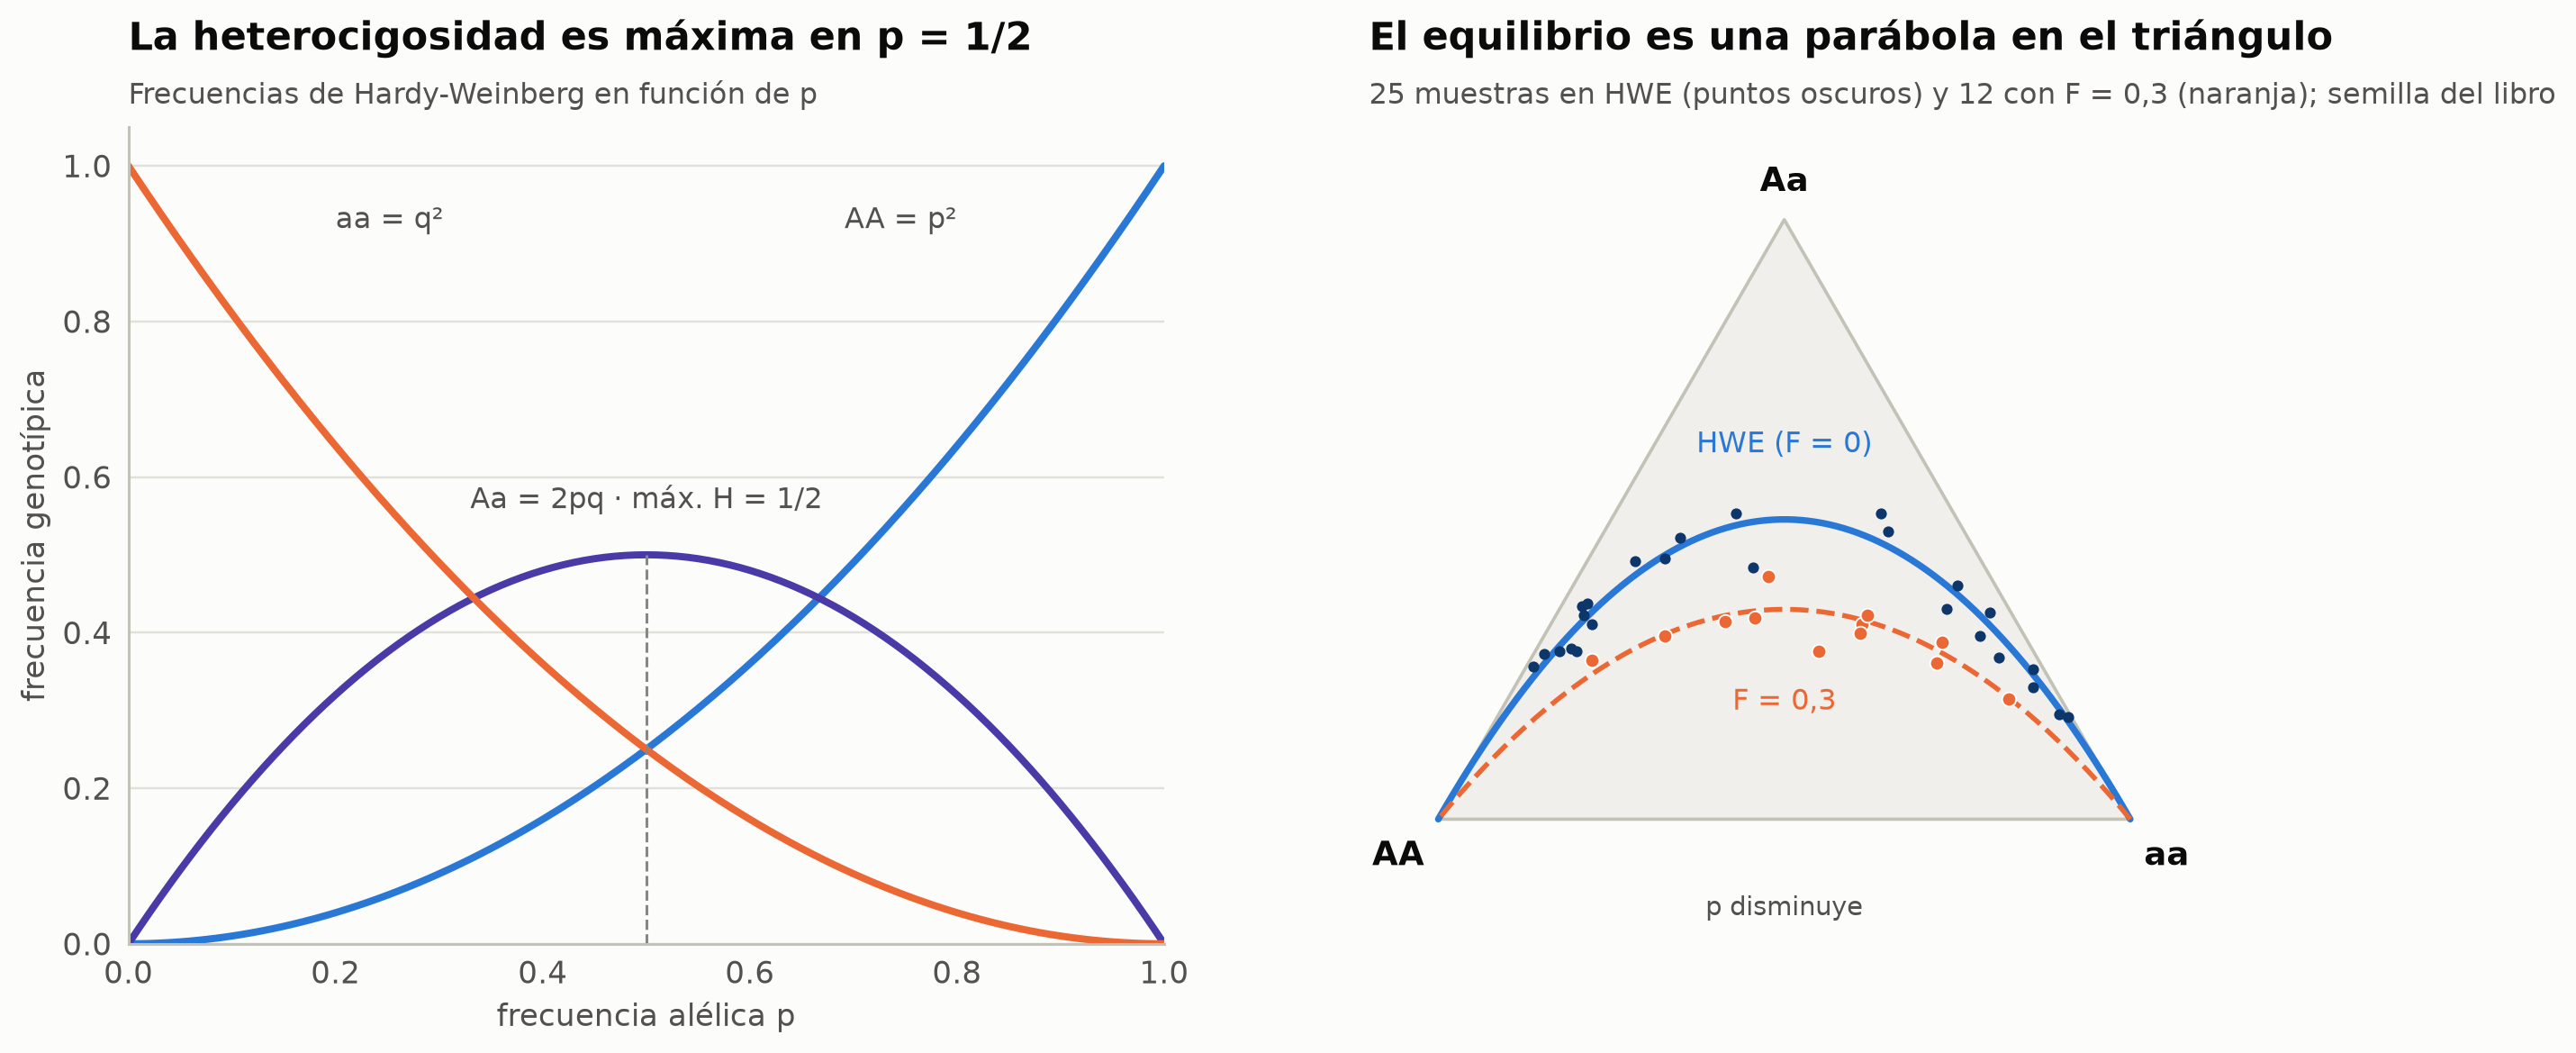

Con q = 0.01: fracción de las copias de a que viven en heterocigotos = 99%


In [5]:
S3 = math.sqrt(3) / 2

def tern(fAA, fAa, faa):
    """Coordenadas cartesianas en el triángulo de De Finetti (AA abajo a la izquierda, aa a la derecha, Aa arriba)."""
    return np.array([faa + fAa / 2, fAa * S3])

def definetti_samples(rng):
    """Las muestras simuladas de la figura 10.1 del libro, en el mismo orden de sorteo."""
    pts_hwe, pts_F = [], []
    for _ in range(25):                      # muestras de n = 200 de poblaciones en HWE
        q = rng.uniform(0.1, 0.9)
        c = rng.multinomial(200, [q * q, 2 * q * (1 - q), (1 - q) ** 2]) / 200
        pts_hwe.append(tern(*c))
    for _ in range(12):                      # poblaciones endogámicas, F = 0.3
        q = rng.uniform(0.15, 0.85); F = 0.3
        pr = [q * q + F * q * (1 - q), 2 * q * (1 - q) * (1 - F), (1 - q) ** 2 + F * q * (1 - q)]
        pts_F.append(tern(*rng.multinomial(200, pr) / 200))
    return np.array(pts_hwe), np.array(pts_F)

pts_hwe, pts_F = definetti_samples(np.random.default_rng(1908))
pp = np.linspace(0, 1, 201)
par = np.array([tern(x * x, 2 * x * (1 - x), (1 - x) ** 2) for x in pp])
par_F = np.array([tern(x * x + 0.3 * x * (1 - x), 2 * x * (1 - x) * 0.7, (1 - x) ** 2 + 0.3 * x * (1 - x)) for x in pp])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw=dict(width_ratios=[1, 1.1]))
for lab, y in (("AA = p²", pp ** 2), ("Aa = 2pq", 2 * pp * (1 - pp)), ("aa = q²", (1 - pp) ** 2)):
    a1.plot(pp, y, lw=2.6, color=GENO_COLORS[lab[:2]])
a1.text(0.80, 0.92, "AA = p²", color=ec.INK_2, fontsize=10.5, ha="right")
a1.text(0.20, 0.92, "aa = q²", color=ec.INK_2, fontsize=10.5)
a1.text(0.5, 0.56, "Aa = 2pq · máx. H = 1/2", color=ec.INK_2, fontsize=10.5, ha="center")
a1.axvline(0.5, ymax=0.5 / 1.05, color=ec.MUTED, ls="--", lw=1)
a1.set_xlim(0, 1); a1.set_ylim(0, 1.05); a1.set_xlabel("frecuencia alélica p"); a1.set_ylabel("frecuencia genotípica")
ec.title(a1, "La heterocigosidad es máxima en p = 1/2", "Frecuencias de Hardy-Weinberg en función de p")

tri = np.array([[0, 0], [1, 0], [0.5, S3], [0, 0]])
a2.fill(tri[:, 0], tri[:, 1], color="#f0efec", lw=0); a2.plot(tri[:, 0], tri[:, 1], color=ec.BASELINE, lw=1.2)
a2.plot(par[:, 0], par[:, 1], color=ec.BLUE, lw=2.4)
a2.plot(par_F[:, 0], par_F[:, 1], color=ec.ORANGE, lw=1.8, ls="--")
a2.scatter(pts_hwe[:, 0], pts_hwe[:, 1], s=16, color="#0d366b", zorder=3)
a2.scatter(pts_F[:, 0], pts_F[:, 1], s=26, color=ec.ORANGE, edgecolor="white", lw=0.6, zorder=3)
a2.text(-0.02, -0.03, "AA", ha="right", va="top", fontsize=12, fontweight="bold")
a2.text(1.02, -0.03, "aa", ha="left", va="top", fontsize=12, fontweight="bold")
a2.text(0.5, S3 + 0.03, "Aa", ha="center", va="bottom", fontsize=12, fontweight="bold")
a2.text(0.5, 0.53, "HWE (F = 0)", color=ec.BLUE, ha="center", fontsize=10.5)
a2.text(0.5, 0.19, "F = 0,3", color=ec.ORANGE, ha="center", va="top", fontsize=10.5)
a2.annotate("", xy=(0.88, -0.09), xytext=(0.12, -0.09), arrowprops=dict(arrowstyle="->", color=ec.MUTED))
a2.text(0.5, -0.11, "p disminuye", ha="center", va="top", fontsize=9.5, color=ec.INK_2)
a2.set_xlim(-0.1, 1.1); a2.set_ylim(-0.18, 1.0); a2.set_aspect("equal"); a2.axis("off")
ec.title(a2, "El equilibrio es una parábola en el triángulo", "25 muestras en HWE (puntos oscuros) y 12 con F = 0,3 (naranja); semilla del libro")
plt.show()
q_rare = 0.01
# copias de a en heterocigotos: 2pq·1 ; en homocigotos aa: q²·2  →  fracción = 2pq / (2pq + 2q²) = p
p_rare = 1 - q_rare
print(f"Con q = {q_rare}: fracción de las copias de a que viven en heterocigotos = "
      f"{2*p_rare*q_rare / (2*p_rare*q_rare + 2*q_rare**2):.0%}")

> 🔎 **Qué observamos.** Los puntos oscuros se dispersan **alrededor** de la parábola solo por azar muestral (200
> personas no son infinitas); los naranjas caen **sistemáticamente por debajo**: les faltan heterocigotos. Y con un
> alelo raro ($q=0{,}01$) el 99 % de sus copias vive en heterocigotos sanos: por eso las enfermedades recesivas raras
> no se pueden «eliminar» impidiendo que los afectados tengan hijos, idea que ya desmontaba el álgebra de Hardy.

> ✅ **Compruebe su comprensión.** ¿En qué punto del triángulo cae una población con $p=1$? ¿Y una población en
> equilibrio con $p=1/2$? *(En el vértice $AA$; en el punto más alto de la parábola, con $P_{Aa}=1/2$, a media altura
> del triángulo.)*

## 3. Contrastar el equilibrio: prueba $\chi^2$, endogamia y prueba exacta

En la práctica el principio se usa **al revés**: dados los recuentos observados, ¿son compatibles con el equilibrio?
Es lo que hace un laboratorio de genotipado antes de entregar un chip: si en una variante faltan muchos
heterocigotos, sospecha del ensayo antes que de la biología.

### El estadístico de Pearson

Se comparan los recuentos observados $O_k$ con los esperados $E_k$ bajo Hardy-Weinberg, usando la $\hat p$ de la
propia muestra (ecuación 10.3 del libro):

$$
X^2=\sum_{k\in\{AA,Aa,aa\}}\frac{(O_k-E_k)^2}{E_k},\qquad E_{AA}=n\hat p^2,\quad E_{Aa}=2n\hat p\hat q,\quad E_{aa}=n\hat q^2 .
$$

| Símbolo | Significado |
|---|---|
| $O_k,\ E_k$ | recuento observado y esperado del genotipo $k$ |
| $\hat p,\ \hat q$ | frecuencias alélicas estimadas en la propia muestra |
| $X^2$ | estadístico de Pearson; bajo el equilibrio sigue aproximadamente una $\chi^2$ con **un** grado de libertad |

¿Por qué **un** grado de libertad si hay tres categorías? Los tres recuentos suman $n$ (se pierde uno) y $p$ se
estima de los mismos datos (se pierde otro): $3-1-1=1$.

### Endogamia y el coeficiente $F$

La desviación más común es un **déficit de heterocigotos**. Aparece cuando se aparean parientes, o cuando la
«población» es en realidad una **mezcla** de subpoblaciones con frecuencias distintas (**efecto Wahlund**, que
veremos con datos reales en la sección 8). Ambos casos se describen con el **coeficiente de endogamia** $F$, la
probabilidad de que las dos copias de un individuo sean **idénticas por descendencia** (ecuación 10.4):

$$
P_{AA}=p^2+Fpq,\qquad P_{Aa}=2pq(1-F),\qquad P_{aa}=q^2+Fpq,\qquad \hat F=1-\frac{H_{\text{obs}}}{2\hat p\hat q}.
$$

| Símbolo | Significado |
|---|---|
| $F$ | coeficiente de endogamia: $0$ en equilibrio, $1$ si todos son homocigotos; negativo = exceso de heterocigotos |
| $H_{\text{obs}}$ | proporción observada de heterocigotos |

### Ejemplo del libro: «Dos muestras de mil personas»

Dos lotes de 1 000 muestras genotipadas para el mismo SNP. Primer lote: 298 $AA$, 489 $Aa$ y 213 $aa$. A mano:
$\hat p=(2\cdot298+489)/2000=0{,}5425$; esperados $1000\cdot0{,}5425^2=294{,}3$, $496{,}4$ y $209{,}3$. Segundo lote:
350, 380 y 270, con $\hat p=0{,}54$. Comprobémoslo:

In [6]:
def hwe_chi2(n_AA, n_Aa, n_aa):
    """Prueba chi-cuadrado de Hardy-Weinberg (1 g.l.) y F estimado (ecuaciones 10.3 y 10.4 del libro)."""
    n = n_AA + n_Aa + n_aa
    p = (2 * n_AA + n_Aa) / (2 * n)
    expected = n * np.array([p ** 2, 2 * p * (1 - p), (1 - p) ** 2])
    observed = np.array([n_AA, n_Aa, n_aa])
    x2 = ((observed - expected) ** 2 / expected).sum()
    return dict(p=p, expected=expected, X2=x2, pval=stats.chi2.sf(x2, 1), F=1 - n_Aa / expected[1])

book = {"lote 1 (298, 489, 213)": (298, 489, 213), "lote 2 (350, 380, 270)": (350, 380, 270)}
for name, obs in book.items():
    r = hwe_chi2(*obs)
    print(f"{name}: p̂ = {r['p']:.4f} · esperados = {np.round(r['expected'], 1)} · X² = {r['X2']:.3f} · "
          f"p = {r['pval']:.3g} · F̂ = {r['F']:.3f}")
print("libro: lote 1 X² = 0,221, p = 0,64, F̂ = 0,015 · lote 2 X² = 55,3, p ≈ 10⁻¹³, F̂ = 0,235")

lote 1 (298, 489, 213): p̂ = 0.5425 · esperados = [294.3 496.4 209.3] · X² = 0.221 · p = 0.638 · F̂ = 0.015
lote 2 (350, 380, 270): p̂ = 0.5400 · esperados = [291.6 496.8 211.6] · X² = 55.274 · p = 1.05e-13 · F̂ = 0.235
libro: lote 1 X² = 0,221, p = 0,64, F̂ = 0,015 · lote 2 X² = 55,3, p ≈ 10⁻¹³, F̂ = 0,235


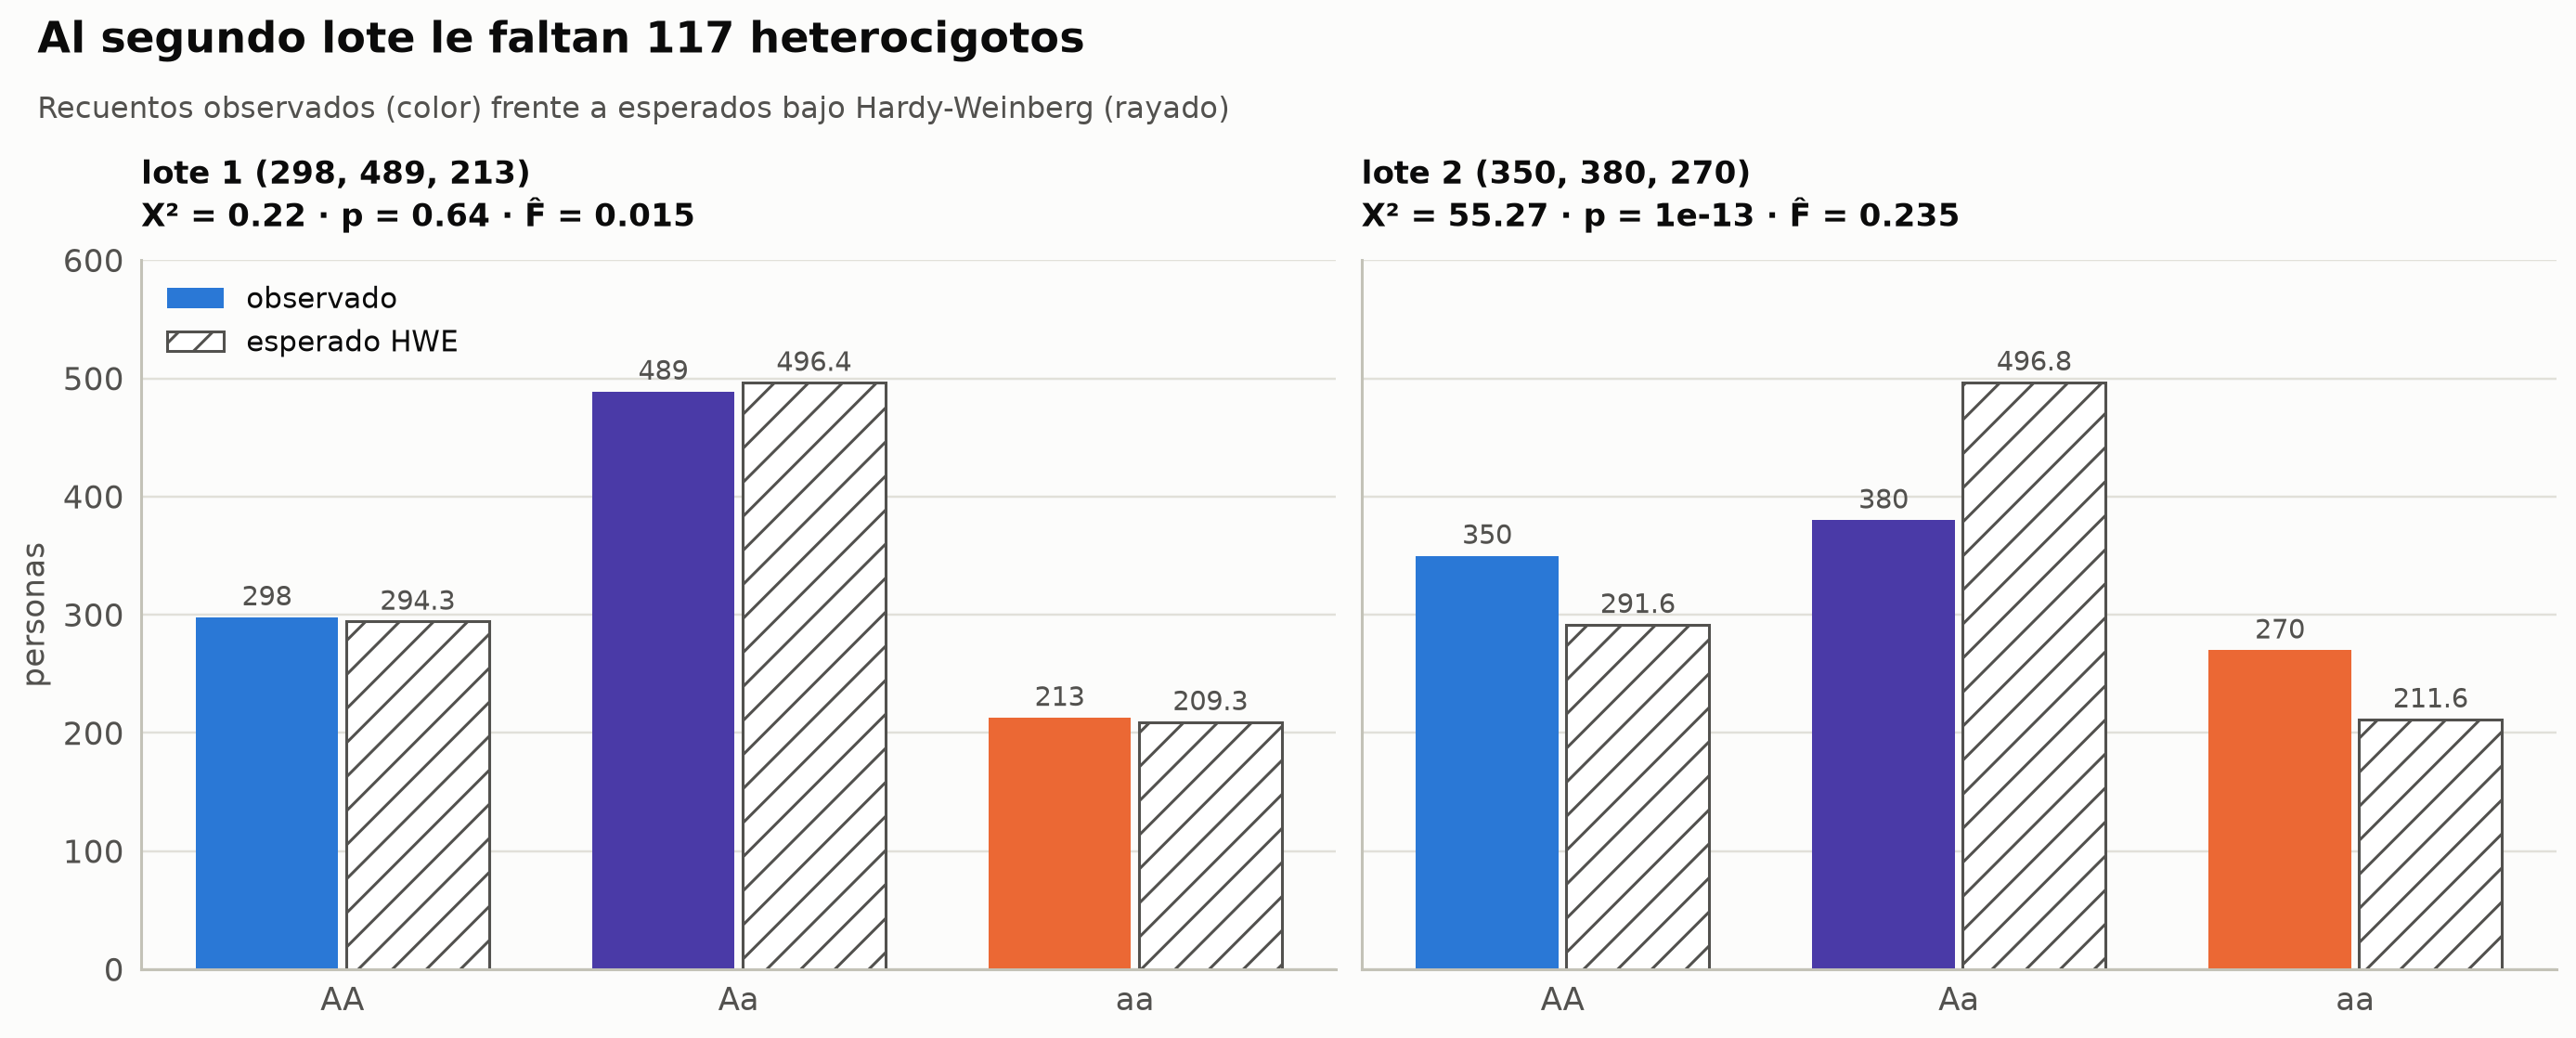

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3), sharey=True)
for ax, (name, obs) in zip(axes, book.items()):
    r = hwe_chi2(*obs)
    x = np.arange(3)
    ax.bar(x - 0.19, obs, width=0.36, color=[GENO_COLORS[g] for g in ("AA", "Aa", "aa")], label="observado")
    ax.bar(x + 0.19, r["expected"], width=0.36, color="white", edgecolor=ec.INK_2, hatch="//", lw=1, label="esperado HWE")
    for i in range(3):
        ax.text(i - 0.19, obs[i] + 10, f"{obs[i]}", ha="center", fontsize=9.5, color=ec.INK_2)
        ax.text(i + 0.19, r["expected"][i] + 10, f"{r['expected'][i]:.1f}", ha="center", fontsize=9.5, color=ec.INK_2)
    ax.set_xticks(x, ["AA", "Aa", "aa"]); ax.set_ylim(0, 600)
    ax.set_title(f"{name}\nX² = {r['X2']:.2f} · p = {r['pval']:.2g} · F̂ = {r['F']:.3f}", fontsize=11)
axes[0].set_ylabel("personas"); axes[0].legend(frameon=False, loc="upper left")
ec.fig_title(fig, "Al segundo lote le faltan 117 heterocigotos",
             "Recuentos observados (color) frente a esperados bajo Hardy-Weinberg (rayado)")
plt.show()

> 🔎 **Qué observamos.** El primer lote es indistinguible del equilibrio. En el segundo, los homocigotos sobran y
> faltan 117 heterocigotos: $X^2=55{,}3$, $p\approx10^{-13}$ y $\hat F=1-380/496{,}8=0{,}235$. En humanos exogámicos
> un $\hat F$ así casi nunca es endogamia real, sino un **problema técnico**: un ensayo que no detecta bien uno de los
> alelos y «convierte» heterocigotos en homocigotos.

### La prueba exacta de Wigginton, Cutler y Abecasis

La aproximación $\chi^2$ falla cuando algún $E_k$ es pequeño, y eso ocurre precisamente con las **variantes raras**,
las protagonistas de la era de la secuenciación. Wigginton et al. (2005) propusieron un algoritmo rápido para la
**prueba exacta**. Condicionando en el número de copias del alelo raro, $n_a=2n_{aa}+n_{Aa}$, la probabilidad de
observar exactamente $n_{Aa}$ heterocigotos bajo el equilibrio es (ecuación 10.5)

$$
\Pr(N_{Aa}=n_{Aa}\mid n,n_a)=\frac{2^{n_{Aa}}\,n!}{n_{AA}!\,n_{Aa}!\,n_{aa}!}\cdot\frac{n_A!\,n_a!}{(2n)!},
$$

y el valor $p$ es la suma de las probabilidades de todas las configuraciones **tan o menos probables** que la
observada. En lugar de factoriales enormes, el algoritmo parte de la configuración más probable y recorre las demás
con la razón entre términos consecutivos (ecuación 10.6), que resulta de convertir dos heterocigotos en un homocigoto
de cada tipo:

$$
\frac{\Pr(n_{Aa}-2)}{\Pr(n_{Aa})}=\frac{n_{Aa}\,(n_{Aa}-1)}{4\,(n_{aa}+1)\,(n_{AA}+1)} .
$$

| Símbolo | Significado |
|---|---|
| $n_A,\ n_a$ | copias de cada alelo en la muestra ($n_A+n_a=2n$), fijas en el condicionamiento |
| $N_{Aa}$ | número aleatorio de heterocigotos; tiene la misma paridad que $n_a$ |

### Ejemplo del libro: «Cuando la aproximación $\chi^2$ engaña»

Entre 100 personas se observan 91 $AA$, 7 $Aa$ y 2 $aa$ ($\hat q=0{,}055$). Los esperados son 89,3, 10,4 y **0,30**: el
recuento esperado de $aa$ es diminuto y los dos homocigotos observados pesan enormemente en $X^2$.

> 🤔 **Antes de ejecutar, prediga.** ¿Será el valor $p$ exacto mayor o menor que el de $\chi^2$? ¿Por cuánto?

In [8]:
def hwe_exact(n_het, n_hom1, n_hom2, return_probs=False):
    """Valor p exacto de HWE (Wigginton et al., 2005). Listado hwe_exacta.py del libro."""
    n = n_het + n_hom1 + n_hom2
    n_rare = 2 * min(n_hom1, n_hom2) + n_het
    P = np.zeros(n_rare + 1)
    h = n_rare * (2 * n - n_rare) // (2 * n)      # moda aproximada
    h += (h % 2) != (n_rare % 2)                  # misma paridad
    P[h] = 1.0
    r = (n_rare - h) // 2; c = n - h - r
    for k in range(h, 1, -2):                     # hacia menos heterocigotos
        P[k - 2] = P[k] * k * (k - 1) / (4 * (r + 1) * (c + 1))
        r += 1; c += 1
    r = (n_rare - h) // 2; c = n - h - r
    for k in range(h, n_rare - 1, 2):             # hacia más heterocigotos
        P[k + 2] = P[k] * 4 * r * c / ((k + 2) * (k + 1))
        r -= 1; c -= 1
    P /= P.sum()
    pval = P[P <= P[n_het] * (1 + 1e-9)].sum()
    return (pval, P) if return_probs else pval

p_ex, P_ex = hwe_exact(7, 91, 2, return_probs=True)
r = hwe_chi2(91, 7, 2)
print(f"q̂ = {1 - r['p']:.3f} · esperados = {np.round(r['expected'], 2)} · X² = {r['X2']:.2f} · p(χ²) = {r['pval']:.4f}")
print(f"p exacto = {p_ex:.4f}   (libro: X² = 10,67, p = 0,0011; exacto 0,0235)")
print("P(n_Aa):", {k: round(float(v), 4) for k, v in enumerate(P_ex) if k % 2 == 1})

q̂ = 0.055 · esperados = [89.3 10.4  0.3] · X² = 10.67 · p(χ²) = 0.0011
p exacto = 0.0235   (libro: X² = 10,67, p = 0,0011; exacto 0,0235)
P(n_Aa): {1: 0.0, 3: 0.0, 5: 0.0009, 7: 0.0226, 9: 0.2285, 11: 0.748}


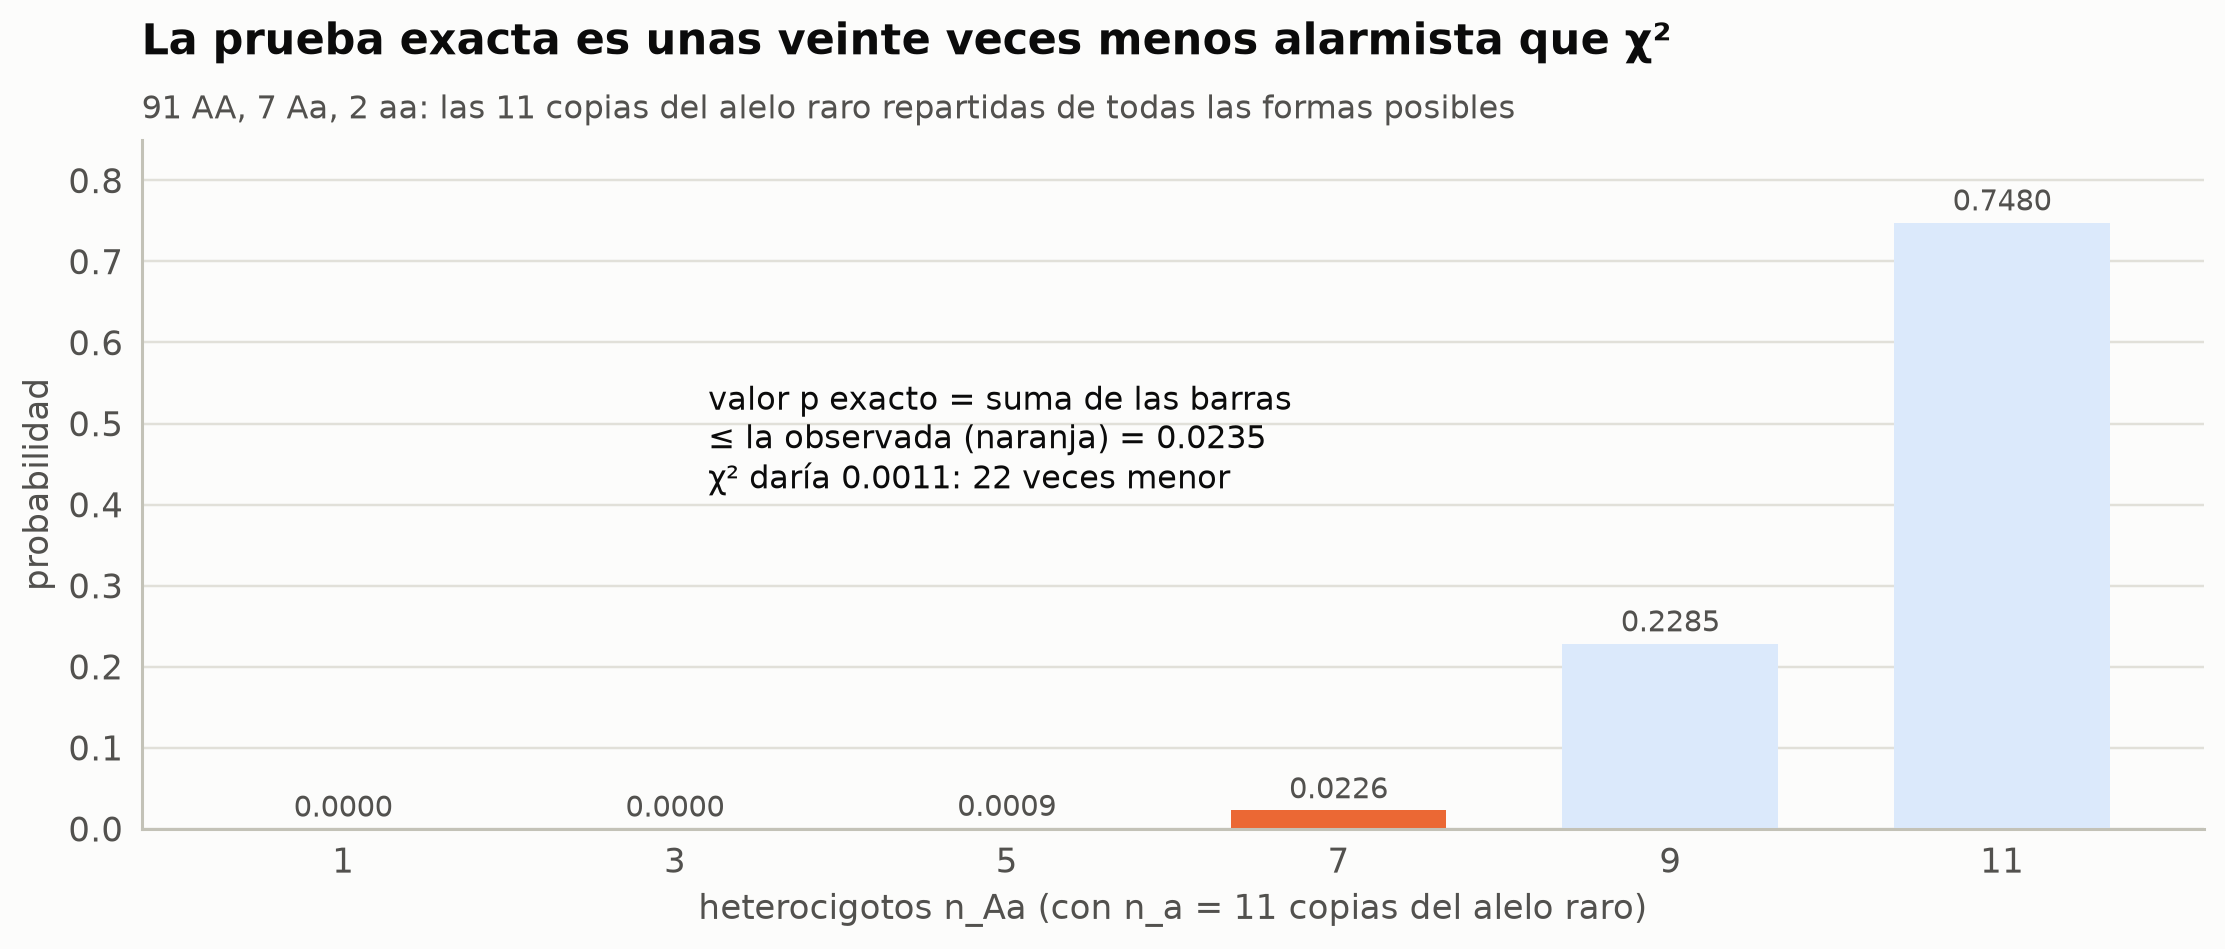

In [9]:
ks = np.arange(1, len(P_ex), 2)
fig, ax = plt.subplots(figsize=(10, 4.2))
cols = [ec.ORANGE if k == 7 else ("#9ec5f4" if P_ex[k] <= P_ex[7] * (1 + 1e-9) else "#dbe9fb") for k in ks]
bars = ax.bar(ks, P_ex[ks], width=1.3, color=cols, edgecolor=[ec.BLUE if k != 7 else ec.ORANGE for k in ks])
for k in ks:
    ax.text(k, P_ex[k] + 0.015, f"{P_ex[k]:.4f}", ha="center", fontsize=9.5, color=ec.INK_2)
ax.set_xticks(ks); ax.set_xlabel("heterocigotos n_Aa (con n_a = 11 copias del alelo raro)"); ax.set_ylabel("probabilidad")
ax.set_ylim(0, 0.85)
ax.text(3.2, 0.42, f"valor p exacto = suma de las barras\n≤ la observada (naranja) = {p_ex:.4f}\n"
        f"χ² daría {r['pval']:.4f}: {p_ex / r['pval']:.0f} veces menor", fontsize=10.5, color=ec.INK)
ec.title(ax, "La prueba exacta es unas veinte veces menos alarmista que χ²",
         "91 AA, 7 Aa, 2 aa: las 11 copias del alelo raro repartidas de todas las formas posibles")
plt.show()

> 🔎 **Qué observamos.** Con 11 copias del alelo raro, lo más probable bajo el equilibrio es que casi todas estén en
> heterocigotos (11 het: 0,748). Observar solo 7 es poco común, pero no escandaloso: $p=0{,}0226+0{,}0009+\dots=0{,}0235$.
> Con el umbral típico de control de calidad de un GWAS ($p<10^{-6}$) ninguna prueba descartaría la variante; pero en
> un análisis de **miles** de variantes raras, $\chi^2$ produciría un exceso sistemático de falsos rechazos. Lo
> comprobamos simulando muestras que **sí** están en equilibrio:

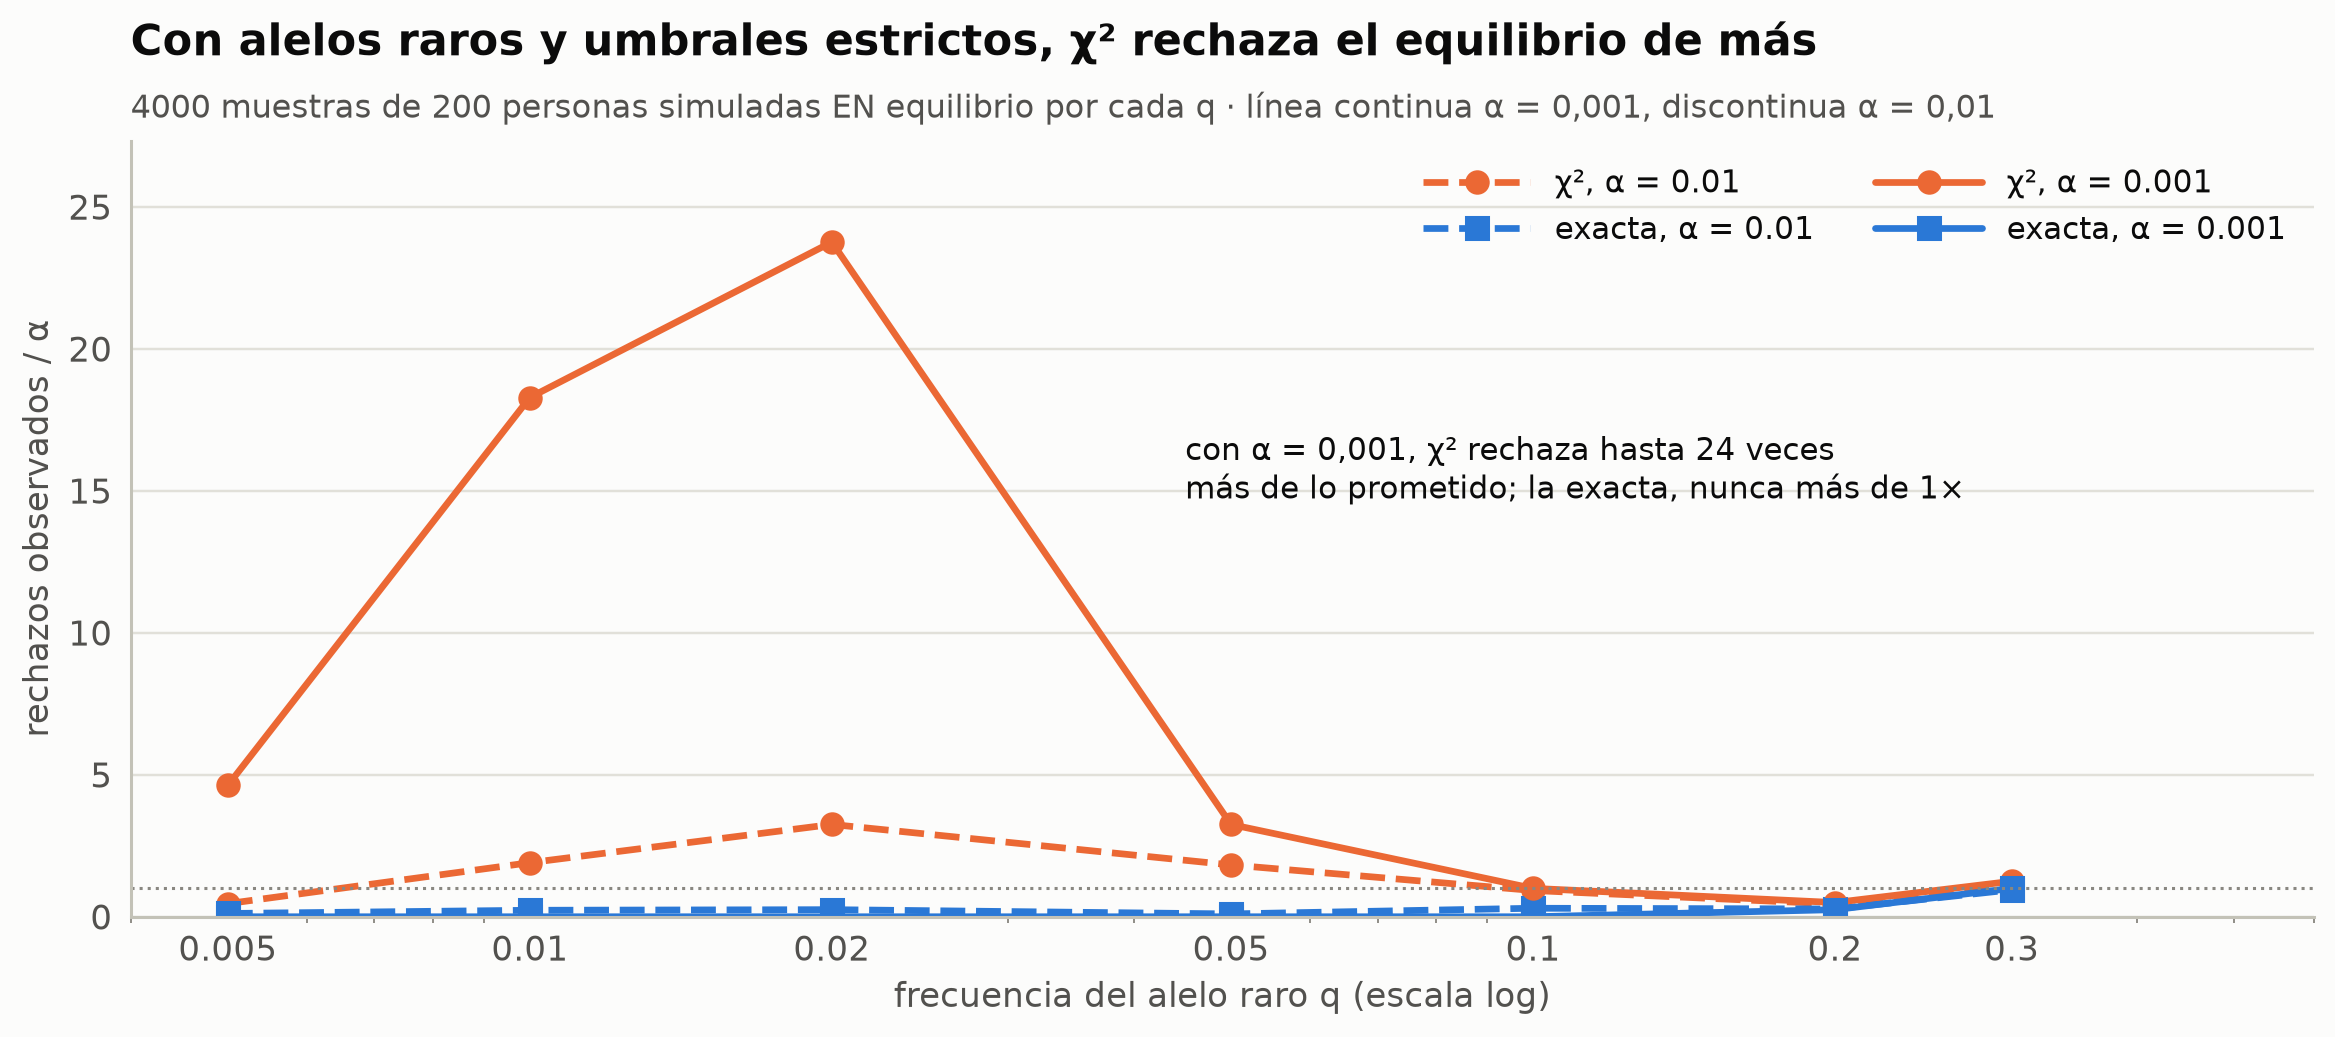

,q,alpha,chi2,exacta
0,0.005,0.010,0.463,0.116
1,0.005,0.001,4.628,0.000
2,0.010,0.010,1.905,0.229
3,0.010,0.001,18.288,0.000
4,0.020,0.010,3.252,0.250
5,0.020,0.001,23.762,0.000
6,0.050,0.010,1.825,0.100
7,0.050,0.001,3.250,0.000
8,0.100,0.010,0.925,0.300
9,0.100,0.001,1.000,0.000


In [10]:
rng_cal = np.random.default_rng(7)
qs = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]
alphas = [0.01, 0.001]
n_ind, n_sim = 200, 4000
rows = []
for q in qs:
    g = rng_cal.multinomial(n_ind, [(1 - q) ** 2, 2 * q * (1 - q), q * q], size=n_sim)
    g = g[(g[:, 1] + g[:, 2] > 0) & (g[:, 0] + g[:, 1] > 0)]          # descartamos las monomórficas
    p_chi = np.array([hwe_chi2(*x)["pval"] for x in g])
    p_ex = np.array([hwe_exact(x[1], x[0], x[2]) for x in g])
    for a in alphas:
        rows.append(dict(q=q, alpha=a, chi2=(p_chi < a).mean() / a, exacta=(p_ex < a).mean() / a))
cal = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10.5, 4.6))
for a, ls in zip(alphas, ("--", "-")):
    d = cal[cal.alpha == a]
    ax.plot(d.q, d.chi2, ls, marker="o", color=ec.ORANGE, lw=2.2, label=f"χ², α = {a}")
    ax.plot(d.q, d.exacta, ls, marker="s", color=ec.BLUE, lw=2.2, label=f"exacta, α = {a}")
d = cal[cal.alpha == 0.001]
ax.text(0.045, d.chi2.max() * 0.62, f"con α = 0,001, χ² rechaza hasta {d.chi2.max():.0f} veces\nmás de lo prometido; la exacta, nunca más de 1×",
        fontsize=10, color=ec.INK)
ax.axhline(1, color=ec.MUTED, ls=":", lw=1)
ax.legend(frameon=False, loc="upper right", ncol=2, handlelength=3.5)
ax.set_xscale("log"); ax.set_xticks(qs, [str(q) for q in qs]); ax.set_xlim(0.004, 0.6)
ax.set_xlabel("frecuencia del alelo raro q (escala log)"); ax.set_ylabel("rechazos observados / α")
ax.set_ylim(0, cal.chi2.max() * 1.15)
ec.title(ax, "Con alelos raros y umbrales estrictos, χ² rechaza el equilibrio de más",
         f"{n_sim} muestras de {n_ind} personas simuladas EN equilibrio por cada q · línea continua α = 0,001, discontinua α = 0,01")
plt.show()
cal.round(3)

> 🔎 **Qué observamos.** El eje vertical mide cuántas veces se rechaza más (o menos) de lo que promete el umbral: 1
> sería una prueba perfectamente calibrada. Con alelos comunes ($q=0{,}3$) ambas pruebas rondan el 1. Con alelos
> raros y umbrales estrictos, $\chi^2$ se dispara: un solo homocigoto raro «inesperado» (esperado 0,02) basta para un
> $X^2$ enorme. La exacta, en cambio, nunca pasa de 1: es **conservadora**, porque su distribución es discreta. Como en
> control de calidad se usan umbrales mucho más estrictos que 0,05, esta es la diferencia que importa; por eso el
> filtro de Hardy-Weinberg de PLINK implementa la prueba exacta de Wigginton et al. (Purcell et al., 2007; Chang et
> al., 2015).


> ⚠️ **El equilibrio como control de calidad.** En los GWAS, la prueba se aplica sobre todo como **filtro técnico**:
> en los controles sanos, una desviación extrema suele delatar errores de genotipado. Pero cuidado en los **casos**:
> una variante fuertemente asociada con la enfermedad puede desviarse del equilibrio **precisamente porque** es
> causal. Por eso PLINK permite filtrar solo en los controles, con umbrales muy estrictos ($10^{-6}$ a $10^{-10}$).

> ✅ **Compruebe su comprensión.** Una variante tiene $\hat F=-0{,}4$ en 5 000 controles. ¿Endogamia? *(No: $F<0$ es un
> **exceso** de heterocigotos. Es la firma típica de una variante que en realidad son dos loci parálogos casi
> idénticos colapsados en uno: cada persona «parece» heterocigota. Se descarta.)*

## 4. Deriva génica: el modelo de Wright-Fisher

Hardy-Weinberg supone una población **infinita**. En una población finita la generación siguiente es una
**muestra** de la anterior, y las muestras fluctúan, como la bolsa de canicas. Este cambio aleatorio de las
frecuencias se llama **deriva génica**, y su modelo canónico lleva el nombre de los fundadores de la genética de
poblaciones teórica, R. A. Fisher y Sewall Wright (Fisher, 1930; Wright, 1931).

**Modelo de Wright-Fisher (ecuación 10.7 del libro).** Una población de $N$ individuos diploides ($2N$ copias de un
gen) tiene generaciones discretas que no se solapan. Cada una de las $2N$ copias de la generación $t+1$ elige como
madre, de forma independiente y uniforme, una de las $2N$ copias de la generación $t$. Si $X_t$ es el número de
copias del alelo $A$,

$$
\Pr(X_{t+1}=j\mid X_t=i)=\binom{2N}{j}\left(\frac{i}{2N}\right)^{j}\left(1-\frac{i}{2N}\right)^{2N-j},\qquad i,j\in\{0,1,\dots,2N\}.
$$

| Símbolo | Significado |
|---|---|
| $N$ | número de individuos diploides; la población contiene $2N$ copias del gen |
| $X_t$ | copias del alelo $A$ en la generación $t$; $p_t=X_t/2N$ es su frecuencia |
| $i,\ j$ | estados de la cadena: copias antes y después de una generación |

**A mano, con $2N=4$.** Si hoy hay $i=2$ copias de $A$ ($p=0{,}5$), la probabilidad de que mañana haya $j=0$ es
$\binom40(0{,}5)^0(0{,}5)^4=1/16$: con una población de dos personas, ¡el alelo se pierde en una sola generación con
probabilidad 6 %! Y la de quedarse igual ($j=2$) es $\binom42/16=6/16$.

La ecuación define una **cadena de Márkov** con $2N+1$ estados: el futuro depende solo del presente. De la binomial
salen de inmediato sus dos primeros momentos (ecuación 10.8):

$$
\mathbb E[p_{t+1}\mid p_t]=p_t,\qquad \operatorname{Var}[p_{t+1}\mid p_t]=\frac{p_t(1-p_t)}{2N}.
$$

La primera igualdad dice que la deriva **no tiene dirección** ($p_t$ es una **martingala**); la segunda, que el ruido de
cada generación es inversamente proporcional al tamaño. Además, $0$ y $2N$ son estados **absorbentes**: sin
mutación, un alelo perdido no reaparece y uno fijado no se pierde. Como toda la probabilidad termina en un extremo,
la martingala da la probabilidad de fijación sin cálculo: si $u$ es la probabilidad de fijarse,
$\mathbb E[p_\infty]=u\cdot1+(1-u)\cdot0=p_0$, luego (ecuación 10.9)

$$
u(p_0)=p_0 .
$$

Una mutación neutral nueva, presente en una sola copia, se fija con probabilidad $1/2N$.

### La genealogía: la deriva vista copia a copia

Antes de simular frecuencias, dibujemos el propio modelo: 10 generaciones con $2N=8$ copias, cada copia elige una
madre al azar en la fila de arriba. Usamos la semilla del libro (48).

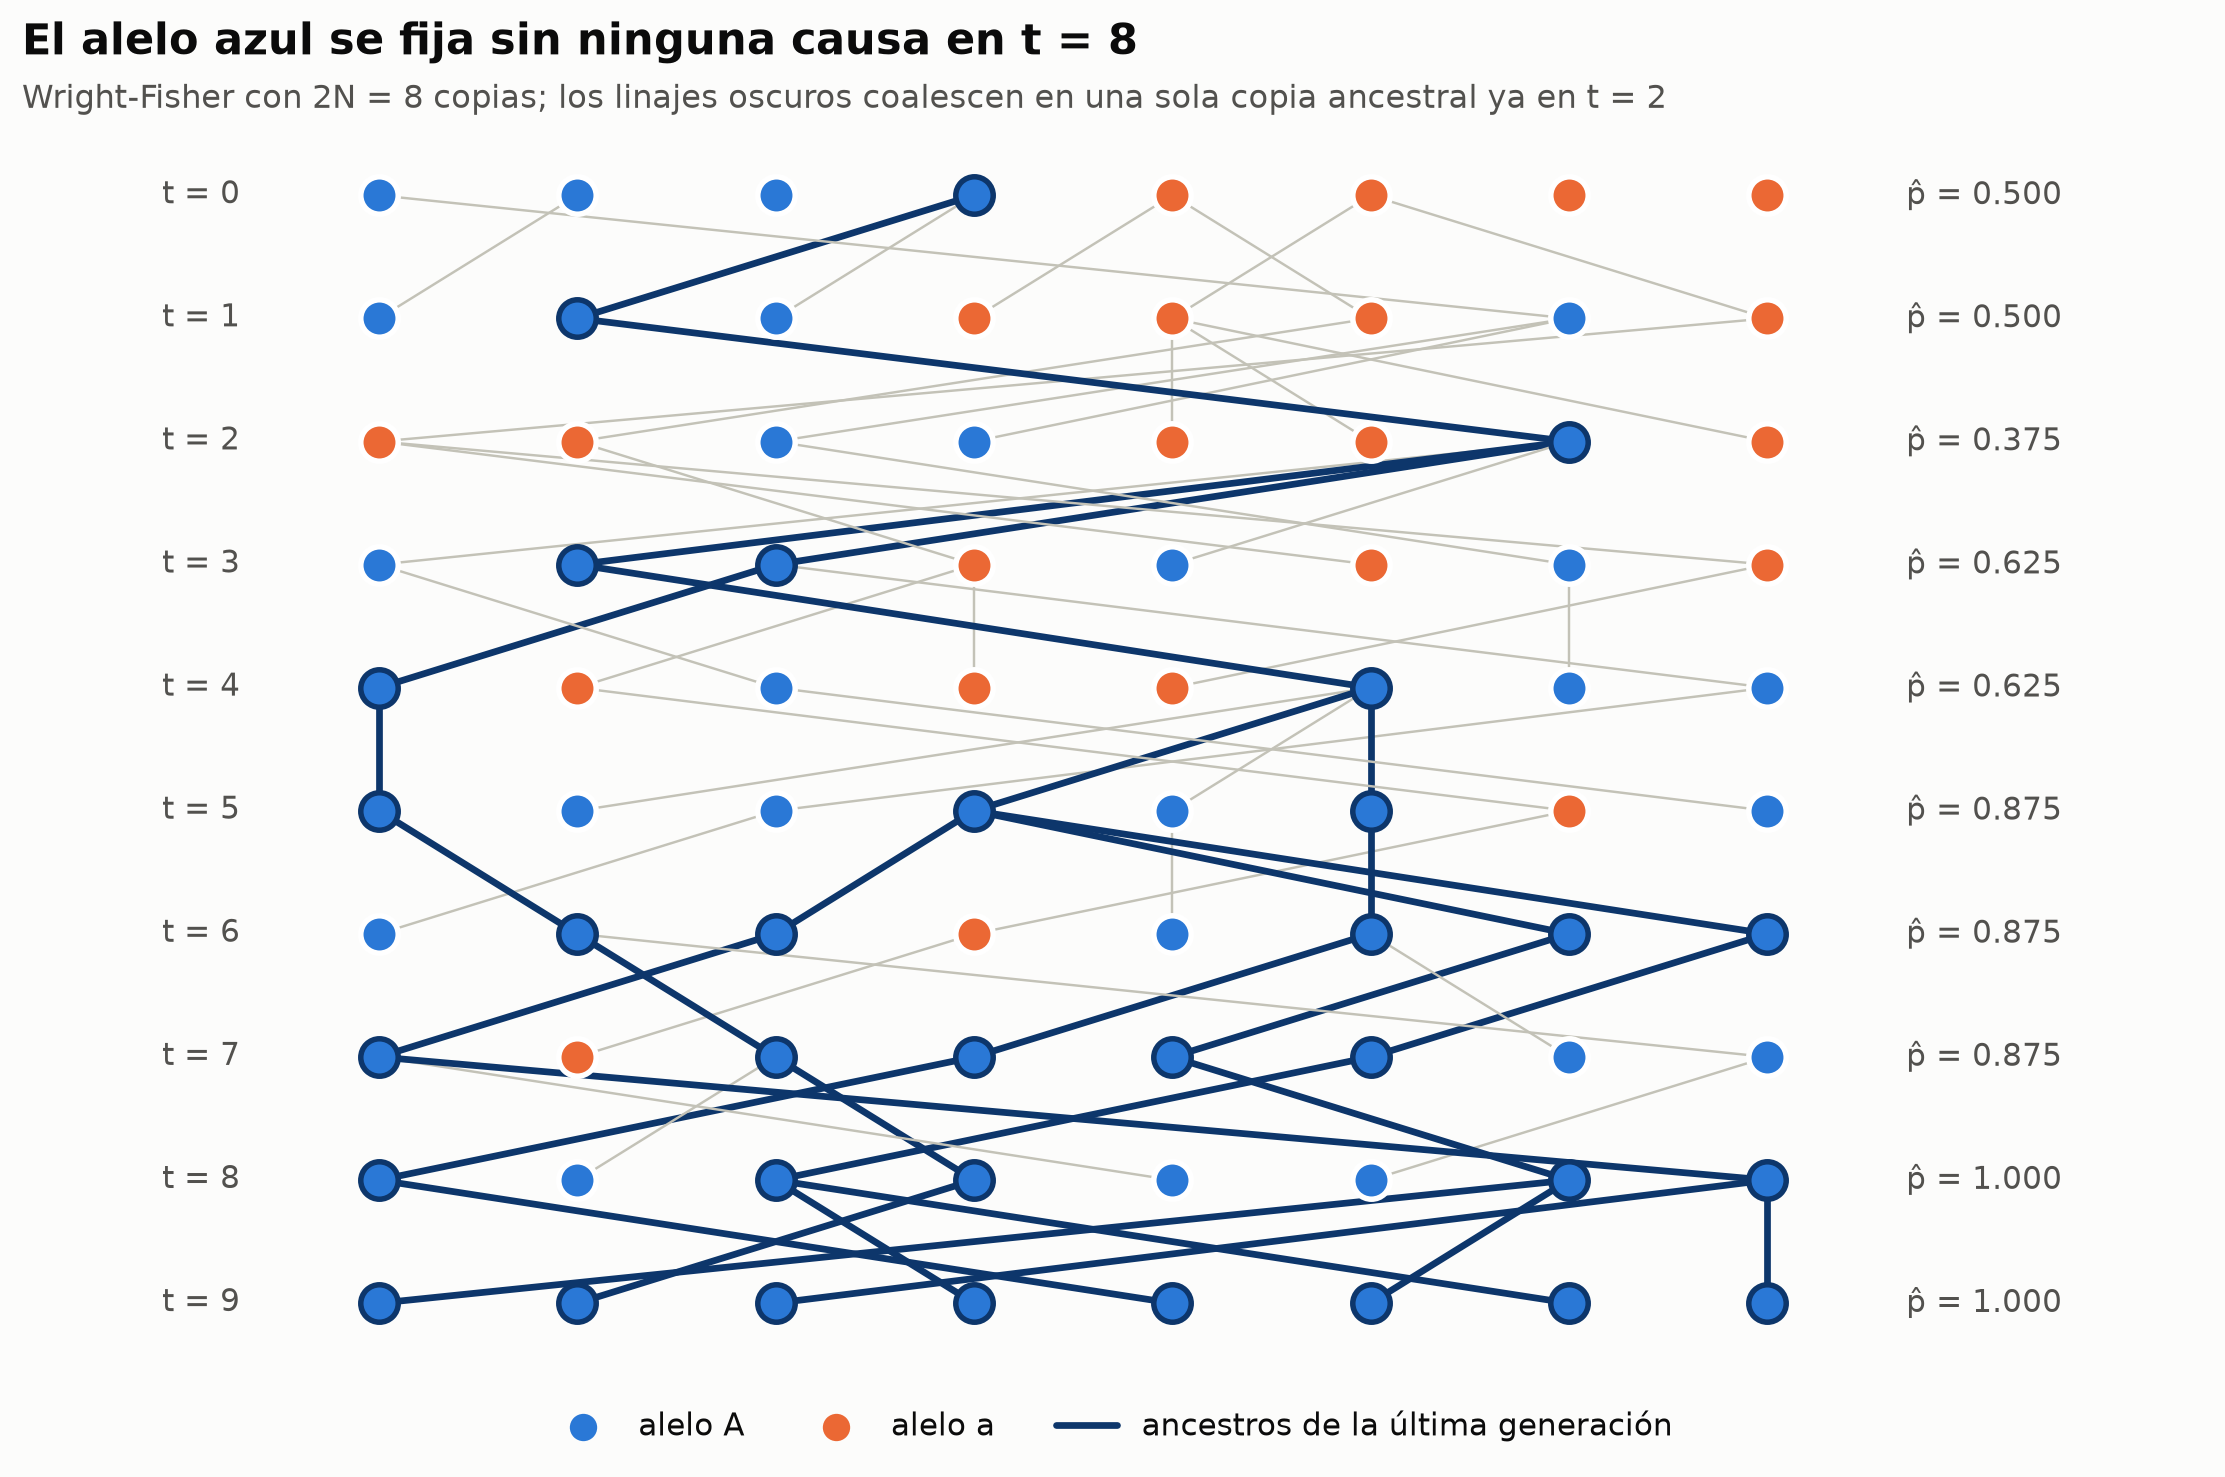

p̂_t: [0.5   0.5   0.375 0.625 0.625 0.875 0.875 0.875 1.    1.   ] 
linajes ancestrales por generación: [1, 1, 1, 2, 2, 3, 5, 5, 5, 8]
libro: p_t = 0.500,0.500,0.375,0.625,0.625,0.875,0.875,0.875,1.000,1.000 · linajes = 1,1,1,2,2,3,5,5,5,8


In [11]:
def genealogy(seed, G=10, K=8):
    """Genealogía de Wright-Fisher de la figura 10.2 del libro: K copias por generación, G generaciones."""
    r = np.random.default_rng(seed)
    parents = r.integers(0, K, size=(G - 1, K))       # parents[g][i]: madre (en g) de la copia i de g+1
    allele = np.zeros((G, K), int); allele[0, :4] = 1  # 4 copias azules (A) y 4 naranjas (a)
    for g in range(1, G):
        allele[g] = allele[g - 1][parents[g - 1]]
    anc = [set() for _ in range(G)]; anc[G - 1] = set(range(K))
    for g in range(G - 1, 0, -1):                     # linajes de la última generación, hacia atrás
        anc[g - 1] = {parents[g - 1][i] for i in anc[g]}
    return parents, allele, anc

parents, allele, anc = genealogy(48)
G, K = allele.shape
fig, ax = plt.subplots(figsize=(10, 6.6))
for g in range(G - 1):
    for i in range(K):
        j = parents[g][i]; on = i in anc[g + 1]
        ax.plot([j, i], [-g, -(g + 1)], color="#0d366b" if on else ec.BASELINE, lw=2.2 if on else 0.8, zorder=1)
for g in range(G):
    for i in range(K):
        ax.scatter(i, -g, s=150, color=ec.BLUE if allele[g, i] else ec.ORANGE, zorder=3,
                   edgecolor="#0d366b" if i in anc[g] else "white", lw=1.8)
    ax.text(-0.7, -g, f"t = {g}", ha="right", va="center", fontsize=10, color=ec.INK_2)
    ax.text(K - 0.3, -g, f"p̂ = {allele[g].mean():.3f}", ha="left", va="center", fontsize=10, color=ec.INK_2)
ax.scatter([], [], s=80, color=ec.BLUE, label="alelo A"); ax.scatter([], [], s=80, color=ec.ORANGE, label="alelo a")
ax.plot([], [], color="#0d366b", lw=2.2, label="ancestros de la última generación")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False)
ax.set_xlim(-1.8, K + 1.2); ax.axis("off")
ec.title(ax, "El alelo azul se fija sin ninguna causa en t = 8",
         "Wright-Fisher con 2N = 8 copias; los linajes oscuros coalescen en una sola copia ancestral ya en t = 2")
plt.show()
print("p̂_t:", allele.mean(1).round(3), "\nlinajes ancestrales por generación:", [len(a) for a in anc])
print("libro: p_t = 0.500,0.500,0.375,0.625,0.625,0.875,0.875,0.875,1.000,1.000 · linajes = 1,1,1,2,2,3,5,5,5,8")

> 🔎 **Qué observamos.** La frecuencia del alelo azul sube y baja (0,500 → 0,375 → 0,625 → 0,875) hasta fijarse, sin
> que ningún alelo sea «mejor». Siguiendo hacia atrás los linajes de las ocho copias finales, se fusionan
> (**coalescen**) rápidamente: en $t=2$ todas descienden de **una** copia. La fijación hacia adelante y la coalescencia
> hacia atrás son el mismo fenómeno mirado en las dos direcciones del tiempo (lo retomamos en la sección 7).

### Las simulaciones del libro, con la misma semilla

El libro generó todas sus figuras de deriva con **un solo** generador, `np.random.default_rng(1908)`, consumido en un
orden fijo: primero los puntos del triángulo de De Finetti, luego Wright-Fisher para $N=10$, 50 y 250 (12 réplicas
para dibujar y 5 000 para contar), la heterocigosidad, los tiempos de fijación, la difusión y la selección. Para
obtener **exactamente** sus números hay que repetir todos los sorteos en el mismo orden, así que los hacemos en una
sola celda (≈ 5 s) y guardamos los resultados para las secciones 4 a 7. Esta es la función del listado
`wright_fisher.py` del libro:

In [12]:
def wright_fisher(N, p0, T, reps, s=0.0, rng=None):
    """Frecuencias alélicas (T+1 x reps) bajo Wright-Fisher, con selección genética opcional s."""
    rng = np.random.default_rng(1) if rng is None else rng
    X = np.empty((T + 1, reps)); X[0] = p0
    for t in range(T):
        p = X[t] * (1 + s) / (1 + s * X[t])           # selección: cambia la probabilidad de muestreo
        X[t + 1] = rng.binomial(2 * N, p) / (2 * N)   # deriva: muestreo binomial de 2N copias
    return X

rng = np.random.default_rng(1908)
definetti_samples(rng)                                 # 1) los sorteos del triángulo de De Finetti
BOOK = {"traj": {}, "absorbed": {}}
for N in (10, 50, 250):                                # 2) trayectorias de la figura 10.3
    BOOK["traj"][N] = wright_fisher(N, 0.5, 200, 12, rng=rng)
    Xb = wright_fisher(N, 0.5, 200, 5000, rng=rng)
    BOOK["absorbed"][N] = ((Xb[-1] == 0) | (Xb[-1] == 1)).mean()
BOOK["H"] = {}
for N in (10, 25, 100):                                # 3) heterocigosidad (figura 10.4)
    X = wright_fisher(N, 0.5, 100, 4000, rng=rng)
    BOOK["H"][N] = (2 * X * (1 - X)).mean(1)
Xb = wright_fisher(50, 0.5, 3000, 4000, rng=rng)      # 4) tiempo hasta la absorción, N = 50
BOOK["t_abs"] = ((Xb == 0) | (Xb == 1)).argmax(0)
BOOK["diff"] = wright_fisher(50, 0.5, 100, 40000, rng=rng)   # 5) difusión (figura 10.5a)
BOOK["S4"] = np.array([-3, -2, -1, -0.5, 0, 0.5, 1, 2, 3, 4, 6, 8])
BOOK["u_sim"] = np.array([(wright_fisher(50, 0.1, 2500, 3000, s=S4 / 200, rng=rng)[-1] == 1).mean()
                          for S4 in BOOK["S4"]])       # 6) fijación con selección (figura 10.5b)
del Xb

book_abs = {10: 1.000, 50: 0.794, 250: 0.081}
for N in (10, 50, 250):
    print(f"N = {N:>3}: réplicas absorbidas en t = 200 → esta ejecución {BOOK['absorbed'][N]:.3f} · libro {book_abs[N]:.3f}")
print("Réplicas del libro que terminan en 1 (N = 10):", BOOK["traj"][10][-1].astype(int))

N =  10: réplicas absorbidas en t = 200 → esta ejecución 1.000 · libro 1.000
N =  50: réplicas absorbidas en t = 200 → esta ejecución 0.794 · libro 0.794
N = 250: réplicas absorbidas en t = 200 → esta ejecución 0.081 · libro 0.081
Réplicas del libro que terminan en 1 (N = 10): [1 0 1 1 0 1 0 0 1 0 0 0]


> 🧪 **Reproducibilidad, en serio.** Esta lección se ejecutó con NumPy 2.0.2 (la versión de Colab) y la semilla 1908,
> y reproduce las cifras del libro. Con otra versión de NumPy, los resúmenes de miles de réplicas pueden diferir en la
> tercera cifra, dentro del error de Monte Carlo. Por eso todo artículo computacional serio publica, además de la
> semilla, **la versión de cada biblioteca** (la primera celda imprimió la suya).

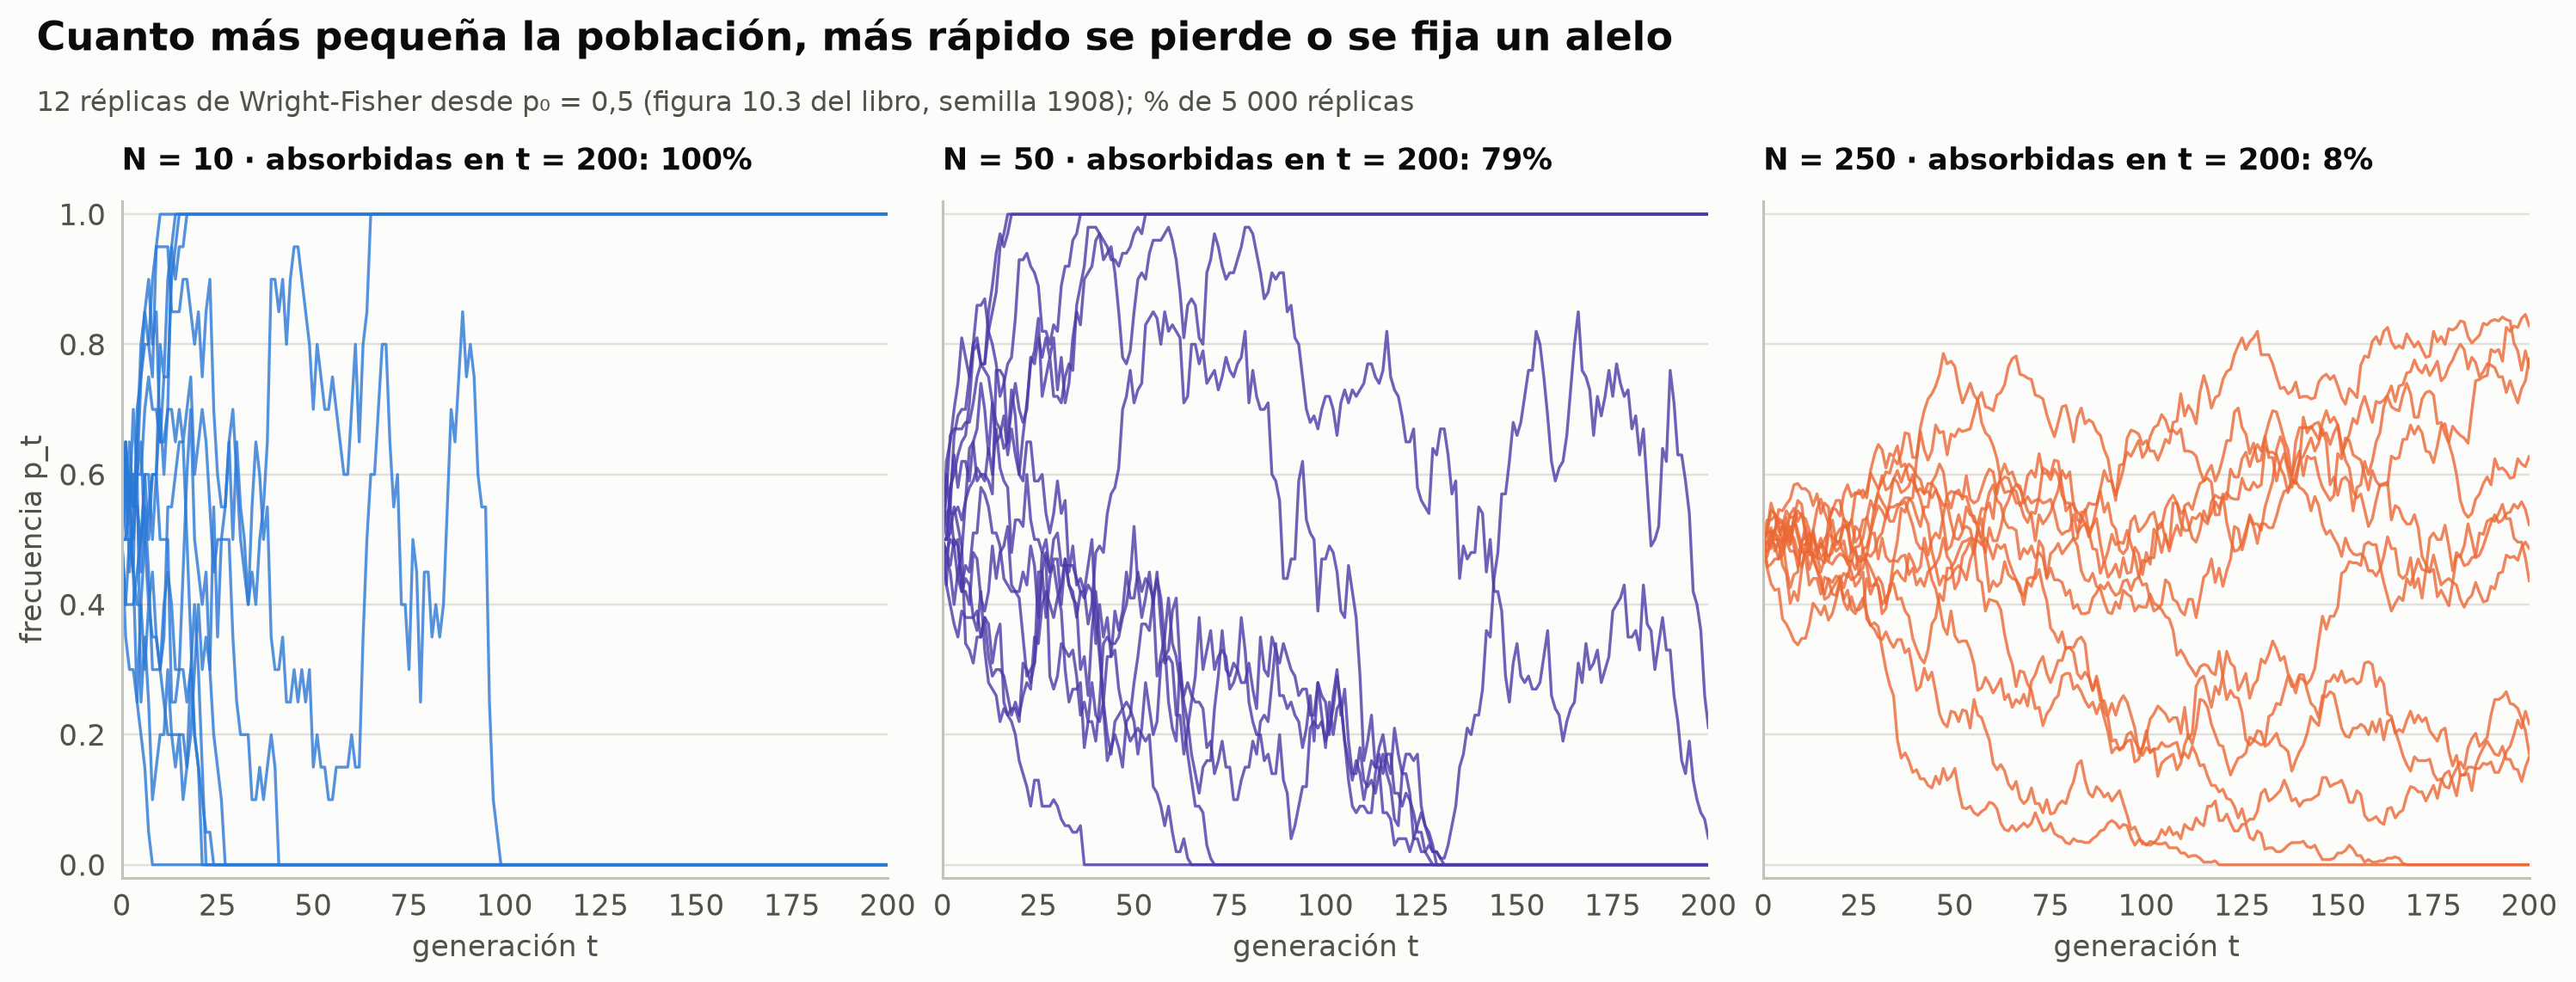

N = 10: 12 réplicas en t = 200 → fijadas 5, perdidas 7, aún polimórficas 0
N = 50: 12 réplicas en t = 200 → fijadas 4, perdidas 6, aún polimórficas 2
N = 250: 12 réplicas en t = 200 → fijadas 0, perdidas 2, aún polimórficas 10


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), sharey=True)
cols = {10: ec.BLUE, 50: ec.VIOLET, 250: ec.ORANGE}
for ax, N in zip(axes, (10, 50, 250)):
    X = BOOK["traj"][N]
    ax.plot(np.arange(201), X, color=cols[N], lw=1.1, alpha=0.8)
    ax.set_title(f"N = {N} · absorbidas en t = 200: {BOOK['absorbed'][N]:.0%}", fontsize=11.5)
    ax.set_xlim(0, 200); ax.set_ylim(-0.02, 1.02); ax.set_xlabel("generación t")
axes[0].set_ylabel("frecuencia p_t")
ec.fig_title(fig, "Cuanto más pequeña la población, más rápido se pierde o se fija un alelo",
             "12 réplicas de Wright-Fisher desde p₀ = 0,5 (figura 10.3 del libro, semilla 1908); % de 5 000 réplicas")
plt.show()
for N in (10, 50, 250):
    end = BOOK["traj"][N][-1]
    print(f"N = {N}: 12 réplicas en t = 200 → fijadas {int((end == 1).sum())}, perdidas {int((end == 0).sum())}, "
          f"aún polimórficas {int(((end > 0) & (end < 1)).sum())}")

> 🔎 **Qué observamos.** Con $N=10$ todas las trayectorias se absorben en pocas decenas de generaciones; con $N=50$
> lo hizo casi el 80 %; con $N=250$ apenas el 8 %, y las trayectorias se abren como un abanico lento. Entre las
> absorbidas, aproximadamente la mitad se fija en 1 y la otra mitad en 0, como predice $u(p_0)=p_0=0{,}5$.

### 🎬 La deriva, generación a generación

Las mismas 36 trayectorias, dibujadas a medida que transcurre el tiempo. A la derecha de cada panel, la distribución
de las 12 frecuencias actuales.

![Doce réplicas de Wright-Fisher para N = 10, 50 y 250 desde p₀ = 0,5: las poblaciones pequeñas se absorben en 0 o en 1 en pocas decenas de generaciones; las grandes, apenas se abren en 200](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-10-poblaciones-gwas/10.1_wright_fisher.gif)

*Doce réplicas de Wright-Fisher para N = 10, 50 y 250 desde p₀ = 0,5: las poblaciones pequeñas se absorben en 0 o en 1 en pocas decenas de generaciones; las grandes, apenas se abren en 200*

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharey=True)
fig.get_layout_engine().set(rect=(0, 0, 1, 0.86))
lines, dots, texts = {}, {}, {}
for ax, N in zip(axes, (10, 50, 250)):
    lines[N] = [ax.plot([], [], color=cols[N], lw=1.1, alpha=0.85)[0] for _ in range(12)]
    dots[N] = ax.scatter(np.zeros(12), np.full(12, 0.5), s=22, color=cols[N], zorder=3)
    ax.set_xlim(0, 200); ax.set_ylim(-0.02, 1.02); ax.set_xlabel("generación t")
    texts[N] = ax.set_title(f"N = {N}", fontsize=11.5, loc="left")
axes[0].set_ylabel("frecuencia p_t")
fig.text(0.01, 0.99, "La deriva no tiene dirección, pero sí destino", fontsize=15, fontweight="bold", va="top")
fig.text(0.01, 0.935, "12 réplicas de Wright-Fisher por tamaño, desde p₀ = 0,5 (semilla del libro)", fontsize=10.5,
         color=ec.INK_2, va="top")
T_frames = np.linspace(0, 200, 51).astype(int)

def update(f):
    t = T_frames[f]
    for N in (10, 50, 250):
        X = BOOK["traj"][N]
        for r_, ln in enumerate(lines[N]):
            ln.set_data(np.arange(t + 1), X[:t + 1, r_])
        dots[N].set_offsets(np.column_stack([np.full(12, t), X[t]]))
        ab = int(((X[t] == 0) | (X[t] == 1)).sum())
        texts[N].set_text(f"N = {N} · t = {t} · absorbidas {ab}/12")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(T_frames), interval=180, name="10.1_wright_fisher")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### 🎛️ Un simulador de Wright-Fisher con un deslizador

Mueva el deslizador para cambiar $N$ (de 5 a 1 000 individuos). Cada panel muestra 20 réplicas independientes desde
$p_0=0{,}5$; al pasar el ratón por una trayectoria verá su frecuencia, la generación y, si ya se absorbió, cuándo y
en qué extremo. Fíjese en cómo cambia la escala temporal: el tiempo de absorción crece **en proporción** a $N$.

> 🤔 **Antes de mover el deslizador, prediga.** Si $N$ se multiplica por 10, ¿cuántas veces más tardan en promedio
> las réplicas en absorberse?

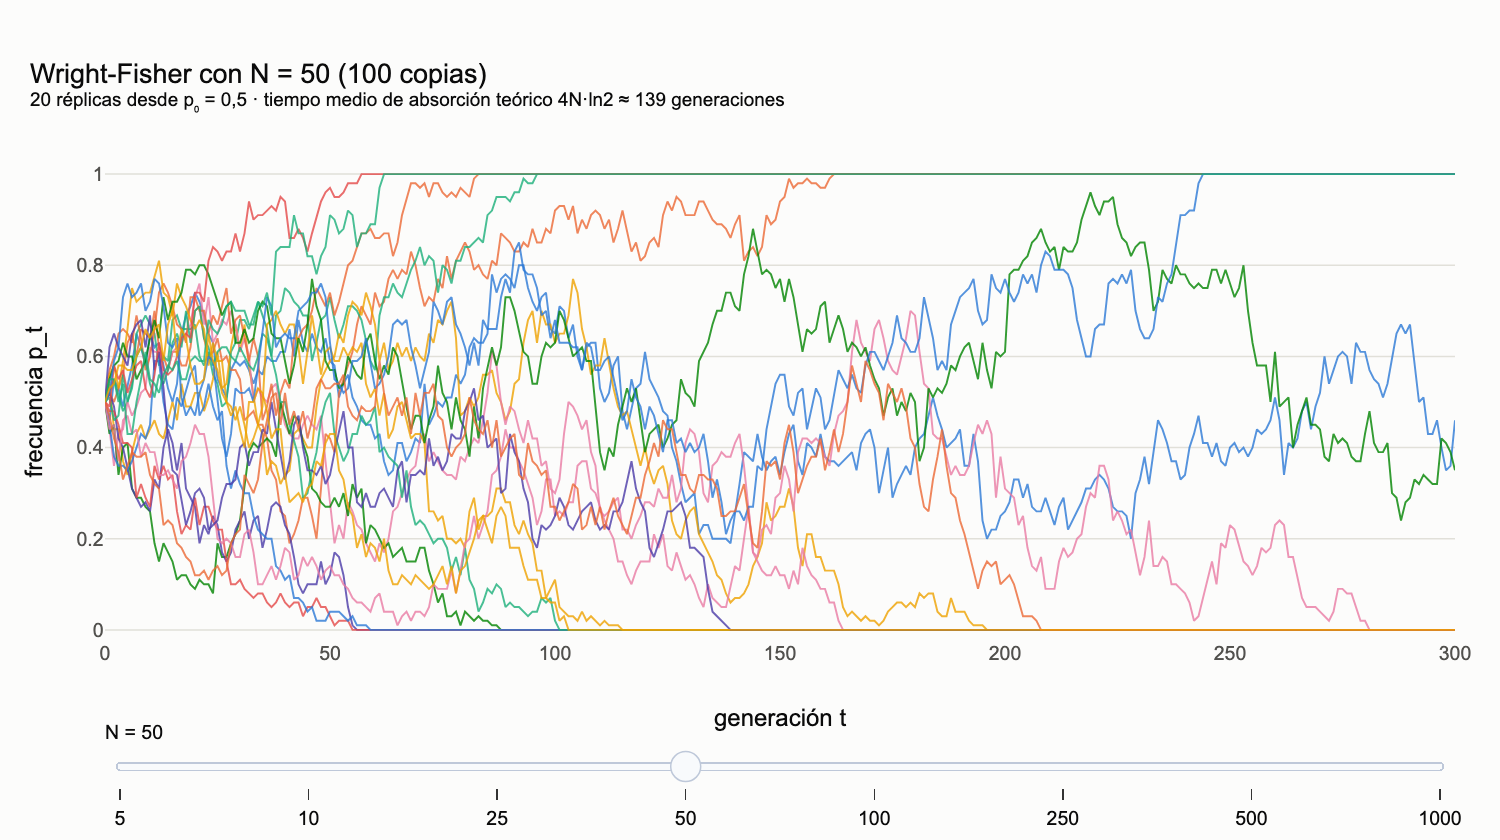

In [15]:
Ns_slider = [5, 10, 25, 50, 100, 250, 500, 1000]
T_sl, R_sl = 300, 20
rng_sl = np.random.default_rng(31)
fig = go.Figure()
for k, N in enumerate(Ns_slider):
    X = wright_fisher(N, 0.5, T_sl, R_sl, rng=rng_sl)
    absorbed = (X == 0) | (X == 1)
    for r_ in range(R_sl):
        t_abs = int(absorbed[:, r_].argmax()) if absorbed[:, r_].any() else None
        fate = ("fijada (p = 1)" if X[-1, r_] == 1 else "perdida (p = 0)") if t_abs is not None else "aún polimórfica"
        when = f"en t = {t_abs}" if t_abs is not None else f"en t = {T_sl}"
        fig.add_trace(go.Scatter(
            x=np.arange(T_sl + 1), y=X[:, r_], mode="lines", visible=(N == 50),
            line=dict(width=1.3, color=ec.CATEGORICAL[r_ % 8]), opacity=0.8, showlegend=False,
            hovertemplate=(f"<b>N = {N}</b> · réplica {r_ + 1}<br>generación %{{x}}: p = %{{y:.3f}}"
                           f"<br>destino: {fate} {when}<br>ruido por generación: DE ≈ √(p(1−p)/2N)"
                           f"<br>vida media de H: 2N·ln2 ≈ {2 * N * math.log(2):.0f} gen.<extra></extra>")))
steps = []
for k, N in enumerate(Ns_slider):
    vis = [False] * (len(Ns_slider) * R_sl); vis[k * R_sl:(k + 1) * R_sl] = [True] * R_sl
    steps.append(dict(method="update", label=str(N),
                      args=[{"visible": vis},
                            {"title.text": f"Wright-Fisher con N = {N} ({2 * N} copias)<br><sup>20 réplicas desde "
                                           f"p₀ = 0,5 · tiempo medio de absorción teórico 4N·ln2 ≈ "
                                           f"{4 * N * math.log(2):.0f} generaciones</sup>"}]))
fig.update_layout(
    sliders=[dict(active=Ns_slider.index(50), steps=steps, currentvalue=dict(prefix="N = "), pad=dict(t=50))],
    title=f"Wright-Fisher con N = 50 (100 copias)<br><sup>20 réplicas desde p₀ = 0,5 · tiempo medio de absorción "
          f"teórico 4N·ln2 ≈ {4 * 50 * math.log(2):.0f} generaciones</sup>",
    xaxis_title="generación t", yaxis_title="frecuencia p_t", yaxis_range=[-0.02, 1.02], height=560,
    margin=dict(t=110, l=70, r=30, b=40))
fig.show()

> 🔎 **Qué observamos.** Con $N=5$ todo termina en unas pocas generaciones; con $N=1\,000$ las 20 réplicas apenas se
> separan de 0,5 en 300 generaciones. Multiplicar $N$ por 10 multiplica por 10 la escala de tiempo: la deriva se
> mide en unidades de $2N$ generaciones.

> ✅ **Compruebe su comprensión.** Una mutación neutral nueva aparece en una población de 5 000 personas. ¿Con qué
> probabilidad se fijará? ¿Y si la población fuera de 50? *(1/10 000 y 1/100: en poblaciones pequeñas, la deriva
> puede fijar variantes nuevas con relativa facilidad, incluidas las ligeramente perjudiciales.)*

## 5. Pérdida de heterocigosidad y una población cautiva

Las trayectorias sugieren que la variabilidad se erosiona a un ritmo que depende de $N$. Podemos calcularlo
**exactamente** siguiendo una cantidad bien elegida: la probabilidad $F_t$ de que dos copias distintas tomadas al azar
en la generación $t$ sean **idénticas por descendencia** (copias de una misma copia ancestral).

**Derivación, paso a paso.** Tome dos copias distintas de la generación $t+1$:

* con probabilidad $1/2N$ eligieron **la misma** madre → son idénticas por descendencia;
* con probabilidad $1-1/2N$ eligieron madres distintas, que a su vez son idénticas con probabilidad $F_t$.

Por lo tanto (ecuación 10.11 del libro)

$$
F_{t+1}=\frac{1}{2N}+\left(1-\frac{1}{2N}\right)F_t\quad\Longrightarrow\quad 1-F_{t+1}=\left(1-\frac{1}{2N}\right)(1-F_t).
$$

Como la heterocigosidad es proporcional a la probabilidad de **no** ser idénticas, $H_t=H_0(1-F_t)$ con $F_0=0$, e
iterando (ecuación 10.10):

$$
H_t=H_0\left(1-\frac{1}{2N}\right)^{t}\;\approx\;H_0\,e^{-t/2N}.
$$

La aproximación usa $\ln(1-x)\approx-x$ para $x$ pequeño. La constante de tiempo es $2N$ generaciones: $H$ se reduce a
la mitad en $2N\ln2\approx1{,}39N$ generaciones.

| Símbolo | Significado |
|---|---|
| $H_t$ | heterocigosidad esperada (promedio sobre réplicas) en la generación $t$ |
| $F_t$ | probabilidad de identidad por descendencia; el mismo $F$ de la sección 3, ahora producido por la deriva |
| $1/2N$ | probabilidad de que dos copias compartan madre en una generación: la «tasa de coalescencia» |

Comparemos la fórmula con las 4 000 réplicas del libro:

N =  10: H_50 simulación = 0.0378 (libro 0.0378) · teoría = 0.0385
N =  25: H_50 simulación = 0.1818 (libro 0.1818) · teoría = 0.1821
N = 100: H_50 simulación = 0.3886 (libro 0.3886) · teoría = 0.3892


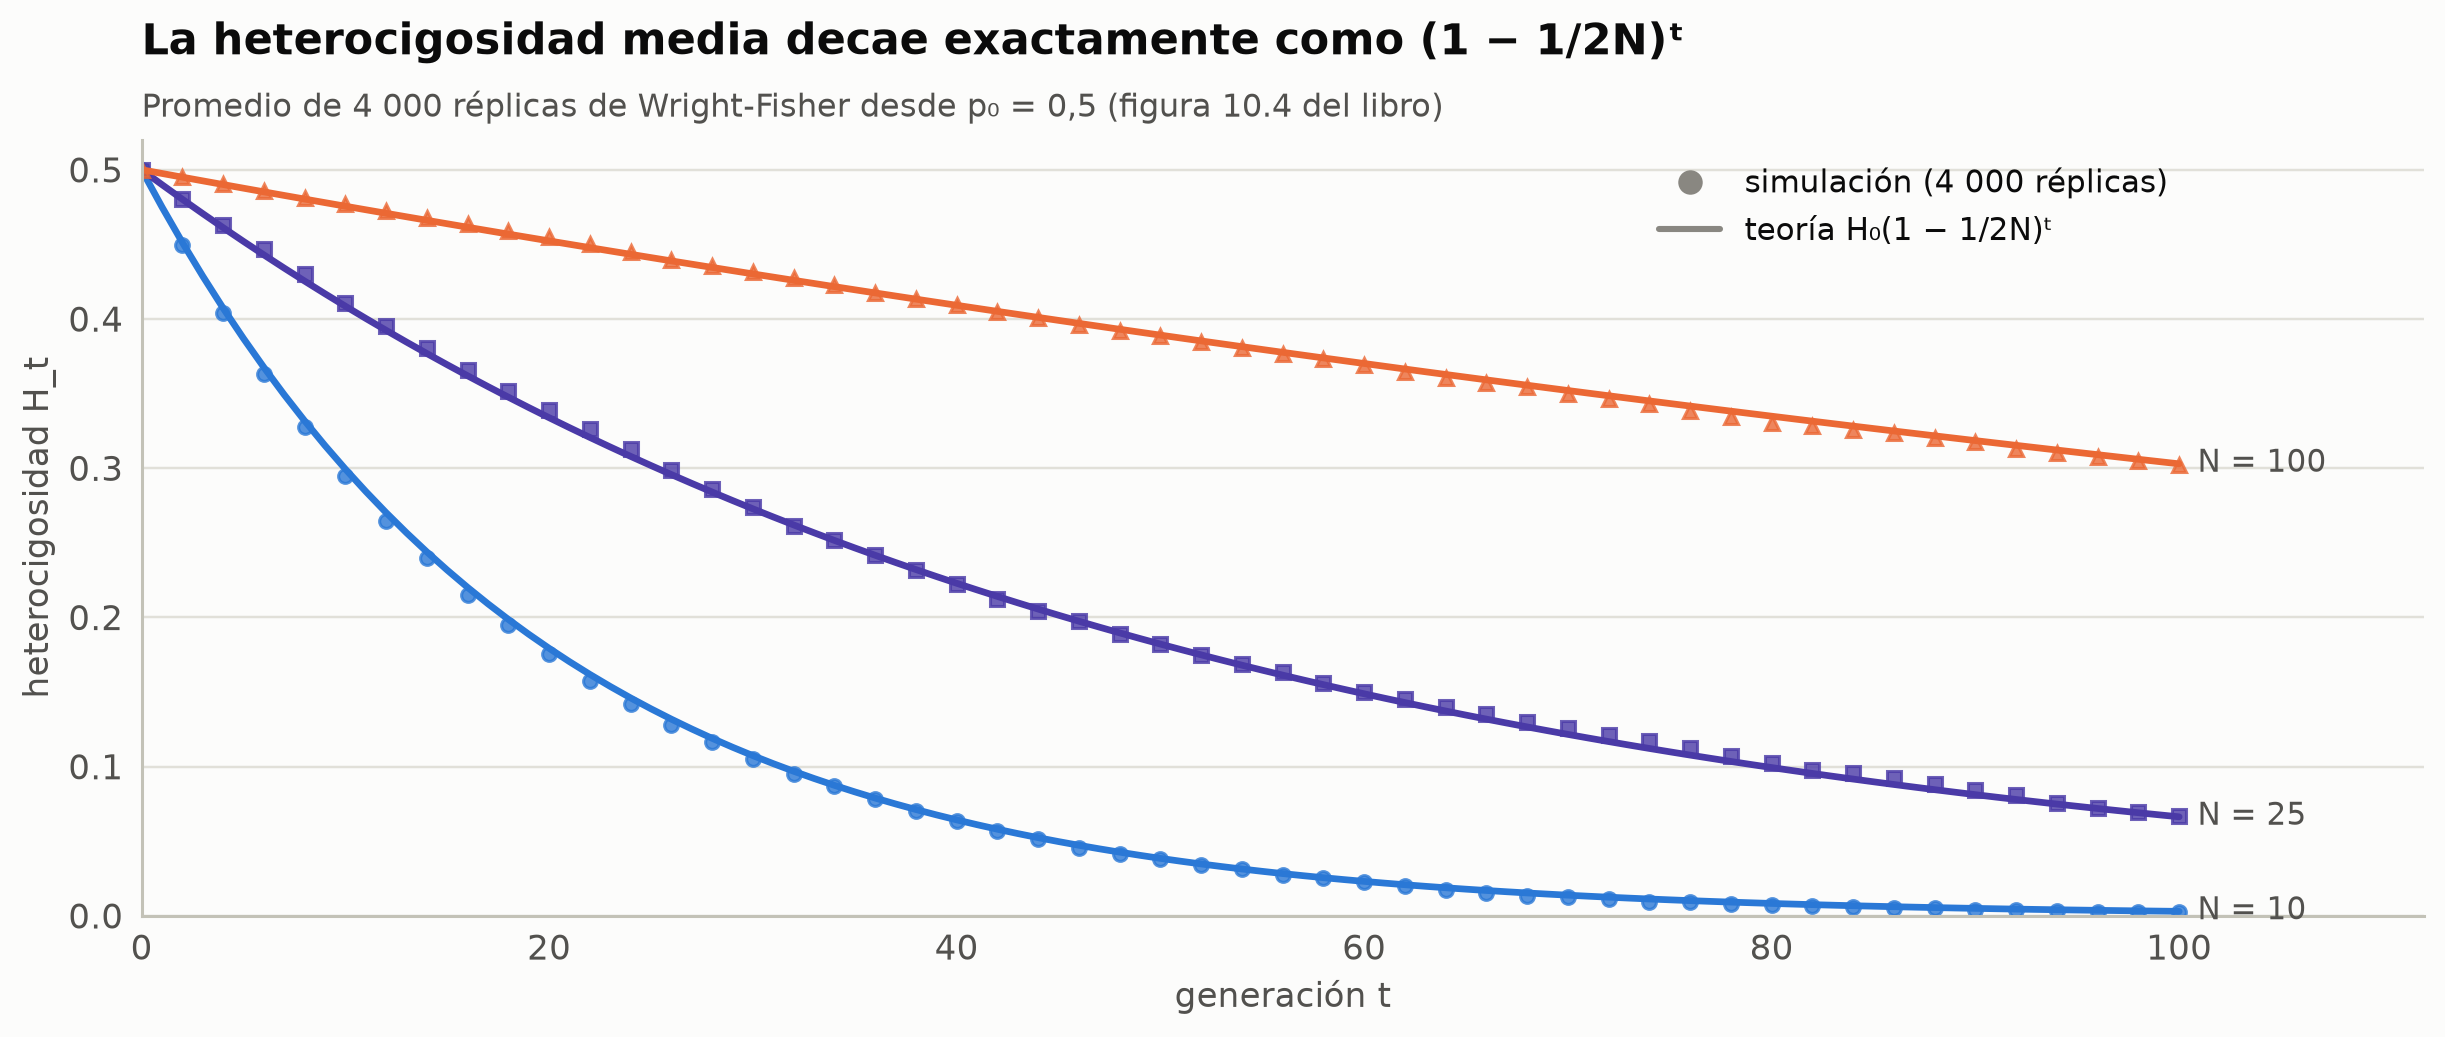

In [16]:
t = np.arange(101)
fig, ax = plt.subplots(figsize=(11, 4.6))
marks = {10: "o", 25: "s", 100: "^"}
colsH = {10: ec.BLUE, 25: ec.VIOLET, 100: ec.ORANGE}
book_H50 = {10: 0.0378, 25: 0.1818, 100: 0.3886}
for N in (10, 25, 100):
    theory = 0.5 * (1 - 1 / (2 * N)) ** t
    ax.plot(t, theory, color=colsH[N], lw=2.2)
    ax.plot(t[::2], BOOK["H"][N][::2], marks[N], ms=4.5, color=colsH[N], alpha=0.8)
    ec.label_end(ax, 100, theory[-1], f"N = {N}")
    print(f"N = {N:>3}: H_50 simulación = {BOOK['H'][N][50]:.4f} (libro {book_H50[N]:.4f}) · teoría = {theory[50]:.4f}")
ax.plot([], [], "o", color=ec.MUTED, label="simulación (4 000 réplicas)"); ax.plot([], [], color=ec.MUTED, label="teoría H₀(1 − 1/2N)ᵗ")
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(0.9, 1.0))
ax.set_xlim(0, 112); ax.set_ylim(0, 0.52); ax.set_xlabel("generación t"); ax.set_ylabel("heterocigosidad H_t")
ec.title(ax, "La heterocigosidad media decae exactamente como (1 − 1/2N)ᵗ",
         "Promedio de 4 000 réplicas de Wright-Fisher desde p₀ = 0,5 (figura 10.4 del libro)")
plt.show()

> 🔎 **Qué observamos.** Tras 50 generaciones, una población de 10 individuos conserva menos del 8 % de su diversidad
> inicial; una de 100, el 78 %. Pero la ecuación describe el **promedio**: cada réplica concreta (sección 4) es muy
> ruidosa. Esa distinción es crucial en conservación.

### Ejemplo del libro: «Una población cautiva»

Un zoológico y dos centros de cría mantienen un programa de reproducción en cautividad de una especie amenazada:
$N=50$ ejemplares reproductores. Un locus microsatélite tiene $H_0=0{,}5$. ¿Cuánta diversidad quedará en 100
generaciones?

$$
H_{100}=0{,}5\left(1-\tfrac{1}{100}\right)^{100}=0{,}5\times0{,}366=0{,}183 ,
$$

es decir, se pierde el **63 %**. La vida media exacta es $\ln0{,}5/\ln0{,}99=69{,}0$ generaciones, muy cerca de la
aproximación $2N\ln2=69{,}3$. Para una población humana ancestral con un tamaño efectivo del orden de $10^4$ serían
unas 14 000 generaciones (más de 300 000 años); para el programa de cría, apenas 69.

H_100 = 0.183 (pérdida 63%) · vida media exacta = 69.0 · aproximada 2N·ln2 = 69.3   (libro: 0,183; 63 %; 69,0; 69,3)
Para conservar el 90 % de H durante 100 generaciones hace falta N ≈ 475


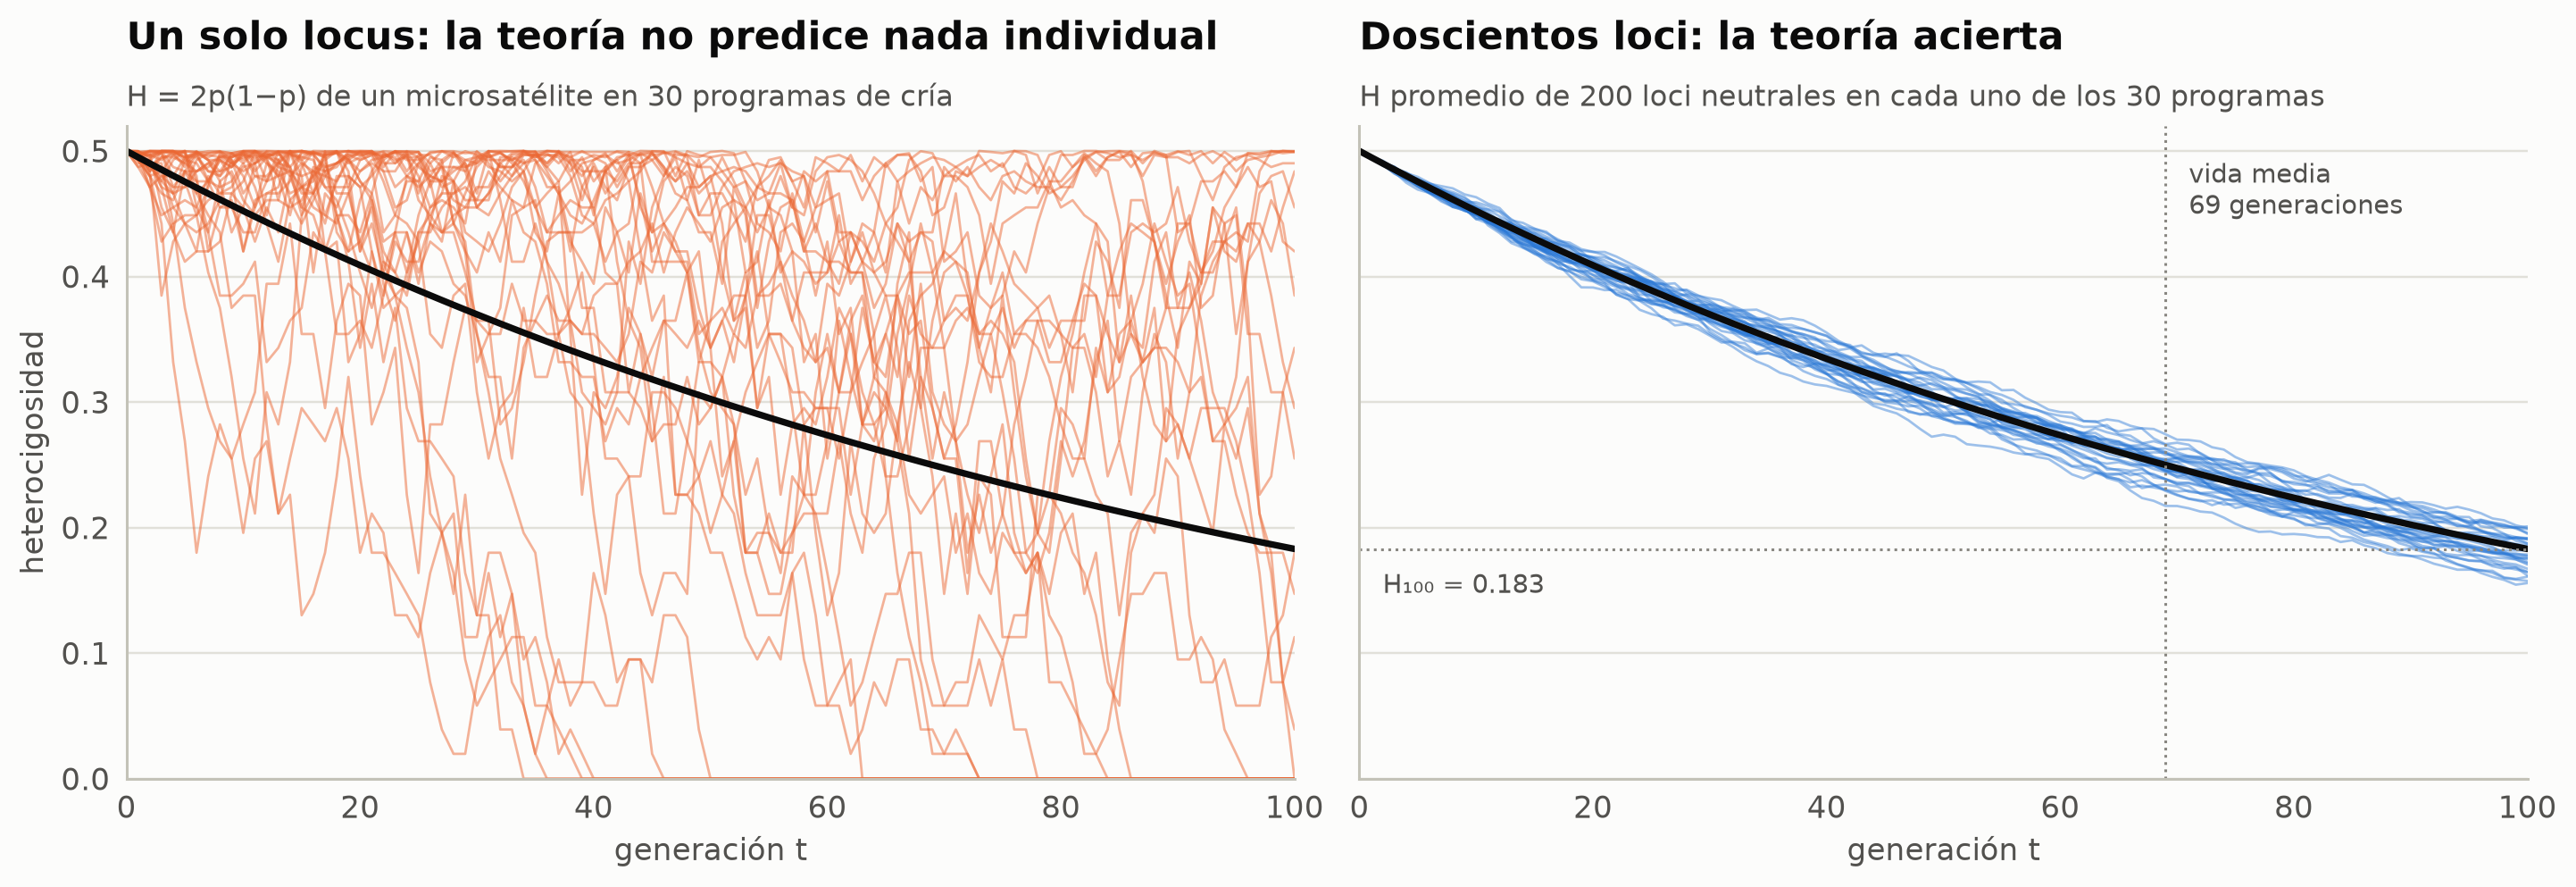

In [17]:
N_zoo, H0 = 50, 0.5
H100 = H0 * (1 - 1 / (2 * N_zoo)) ** 100
t_half_exact = math.log(0.5) / math.log(1 - 1 / (2 * N_zoo))
print(f"H_100 = {H100:.3f} (pérdida {1 - H100 / H0:.0%}) · vida media exacta = {t_half_exact:.1f} · "
      f"aproximada 2N·ln2 = {2 * N_zoo * math.log(2):.1f}   (libro: 0,183; 63 %; 69,0; 69,3)")
# ¿Cuántos reproductores harían falta para conservar el 90 % de H durante 100 generaciones?
N_needed = 1 / (2 * (1 - 0.9 ** (1 / 100)))
print(f"Para conservar el 90 % de H durante 100 generaciones hace falta N ≈ {N_needed:.0f}")

rng_zoo = np.random.default_rng(50)
# 30 programas de cría independientes; en cada uno, 200 loci neutrales desde p₀ = 0,5
Xz = wright_fisher(N_zoo, 0.5, 100, 30 * 200, rng=rng_zoo).reshape(101, 30, 200)
Hz = (2 * Xz * (1 - Xz)).mean(2)                         # H de cada programa (promedio de sus 200 loci)
Xs = wright_fisher(N_zoo, 0.5, 100, 30, rng=rng_zoo)    # un único locus por programa
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
tt = np.arange(101); theo = H0 * (1 - 1 / (2 * N_zoo)) ** tt
a1.plot(tt, 2 * Xs * (1 - Xs), color=ec.ORANGE, lw=0.9, alpha=0.5)
a1.plot(tt, theo, color=ec.INK, lw=2.4)
ec.title(a1, "Un solo locus: la teoría no predice nada individual", "H = 2p(1−p) de un microsatélite en 30 programas de cría")
a2.plot(tt, Hz, color=ec.BLUE, lw=0.9, alpha=0.45); a2.plot(tt, theo, color=ec.INK, lw=2.4)
a2.axhline(H100, xmin=0, xmax=1, color=ec.MUTED, ls=":", lw=1); a2.axvline(69, color=ec.MUTED, ls=":", lw=1)
a2.text(71, 0.45, "vida media\n69 generaciones", fontsize=9.5, color=ec.INK_2)
a2.text(2, H100 - 0.035, f"H₁₀₀ = {H100:.3f}", fontsize=9.5, color=ec.INK_2)
ec.title(a2, "Doscientos loci: la teoría acierta", "H promedio de 200 loci neutrales en cada uno de los 30 programas")
for a in (a1, a2):
    a.set_xlabel("generación t"); a.set_xlim(0, 100)
a1.set_ylabel("heterocigosidad"); a1.set_ylim(0, 0.52)
plt.show()

> 🔎 **Qué observamos.** Un único marcador es un pésimo termómetro: en unos programas se fija en 20 generaciones, en
> otros sigue polimórfico a las 100. Promediando 200 loci, todos los programas siguen la curva teórica. Por eso los
> genetistas de la conservación miden la diversidad con **muchos** marcadores (hoy, miles de SNP) y planifican con
> la curva media. Y la cuenta final es aleccionadora: para retener el 90 % de la heterocigosidad durante 100
> generaciones harían falta unos **475** reproductores **efectivos**, no 50. La palabra «efectivos» es la clave de la
> sección siguiente.

## 6. El tamaño efectivo de la población

Las poblaciones reales no son de Wright-Fisher: su tamaño fluctúa, los sexos no están equilibrados y unos
individuos tienen muchos más hijos que otros. Wright (1931) propuso una solución elegante: el **tamaño efectivo**
$N_e$ es el tamaño de la población de Wright-Fisher ideal que perdería heterocigosidad al mismo ritmo que la
población real. Todas las fórmulas anteriores siguen valiendo al cambiar $N$ por $N_e$.

Dos casos clásicos salen del mismo razonamiento de la ecuación 10.11. Si el tamaño cambia entre generaciones, las
probabilidades de coalescencia $1/2N_t$ se acumulan y el tamaño efectivo es la **media armónica**; con $N_m$ machos y
$N_f$ hembras reproductores, cada hijo tiene un padre y una madre, y los machos escasos se vuelven un cuello de
botella (ecuación 10.12):

$$
\frac{1}{N_e}=\frac1T\sum_{t=1}^{T}\frac{1}{N_t},\qquad\qquad N_e=\frac{4N_mN_f}{N_m+N_f}.
$$

| Símbolo | Significado |
|---|---|
| $N_e$ | tamaño efectivo: el $N$ que hay que poner en las fórmulas de Wright-Fisher |
| $N_t$ | tamaño censal en la generación $t$; $T$, número de generaciones consideradas |
| $N_m,\ N_f$ | número de machos y hembras reproductores |

**A mano.** Una población que pasa por 1 000, 10 y 1 000 individuos: $N_e=3/(0{,}001+0{,}1+0{,}001)\approx29$, no la media
aritmética 670. Una granja con 10 sementales y 90 hembras: $N_e=4\cdot10\cdot90/100=36$, no 100. Un solo cuello de botella
deja una huella duradera, y por eso el tamaño efectivo de la humanidad (unos $10^4$) es órdenes de magnitud menor que
su tamaño censal.

> 🤔 **Antes de ejecutar, prediga.** Simulamos 30 generaciones de una población que repite el ciclo 1 000 → 10 →
> 1 000. ¿A cuál de las dos curvas teóricas ($N=670$ o $N=29$) se parecerá la heterocigosidad simulada?

media armónica de (1000, 10, 1000) = 29.4 · media aritmética = 670
10 machos y 90 hembras: N_e = 36   (libro: 29 y 36)


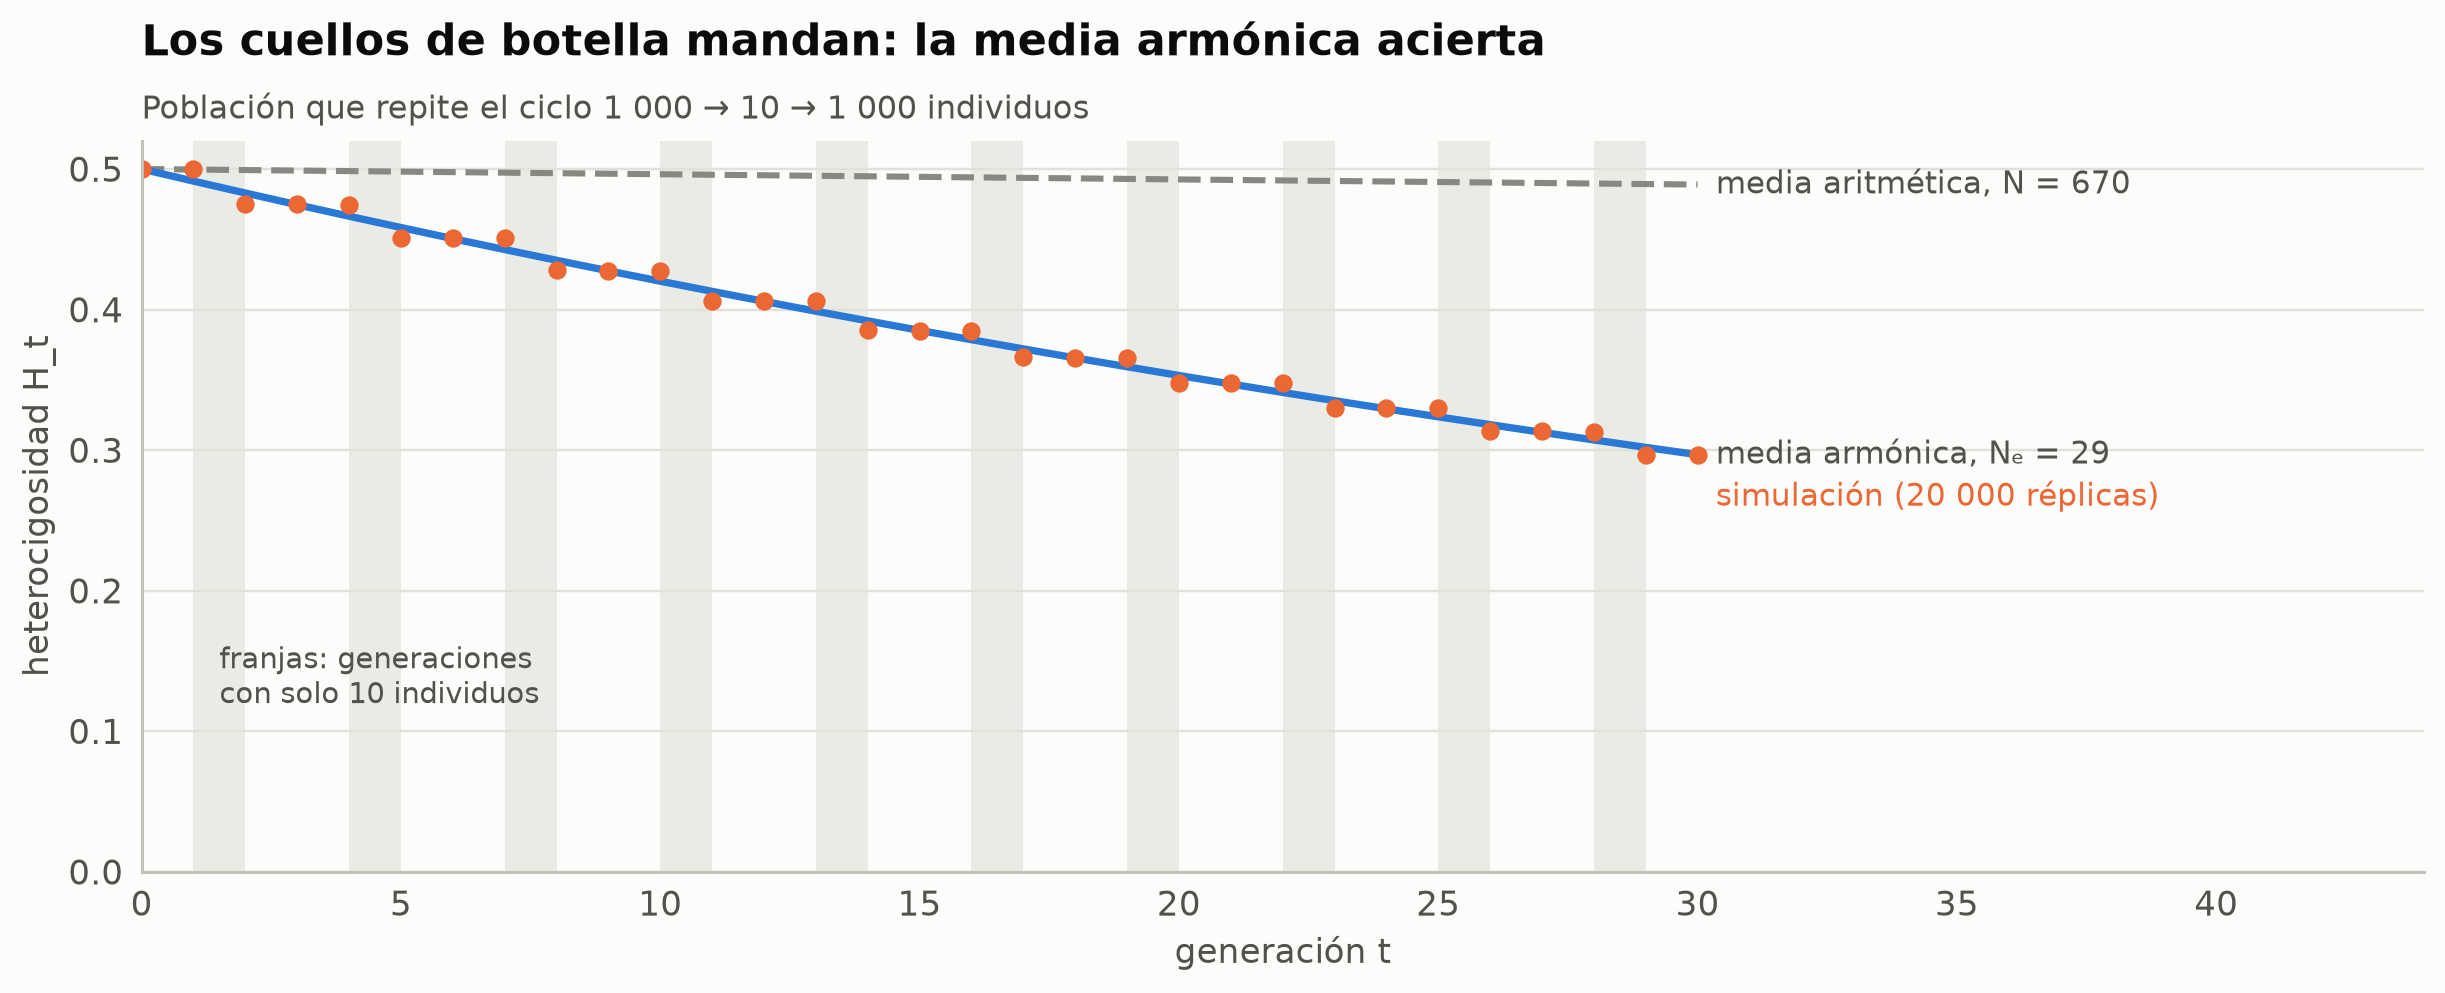

H_30: simulación 0.2967 · producto exacto de (1 − 1/2N_t) 0.2964 · Nₑ = 29: 0.2967 · N = 670: 0.4889


In [18]:
def harmonic_Ne(sizes):
    return len(sizes) / sum(1 / n for n in sizes)

print(f"media armónica de (1000, 10, 1000) = {harmonic_Ne([1000, 10, 1000]):.1f} · media aritmética = {np.mean([1000, 10, 1000]):.0f}")
print(f"10 machos y 90 hembras: N_e = {4 * 10 * 90 / (10 + 90):.0f}   (libro: 29 y 36)")

def wright_fisher_sizes(sizes, p0, reps, rng):
    """Wright-Fisher con un tamaño distinto en cada generación (sizes[t] = N de la generación t+1)."""
    X = np.empty((len(sizes) + 1, reps)); X[0] = p0
    for t, N in enumerate(sizes):
        X[t + 1] = rng.binomial(2 * N, X[t]) / (2 * N)
    return X

cycle = [1000, 10, 1000] * 10
Xc = wright_fisher_sizes(cycle, 0.5, 20000, np.random.default_rng(29))
Hc = (2 * Xc * (1 - Xc)).mean(1)
tc = np.arange(len(cycle) + 1)
H_exact = 0.5 * np.concatenate([[1], np.cumprod([1 - 1 / (2 * n) for n in cycle])])
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(tc, 0.5 * (1 - 1 / (2 * 670)) ** tc, color=ec.MUTED, lw=2, ls="--")
ax.plot(tc, 0.5 * (1 - 1 / (2 * 29)) ** tc, color=ec.BLUE, lw=2.4)
ax.plot(tc, Hc, "o", color=ec.ORANGE, ms=5)
ec.label_end(ax, 30, 0.5 * (1 - 1 / 1340) ** 30, "media aritmética, N = 670")
ec.label_end(ax, 30, 0.5 * (1 - 1 / 58) ** 30, "media armónica, Nₑ = 29")
ec.label_end(ax, 30, Hc[-1] - 0.03, "simulación (20 000 réplicas)", color=ec.ORANGE)
for k in range(1, 30, 3):
    ax.axvspan(k, k + 1, color=ec.GRID, alpha=0.6, lw=0)
ax.text(1.5, 0.12, "franjas: generaciones\ncon solo 10 individuos", fontsize=9.5, color=ec.INK_2)
ax.set_xlim(0, 44); ax.set_ylim(0, 0.52); ax.set_xlabel("generación t"); ax.set_ylabel("heterocigosidad H_t")
ec.title(ax, "Los cuellos de botella mandan: la media armónica acierta",
         "Población que repite el ciclo 1 000 → 10 → 1 000 individuos")
plt.show()
print(f"H_30: simulación {Hc[-1]:.4f} · producto exacto de (1 − 1/2N_t) {H_exact[-1]:.4f} · Nₑ = 29: "
      f"{0.5 * (1 - 1 / 58) ** 30:.4f} · N = 670: {0.5 * (1 - 1 / 1340) ** 30:.4f}")

> 🔎 **Qué observamos.** La heterocigosidad cae en **escalones**: casi nada en las generaciones de 1 000 individuos,
> un 5 % de golpe en cada generación de 10. En promedio sigue la curva de $N_e=29$, no la de 670. En conservación
> esta es la regla más importante: igualar el número de descendientes por progenitor, equilibrar sexos y, sobre
> todo, **evitar los cuellos de botella** vale más que aumentar el tamaño medio.

> ✅ **Compruebe su comprensión.** Un programa de cría tiene 50 animales, pero solo 5 machos se reproducen (con 45
> hembras). ¿Cuál es su $N_e$ y cuántas generaciones tarda en perder la mitad de su heterocigosidad? *($N_e=4\cdot5\cdot45/50=18$;
> $2N_e\ln2\approx25$ generaciones, frente a 69 si los sexos estuvieran equilibrados.)*

## 7. La aproximación por difusión de Kimura

La cadena de Wright-Fisher tiene $2N+1$ estados, y seguir distribuciones exactas durante muchas generaciones es
engorroso. Cuando $N$ es grande, los saltos de una generación son pequeños (del orden de $1/\sqrt{2N}$) y la
frecuencia se parece a una gota de tinta que se **difunde** en el intervalo $[0,1]$, con dos sumideros en los
bordes. Motoo Kimura explotó sistemáticamente esta idea. Si $\phi(p,t)$ es la densidad de la frecuencia en el tiempo
$t$, y $M(p)$ y $V(p)$ son la media y la varianza del cambio en una generación, $\phi$ obedece la ecuación de
Kolmogorov hacia adelante, o de Fokker-Planck (ecuación 10.13 del libro):

$$
\frac{\partial\phi}{\partial t}=\frac12\,\frac{\partial^2}{\partial p^2}\Big[V(p)\,\phi\Big]-\frac{\partial}{\partial p}\Big[M(p)\,\phi\Big],\qquad V(p)=\frac{p(1-p)}{2N}.
$$

| Símbolo | Significado |
|---|---|
| $\phi(p,t)$ | densidad de la frecuencia $p$ en el tiempo $t$ (entre las poblaciones aún no absorbidas) |
| $V(p)$ | varianza del cambio de frecuencia en una generación (ecuación 10.8) |
| $M(p)$ | cambio esperado por generación: $0$ si es neutral; $s\,p(1-p)$ con selección genética de intensidad $s$ |

Kimura (1955) resolvió el caso neutral ($M=0$) como una serie de polinomios de Gegenbauer. El término dominante decae
como $e^{-t/2N}$, la misma tasa de la pérdida de heterocigosidad, y la solución tiene **tres fases**: una campana
alrededor de $p_0$; una meseta casi uniforme; y un escurrimiento, a ritmo constante, hacia los bordes absorbentes.
La varianza entre réplicas crece como

$$
\operatorname{Var}(p_t)=p_0(1-p_0)\left[1-\left(1-\tfrac{1}{2N}\right)^t\right].
$$

Con $N=50$ la cadena solo tiene 101 estados, así que además de la simulación del libro (40 000 réplicas) podemos
calcular la distribución **exacta** multiplicando por la matriz de transición binomial: $\pi_{t+1}=\pi_t\,\mathbf P$.

In [19]:
N_d = 50
states = np.arange(2 * N_d + 1)
P_wf = stats.binom.pmf(states[None, :], 2 * N_d, states[:, None] / (2 * N_d))   # P[i, j] de la ecuación 10.7
pi = np.zeros(2 * N_d + 1); pi[N_d] = 1.0                                          # p₀ = 0,5 con certeza
exact = [pi]
for _ in range(150):
    pi = pi @ P_wf; exact.append(pi)
exact = np.array(exact)                                                            # exact[t, i] = P(X_t = i)

Xd = BOOK["diff"]
book_diff = {5: (0.000, 0.000, 0.0122), 20: (0.003, 0.003, 0.0455), 50: (0.072, 0.074, 0.0990), 100: (0.230, 0.232, 0.1581)}
rows = []
for tt_ in (5, 20, 50, 100):
    v = Xd[tt_]
    mean_exact = (exact[tt_] * states / (2 * N_d)).sum()
    var_exact = (exact[tt_] * (states / (2 * N_d)) ** 2).sum() - mean_exact ** 2
    rows.append({"t": tt_, "P(perdido) sim": np.mean(v == 0), "P(perdido) exacta": exact[tt_][0],
                 "P(fijado) sim": np.mean(v == 1), "Var sim": v.var(), "Var exacta": var_exact,
                 "Var fórmula": 0.25 * (1 - (1 - 1 / (2 * N_d)) ** tt_),
                 "libro (perd, fij, Var)": book_diff[tt_]})
pd.DataFrame(rows).round(4)

,t,P(perdido) sim,P(perdido) exacta,P(fijado) sim,Var sim,Var exacta,Var fórmula,"libro (perd, fij, Var)"
0,5,0.0000,0.0000,0.0000,0.0122,0.0123,0.0123,"(0.0, 0.0, 0.0122)"
1,20,0.0029,0.0027,0.0028,0.0455,0.0455,0.0455,"(0.003, 0.003, 0.0455)"
2,50,0.0720,0.0734,0.0740,0.0990,0.0987,0.0987,"(0.072, 0.074, 0.099)"
3,100,0.2304,0.2315,0.2316,0.1581,0.1585,0.1585,"(0.23, 0.232, 0.1581)"


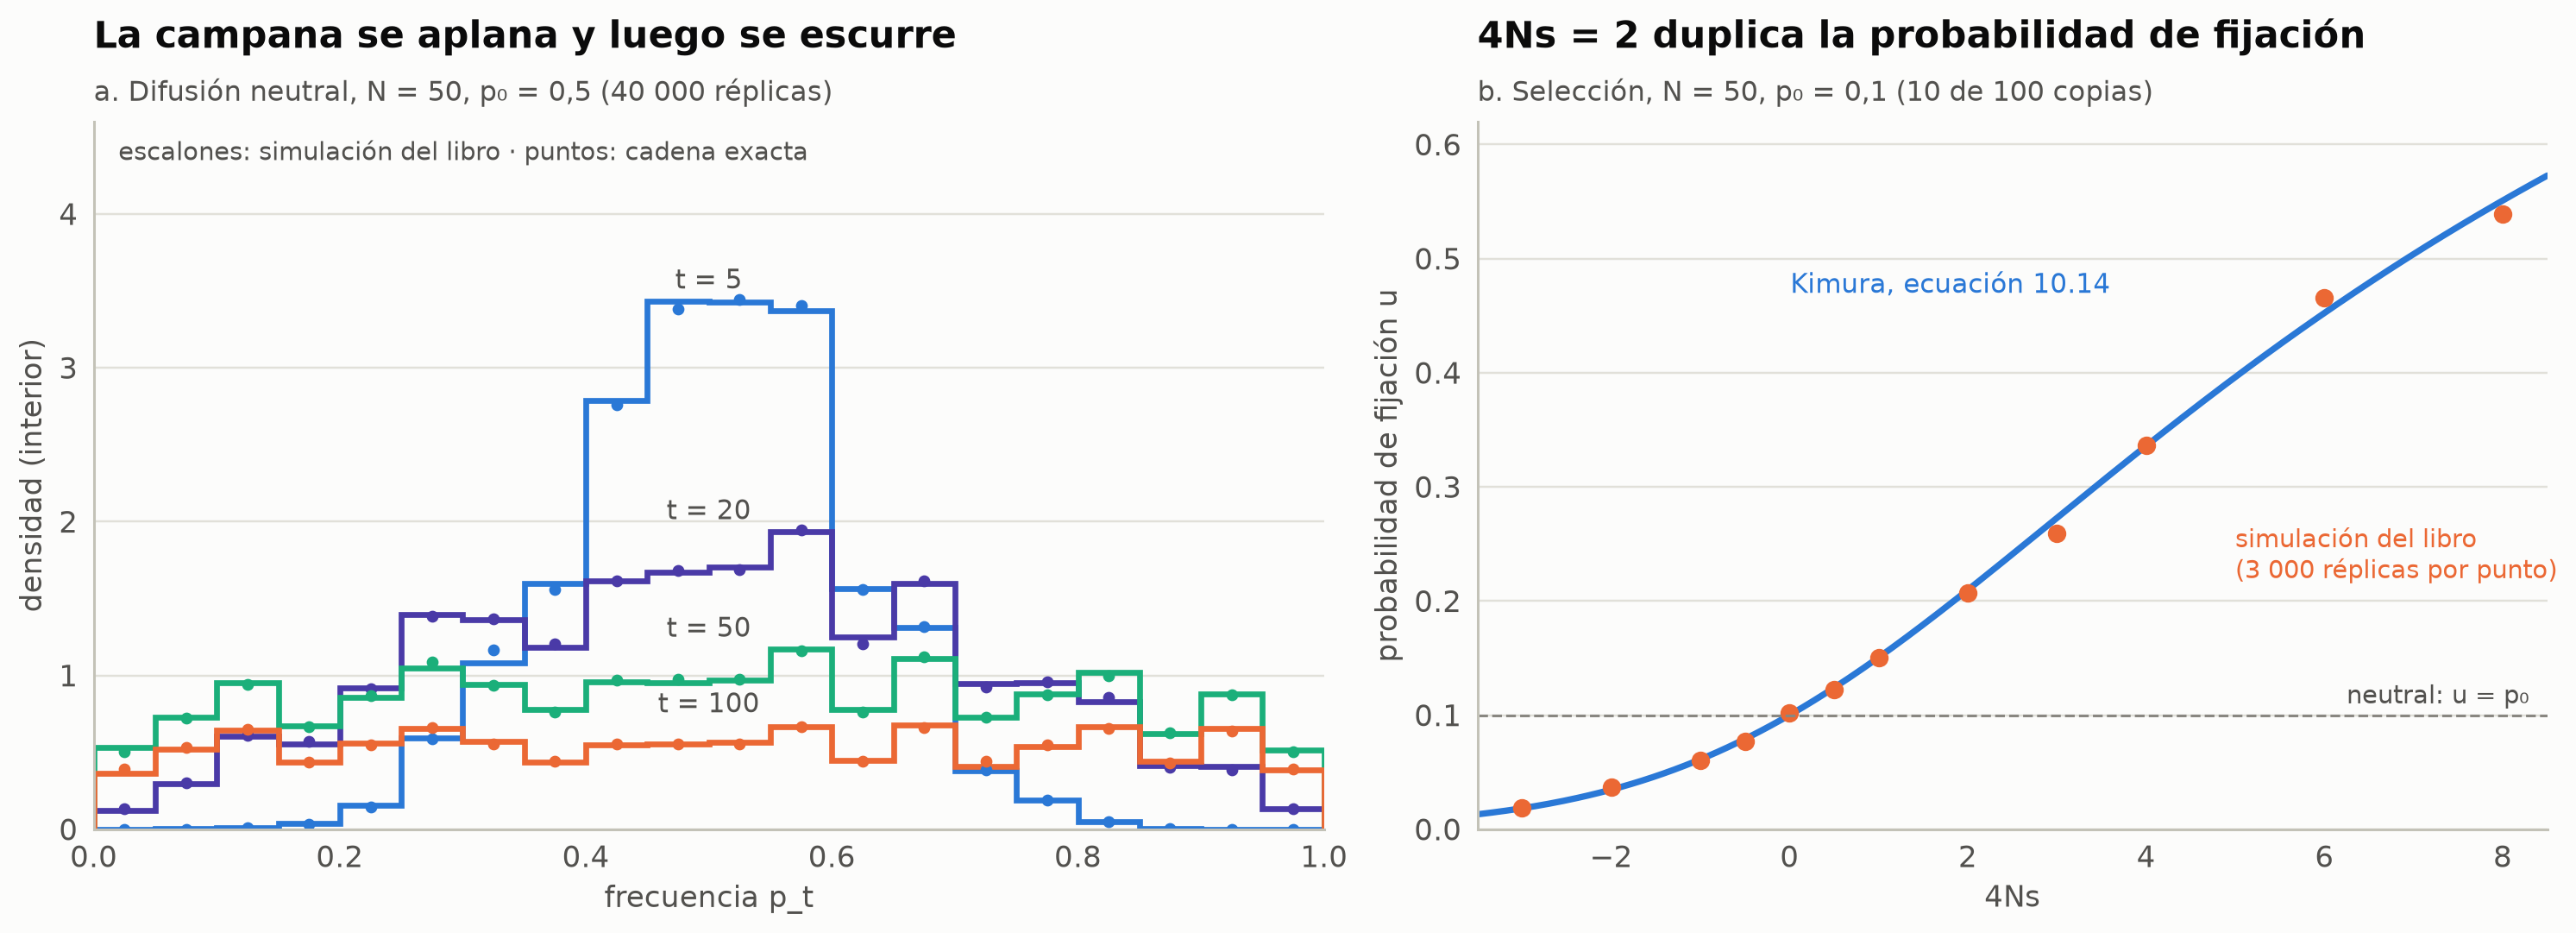

In [20]:
edges = np.linspace(0, 1, 21)
colsD = {5: ec.BLUE, 20: ec.VIOLET, 50: ec.AQUA, 100: ec.ORANGE}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.8), gridspec_kw=dict(width_ratios=[1.15, 1]))
for tt_ in (5, 20, 50, 100):
    v = Xd[tt_]; inner = v[(v > 0) & (v < 1)]
    h, _ = np.histogram(inner, bins=edges)
    dens = h / len(v) / 0.05                                  # misma normalización que el libro
    a1.stairs(dens, edges, color=colsD[tt_], lw=2.2)
    # cadena exacta: masa de los estados interiores de cada intervalo, dividida por su anchura
    fr = states[1:-1] / (2 * N_d); mass = exact[tt_][1:-1]
    idx = np.clip(np.digitize(fr, edges) - 1, 0, 19)
    ex_d = np.bincount(idx, weights=mass, minlength=20) / 0.05
    a1.plot((edges[:-1] + edges[1:]) / 2, ex_d, "o", ms=3.5, color=colsD[tt_])
    ymax = dens.max()
    a1.text(0.5, ymax + 0.08, f"t = {tt_}", ha="center", fontsize=10, color=ec.INK_2)
a1.set_xlim(0, 1); a1.set_ylim(0, 4.6); a1.set_xlabel("frecuencia p_t"); a1.set_ylabel("densidad (interior)")
a1.text(0.02, 4.35, "escalones: simulación del libro · puntos: cadena exacta", fontsize=9.5, color=ec.INK_2)
ec.title(a1, "La campana se aplana y luego se escurre", "a. Difusión neutral, N = 50, p₀ = 0,5 (40 000 réplicas)")

S4 = BOOK["S4"]; Sx = np.linspace(-3.5, 8.5, 300)
kim = np.where(np.abs(Sx) < 1e-9, 0.1, (1 - np.exp(-0.1 * Sx)) / (1 - np.exp(-Sx)))
a2.plot(Sx, kim, color=ec.BLUE, lw=2.4); a2.plot(S4, BOOK["u_sim"], "o", color=ec.ORANGE, ms=6)
a2.axhline(0.1, color=ec.MUTED, ls="--", lw=1); a2.text(8.3, 0.105, "neutral: u = p₀", ha="right", va="bottom", fontsize=9.5, color=ec.INK_2)
a2.text(3.6, 0.47, "Kimura, ecuación 10.14", ha="right", fontsize=10, color=ec.BLUE)
a2.text(5.0, 0.22, "simulación del libro\n(3 000 réplicas por punto)", fontsize=9.5, color=ec.ORANGE)
a2.set_xlim(-3.5, 8.5); a2.set_ylim(0, 0.62); a2.set_xlabel("4Ns"); a2.set_ylabel("probabilidad de fijación u")
ec.title(a2, "4Ns = 2 duplica la probabilidad de fijación", "b. Selección, N = 50, p₀ = 0,1 (10 de 100 copias)")
plt.show()

> 🔎 **Qué observamos.** (a) La campana inicial ($t=5$) se ensancha ($t=20$), se vuelve casi plana ($t=50$) y luego se
> hunde mientras la probabilidad escapa a los extremos: en $t=100$, alrededor del 23 % de las réplicas ha perdido el
> alelo y otro 23 % lo ha fijado. La cadena exacta (puntos) y la simulación coinciden, y la varianza sigue la fórmula
> (0,1585 frente a 0,158 simulado). (b) Esa es la otra mitad de la historia, que veremos a continuación.

### 🎬 La difusión de la distribución de frecuencias

Arriba del eje, la distribución de $p_t$ entre las 40 000 réplicas del libro (barras) y la cadena exacta (línea);
en los bordes, las barras rojas y verdes acumulan las réplicas perdidas y fijadas.

![La distribución de la frecuencia alélica en 40 000 poblaciones de Wright-Fisher (N = 50, p₀ = 0,5): una campana que se aplana, se vuelve uniforme y se escurre hacia los bordes, donde se acumulan pérdidas y fijaciones](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-10-poblaciones-gwas/10.1_difusion.gif)

*La distribución de la frecuencia alélica en 40 000 poblaciones de Wright-Fisher (N = 50, p₀ = 0,5): una campana que se aplana, se vuelve uniforme y se escurre hacia los bordes, donde se acumulan pérdidas y fijaciones*

In [21]:
fig, (ax, axb) = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw=dict(width_ratios=[3.2, 1]))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.86))
bins = np.linspace(0, 1, 26)
centers = (bins[:-1] + bins[1:]) / 2
bar_c = ax.bar(centers, np.zeros(25), width=0.036, color="#9ec5f4", edgecolor=ec.BLUE, lw=0.6)
line_ex, = ax.plot([], [], color=ec.INK, lw=2)
ax.set_xlim(0, 1); ax.set_ylim(0, 5.2); ax.set_xlabel("frecuencia p_t"); ax.set_ylabel("densidad (interior)")
bars_edge = axb.bar(["perdido\n(p = 0)", "fijado\n(p = 1)"], [0, 0], color=[ec.RED, ec.GREEN], width=0.55)
edge_txt = [axb.text(i, 0, "", ha="center", va="bottom", fontsize=10, color=ec.INK_2) for i in range(2)]
axb.set_ylim(0, 0.5); axb.set_ylabel("fracción de réplicas")
info = ax.text(0.02, 4.95, "", fontsize=11, color=ec.INK, va="top")
fig.text(0.01, 0.99, "La deriva difunde la frecuencia hasta los bordes absorbentes", fontsize=15, fontweight="bold", va="top")
fig.text(0.01, 0.935, "N = 50, p₀ = 0,5 · barras: 40 000 réplicas del libro · línea: cadena de Márkov exacta",
         fontsize=10.5, color=ec.INK_2, va="top")
T_d = list(range(0, 101, 2))
fr_int = states[1:-1] / (2 * N_d)
idx_int = np.clip(np.digitize(fr_int, bins) - 1, 0, 24)

def update(f):
    tt_ = T_d[f]; v = Xd[tt_]
    inner = v[(v > 0) & (v < 1)]
    h, _ = np.histogram(inner, bins=bins); dens = h / len(v) / 0.04
    for b, hv in zip(bar_c, dens):
        b.set_height(hv)
    ex_d = np.bincount(idx_int, weights=exact[tt_][1:-1], minlength=25) / 0.04
    line_ex.set_data(centers, ex_d)
    for i, val in enumerate((np.mean(v == 0), np.mean(v == 1))):
        bars_edge[i].set_height(val); edge_txt[i].set_position((i, val + 0.01)); edge_txt[i].set_text(f"{val:.1%}")
    info.set_text(f"t = {tt_:>3} · Var(p_t) = {v.var():.3f} (fórmula {0.25 * (1 - (1 - 1 / 100) ** tt_):.3f})")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(T_d), interval=160, name="10.1_difusion")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### Selección y probabilidad de fijación

La difusión permite incorporar la **selección** cambiando solo el término $M(p)$. Si el alelo $A$ confiere una
ventaja aditiva $s$ (cada copia multiplica la eficacia por $1+s$), Kimura (1962) obtuvo resolviendo la ecuación
**hacia atrás** (ecuación 10.14):

$$
u(p)=\frac{1-e^{-4Nsp}}{1-e^{-4Ns}} .
$$

Para una mutación nueva ($p=1/2N$) con $s$ pequeño y $4Ns\gg1$, $u\approx2s$.

| Símbolo | Significado |
|---|---|
| $u(p)$ | probabilidad de que el alelo termine fijado |
| $s$ | coeficiente de selección: ventaja relativa por copia ($s<0$ si es perjudicial) |
| $4Ns$ | intensidad de la selección relativa a la deriva: la única combinación de $N$ y $s$ que importa |

La lección es profunda: lo que decide el destino de un alelo no es $s$ sino $4Ns$. Si $|4Ns|\ll1$, $u\approx p$ y el
alelo se comporta como **neutral aunque no lo sea**; si $4Ns\gg1$, la selección domina. El panel (b) de la figura
anterior lo muestra: con $N=50$, una ventaja de solo $s=0{,}01$ ($4Ns=2$) duplica la probabilidad de fijación.

> 🤔 **Antes de ejecutar, prediga.** Una mutación **ventajosa** nueva, con $s=0{,}01$, aparece en una población de
> $N=10^4$. ¿Qué es más probable: que se fije o que se pierda?

In [22]:
def kimura_u(p, N, s):
    """Probabilidad de fijación de Kimura (1962), ecuación 10.14 del libro."""
    if abs(s) < 1e-12:
        return p
    return -math.expm1(-4 * N * s * p) / -math.expm1(-4 * N * s)

N_h, s_h = 10_000, 0.01
u_new = kimura_u(1 / (2 * N_h), N_h, s_h)
print(f"N = 10⁴, s = 0,01, p = 1/2N: u = {u_new:.5f} (≈ 2s = {2 * s_h}) · neutral 1/2N = {1 / (2 * N_h):.1e} · "
      f"razón = {u_new * 2 * N_h:.0f}×   (libro: 0,0198; 400×)")
print(f"→ el {1 - u_new:.0%} de estas mutaciones ventajosas desaparece por azar")
print("comprobación con la simulación del libro (N = 50, p₀ = 0,1):")
for S4_, us in zip(BOOK["S4"], BOOK["u_sim"]):
    print(f"   4Ns = {S4_:>5}: simulación {us:.4f} · Kimura {kimura_u(0.1, 50, S4_ / 200):.4f}")

N = 10⁴, s = 0,01, p = 1/2N: u = 0.01980 (≈ 2s = 0.02) · neutral 1/2N = 5.0e-05 · razón = 396×   (libro: 0,0198; 400×)
→ el 98% de estas mutaciones ventajosas desaparece por azar
comprobación con la simulación del libro (N = 50, p₀ = 0,1):
   4Ns =  -3.0: simulación 0.0190 · Kimura 0.0183
   4Ns =  -2.0: simulación 0.0367 · Kimura 0.0347
   4Ns =  -1.0: simulación 0.0603 · Kimura 0.0612
   4Ns =  -0.5: simulación 0.0770 · Kimura 0.0790
   4Ns =   0.0: simulación 0.1020 · Kimura 0.1000
   4Ns =   0.5: simulación 0.1227 · Kimura 0.1240
   4Ns =   1.0: simulación 0.1503 · Kimura 0.1505
   4Ns =   2.0: simulación 0.2070 · Kimura 0.2096
   4Ns =   3.0: simulación 0.2590 · Kimura 0.2728
   4Ns =   4.0: simulación 0.3363 · Kimura 0.3358
   4Ns =   6.0: simulación 0.4660 · Kimura 0.4523
   4Ns =   8.0: simulación 0.5393 · Kimura 0.5509


> 🔎 **Qué observamos.** Incluso una ventaja apreciable se pierde casi siempre por azar cuando el mutante es nuevo:
> el 98 % de estas mutaciones desaparece, aunque su probabilidad de fijarse sea 400 veces mayor que la de una
> neutral. Sobre esta observación construyó Kimura la **teoría neutral** de la evolución molecular.

### Tiempos de fijación

La misma maquinaria da el tiempo medio hasta la absorción (fijación **o** pérdida) de un alelo neutral con
frecuencia inicial $p$ (ecuación 10.15):

$$
\bar t(p)=-4N\big[p\ln p+(1-p)\ln(1-p)\big].
$$

Para $p=1/2$, $\bar t=4N\ln2\approx2{,}77N$: con $N=50$, 138,6 generaciones. La cadena exacta también lo da, sin
simular: si $\mathbf Q$ es la matriz de transición restringida a los estados interiores, los tiempos medios son
$(\mathbf I-\mathbf Q)^{-1}\mathbf 1$ (la «matriz fundamental» de una cadena absorbente).

N = 50, p = 1/2: difusión 138.6 · cadena exacta 136.6 · simulación del libro 135.9   (libro: 138,6 y 135,9)


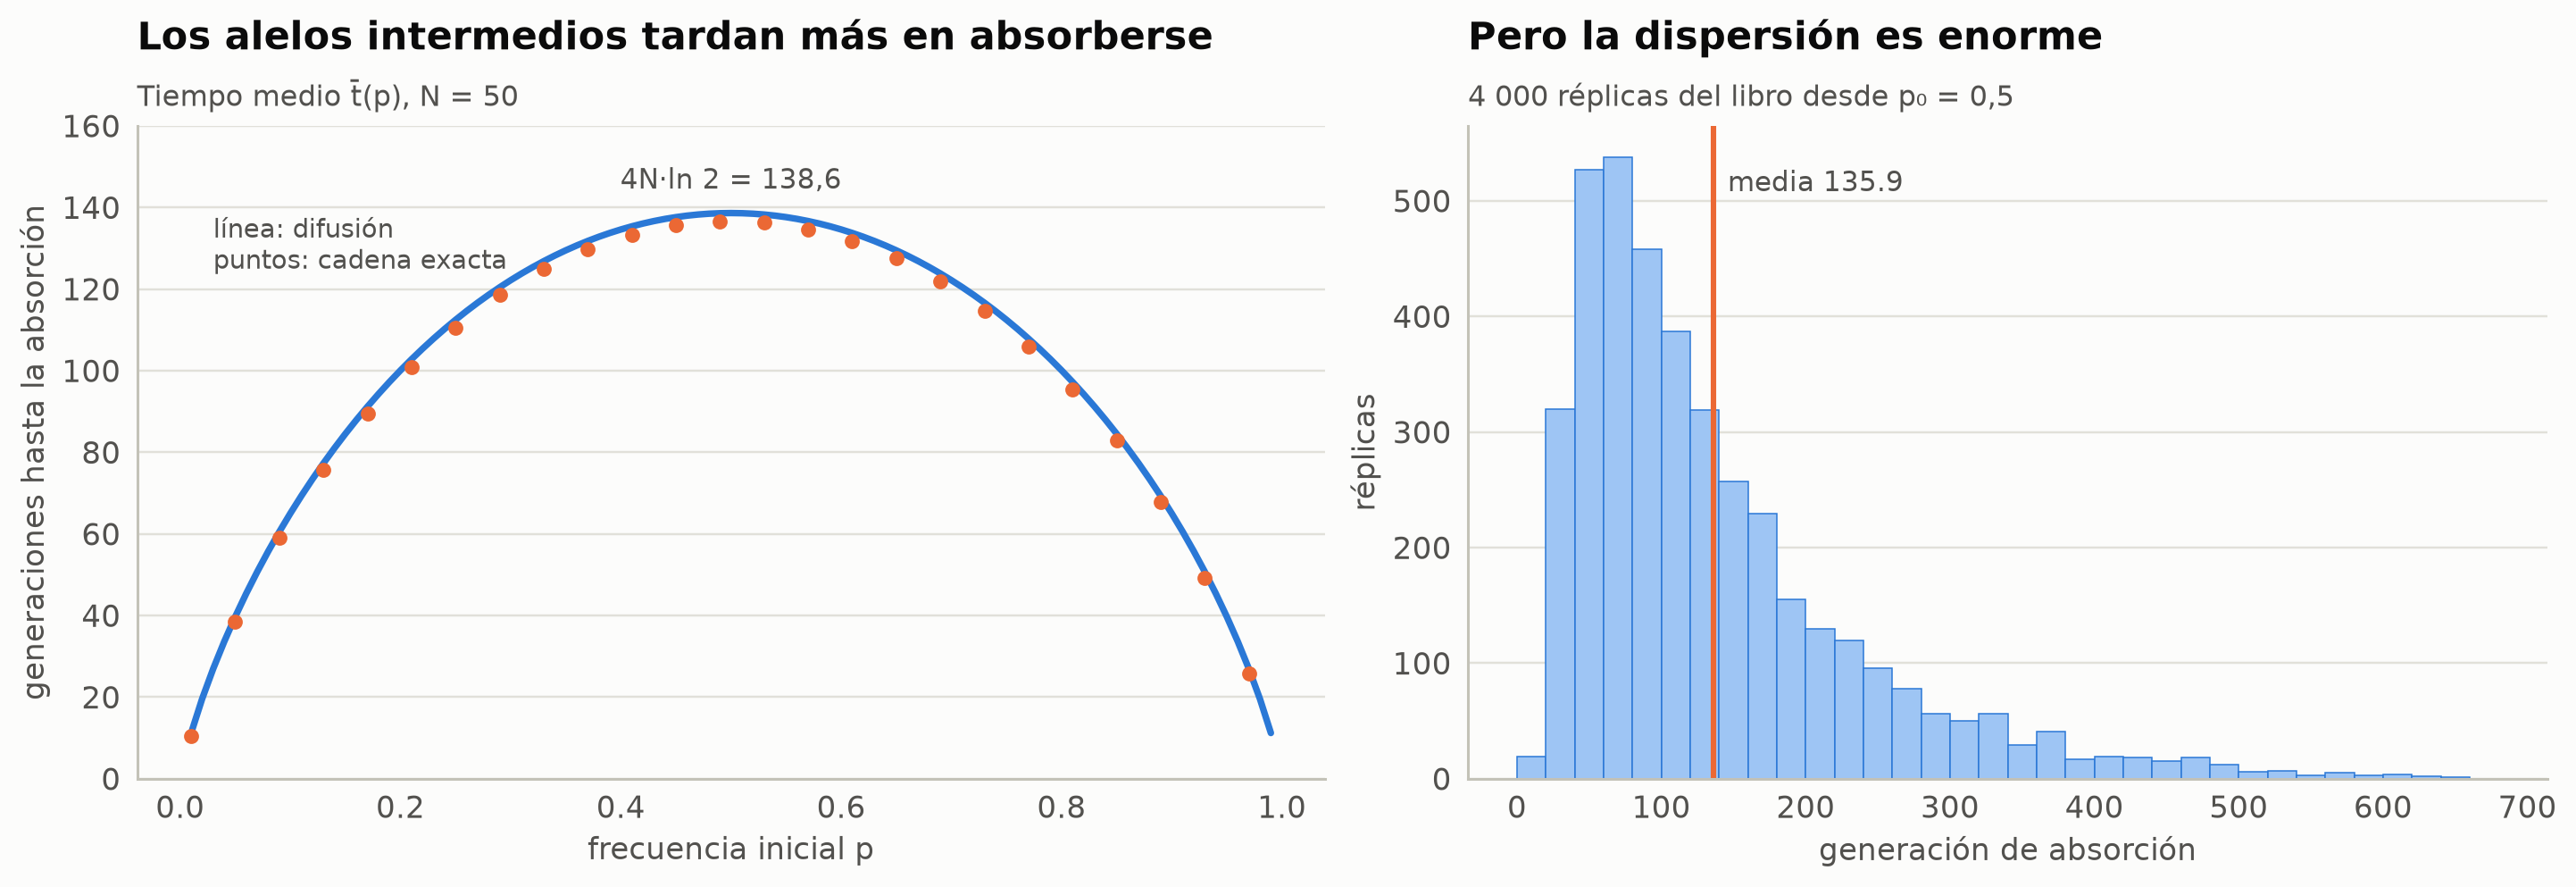

In [23]:
Q = P_wf[1:-1, 1:-1]
t_exact = np.linalg.solve(np.eye(len(Q)) - Q, np.ones(len(Q)))       # tiempo medio exacto desde cada estado
p_grid = states[1:-1] / (2 * N_d)
t_diff = -4 * N_d * (p_grid * np.log(p_grid) + (1 - p_grid) * np.log(1 - p_grid))
print(f"N = 50, p = 1/2: difusión {t_diff[N_d - 1]:.1f} · cadena exacta {t_exact[N_d - 1]:.1f} · "
      f"simulación del libro {BOOK['t_abs'].mean():.1f}   (libro: 138,6 y 135,9)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw=dict(width_ratios=[1.1, 1]))
a1.plot(p_grid, t_diff, color=ec.BLUE, lw=2.4); a1.plot(p_grid[::4], t_exact[::4], "o", color=ec.ORANGE, ms=4.5)
a1.text(0.5, t_diff[N_d - 1] + 6, "4N·ln 2 = 138,6", ha="center", fontsize=10, color=ec.INK_2)
a1.text(0.03, 125, "línea: difusión\npuntos: cadena exacta", fontsize=9.5, color=ec.INK_2)
a1.set_xlabel("frecuencia inicial p"); a1.set_ylabel("generaciones hasta la absorción"); a1.set_ylim(0, 160)
ec.title(a1, "Los alelos intermedios tardan más en absorberse", "Tiempo medio t̄(p), N = 50")
a2.hist(BOOK["t_abs"], bins=np.arange(0, 700, 20), color="#9ec5f4", edgecolor=ec.BLUE, linewidth=0.5)
a2.axvline(BOOK["t_abs"].mean(), color=ec.ORANGE, lw=2)
a2.text(BOOK["t_abs"].mean() + 10, a2.get_ylim()[1] * 0.9, f"media {BOOK['t_abs'].mean():.1f}", fontsize=10, color=ec.INK_2)
a2.set_xlabel("generación de absorción"); a2.set_ylabel("réplicas")
ec.title(a2, "Pero la dispersión es enorme", "4 000 réplicas del libro desde p₀ = 0,5")
plt.show()

> 🔎 **Qué observamos.** La difusión (138,6) sobrestima ligeramente el tiempo exacto de una población tan pequeña
> como $N=50$; la cadena exacta y la simulación coinciden. La distribución de tiempos tiene una cola larga: algunas
> réplicas tardan más de 500 generaciones. Una mutación neutral nueva que **sí** llega a fijarse tarda en promedio
> unas $4N$ generaciones: en humanos, cientos de miles de años. Por eso la mayor parte de la variación que vemos hoy
> es **antigua y compartida** entre poblaciones, algo que comprobaremos en la sección 8.

> 🔬 **Para profundizar: el coalescente, la deriva mirada hacia atrás.** En lugar de seguir frecuencias hacia
> adelante, se pueden seguir hacia atrás los linajes de una **muestra**, como en la genealogía de la sección 4.
> Kingman (1982) demostró que, con $N$ grande y el tiempo medido en unidades de $2N$ generaciones, mientras quedan $k$
> linajes cada par coalesce a tasa 1:
> $\mathbb E[T_k]=\dfrac{4N}{k(k-1)}$ generaciones y
> $\mathbb E[T_{\text{MRCA}}]=\sum_{k=2}^{n}\dfrac{4N}{k(k-1)}=4N\left(1-\dfrac1n\right)$.
> El ancestro común más reciente de 100 copias ($3{,}96N$) es apenas un 10 % más antiguo que el de dos ($2N$): más de
> la mitad de la historia de la muestra transcurre cuando solo quedan dos linajes. Si las mutaciones caen sobre las
> ramas a tasa $\mu$, dos copias difieren en promedio en $\theta=4N\mu$ posiciones. El coalescente es hoy el motor de
> casi todos los simuladores de genomas de poblaciones.

In [24]:
for n in (2, 10, 100):
    print(f"n = {n:>3}: E[T_MRCA] = 4N(1 − 1/n) = {4 * (1 - 1 / n):.3f} N · longitud total esperada del árbol "
          f"4N·Σ1/i = {4 * sum(1 / i for i in range(1, n)):.3f} N")

n =   2: E[T_MRCA] = 4N(1 − 1/n) = 2.000 N · longitud total esperada del árbol 4N·Σ1/i = 4.000 N
n =  10: E[T_MRCA] = 4N(1 − 1/n) = 3.600 N · longitud total esperada del árbol 4N·Σ1/i = 11.316 N
n = 100: E[T_MRCA] = 4N(1 − 1/n) = 3.960 N · longitud total esperada del árbol 4N·Σ1/i = 20.710 N


## 8. Datos reales: el Proyecto 1000 Genomas

La fase 3 del Proyecto 1000 Genomas secuenció a **2 504 personas de 26 poblaciones**, agrupadas en cinco
superpoblaciones: África (AFR), las Américas (AMR), Asia oriental (EAS), Europa (EUR) y Asia meridional (SAS)
(The 1000 Genomes Project Consortium, 2015). El curso incluye dos extractos (coordenadas GRCh37):

* `1000G_chr22_thinned_genotypes.npz`: una matriz $2\,504\times3\,292$ de genotipos $g\in\{0,1,2\}$ (copias del alelo
  alternativo) de SNP bialélicos del cromosoma 22 con **MAF ≥ 5 % en el conjunto mundial**, separados al menos 10 kb;
* `1000G_chr2_LCT_136.3-136.9Mb.vcf.gz`: 907 SNP faseados de la región de la **lactasa** (*LCT/MCM6*);
* `1000G_phase3_panel.tsv`: población y superpoblación de cada persona.

Con ellos haremos tres cosas: contrastar Hardy-Weinberg población por población y al mezclar poblaciones, medir la
diversidad de cada población y comparar sus espectros de frecuencias.

In [25]:
panel = pd.read_csv(course_file("1000G_phase3_panel.tsv"), sep="\t", usecols=["sample", "pop", "super_pop", "gender"])
npz = np.load(course_file("1000G_chr22_thinned_genotypes.npz"))
G22 = npz["genotypes"]
assert (npz["samples"] == panel["sample"].values).all()
print(str(npz["description"]))
print("genotipos:", G22.shape, "· valores:", np.unique(G22))
SUPER_COLORS = {"AFR": ec.ORANGE, "AMR": ec.MAGENTA, "EAS": ec.GREEN, "EUR": ec.BLUE, "SAS": ec.VIOLET}
POP_SUPER = panel.drop_duplicates("pop").set_index("pop")["super_pop"].to_dict()
ADMIXED = {"ACB", "ASW", "CLM", "MXL", "PUR", "PEL"}   # poblaciones con ancestría mezclada reciente
panel.groupby("super_pop")["pop"].agg(["nunique", "size"]).rename(columns={"nunique": "poblaciones", "size": "personas"})

1000 Genomes phase 3 (GRCh37), chr22, SNPs bialélicos MAF>=0.05 espaciados >=10 kb; genotipos 0/1/2 = copias del alelo ALT; filas = muestras
genotipos: (2504, 3292) · valores: [0 1 2]


,poblaciones,personas
super_pop,,
AFR,7,661
AMR,4,347
EAS,5,504
EUR,5,503
SAS,5,489


### 8.1 Un ejemplo resuelto: la variante de persistencia de la lactasa

La mayoría de los mamíferos, y la mayoría de los humanos, deja de producir lactasa tras el destete. En algunas
poblaciones con tradición ganadera, la enzima persiste en la edad adulta. En europeos, el principal determinante es la
variante −13910 C>T (rs4988235), en un intrón de *MCM6* que actúa como potenciador de *LCT*. El haplotipo que la
porta es inusualmente largo para su frecuencia, la firma de un **barrido selectivo** reciente (Bersaglieri et al.,
2004), que estudiaremos en la Lección 10.2.

En nuestro VCF aparece como `2:136608646 G>A`: la hebra + del genoma tiene G/A, y *LCT* se lee en la hebra −, donde
es C/T. Llamaremos $A$ al alelo **de persistencia** (`A` en la hebra +, `T` en la de *LCT*) y $a$ al ancestral, de
modo que $g$ = número de copias de $A$.

In [26]:
LCT_POS = "136608646"
with gzip.open(course_file("1000G_chr2_LCT_136.3-136.9Mb.vcf.gz"), "rt") as fh:
    for line in fh:
        if line.startswith("#CHROM"):
            vcf_samples = line.rstrip("\n").split("\t")[9:]
        elif line.startswith("2\t" + LCT_POS + "\t"):
            fields = line.rstrip("\n").split("\t"); break
print("\t".join(fields[:8])[:160], "…")
g_lct = np.array([gt.count("1") for gt in fields[9:]])          # "0|1" → 1 copia de A (ALT)
assert vcf_samples == list(panel["sample"])

def geno_counts(g):
    """(n_AA, n_Aa, n_aa) con A = alelo contado en g (0/1/2 copias)."""
    return int((g == 2).sum()), int((g == 1).sum()), int((g == 0).sum())

def hwe_row(g):
    n_AA, n_Aa, n_aa = geno_counts(g)
    n = n_AA + n_Aa + n_aa; p = (2 * n_AA + n_Aa) / (2 * n)
    poly = 0 < p < 1
    return dict(n=n, AA=n_AA, Aa=n_Aa, aa=n_aa, p=p,
                H_obs=n_Aa / n, H_exp=2 * p * (1 - p),
                F=(1 - (n_Aa / n) / (2 * p * (1 - p))) if poly else np.nan,
                p_exact=hwe_exact(n_Aa, n_AA, n_aa) if poly else np.nan)

ceu = hwe_row(g_lct[panel["pop"].values == "CEU"])
ceu

2	136608646	.	G	A	100	PASS	AC=808;AF=0.161342;AN=5008;NS=2504;DP=21221;EAS_AF=0;AMR_AF=0.2161;AFR_AF=0.0272;EUR_AF=0.508;SAS_AF=0.1135;AA=G|||;VT=SNP …


{'n': 99,
 'AA': 54,
 'Aa': 38,
 'aa': 7,
 'p': 0.7373737373737373,
 'H_obs': 0.3838383838383838,
 'H_exp': 0.38730741761044796,
 'F': 0.008956796628029728,
 'p_exact': np.float64(0.9999999999999998)}

**A mano, para los 99 residentes de Utah de ascendencia europea del norte (CEU).** Hay 54 $AA$, 38 $Aa$ y 7 $aa$.
$\hat p=(2\cdot54+38)/198=146/198=0{,}737$. Esperados: $99\cdot0{,}737^2=53{,}8$, $2\cdot99\cdot0{,}737\cdot0{,}263=38{,}4$ y
$99\cdot0{,}263^2=6{,}8$: casi idénticos a lo observado. El equilibrio se cumple perfectamente ($p_{\text{exacto}}=1$).

> 🤔 **Antes de ejecutar, prediga.** Si juntamos a las cinco poblaciones europeas (del norte y del sur) en una sola
> muestra, ¿seguirá la variante en equilibrio? ¿Y si juntamos a las 2 504 personas?

In [27]:
rows = {}
for pop in sorted(panel["pop"].unique()):
    rows[pop] = {"super": POP_SUPER[pop], **hwe_row(g_lct[panel["pop"].values == pop])}
for sp in ("EUR",):
    rows[f"{sp} juntas"] = {"super": sp, **hwe_row(g_lct[panel["super_pop"].values == sp])}
rows["las 26 juntas"] = {"super": "todas", **hwe_row(g_lct)}
lct = pd.DataFrame.from_dict(rows, orient="index").infer_objects()
lct_show = lct.copy()
lct_show["p_exact"] = lct_show["p_exact"].map(lambda v: "monomórfica" if pd.isna(v) else f"{v:.2g}")
lct_show[["super", "n", "AA", "Aa", "aa", "p", "H_obs", "H_exp", "F", "p_exact"]].sort_values(["super", "p"]).round(3)

,super,n,AA,Aa,aa,p,H_obs,H_exp,F,p_exact
ESN,AFR,99,0,0,99,0.000,0.000,0.000,NaN,monomórfica
LWK,AFR,99,0,0,99,0.000,0.000,0.000,NaN,monomórfica
MSL,AFR,85,0,0,85,0.000,0.000,0.000,NaN,monomórfica
YRI,AFR,108,0,0,108,0.000,0.000,0.000,NaN,monomórfica
GWD,AFR,113,0,2,111,0.009,0.018,0.018,-0.009,1
ACB,AFR,96,1,11,84,0.068,0.115,0.126,0.092,0.35
ASW,AFR,61,3,15,43,0.172,0.246,0.285,0.137,0.36
PEL,AMR,85,2,14,69,0.106,0.165,0.189,0.130,0.22
PUR,AMR,104,3,37,64,0.207,0.356,0.328,-0.085,0.55
MXL,AMR,64,4,23,37,0.242,0.359,0.367,0.021,1


> 🔎 **Qué observamos.** La frecuencia del alelo de persistencia va de 0 en Asia oriental y en casi toda África
> occidental a 0,74 en CEU. **Ninguna** de las 26 poblaciones se desvía del equilibrio (la más baja, CLM, tiene
> $p=0{,}05$). Pero las cinco europeas juntas dan $p\approx10^{-8}$, y las 2 504 personas juntas, $p\approx10^{-67}$:
> es el **efecto Wahlund**. Al mezclar grupos con frecuencias distintas faltan heterocigotos, aunque cada grupo esté
> en equilibrio. Dentro de Europa hay un gradiente norte-sur (TSI, toscanos, 0,09; FIN, GBR y CEU, 0,6–0,74).

**El efecto Wahlund, en una fórmula.** Si cada subpoblación $i$ (con peso $w_i$) está en equilibrio, la
heterocigosidad de la mezcla es $\sum_i w_i\,2p_iq_i$, mientras que la que esperaríamos con la frecuencia media
$\bar p$ es $2\bar p\bar q$. La diferencia es exactamente el doble de la **varianza** de las frecuencias entre
subpoblaciones:

$$
2\bar p\bar q-\sum_i w_i\,2p_iq_i=2\operatorname{Var}_w(p_i),\qquad \hat F_{\text{mezcla}}\approx\frac{\operatorname{Var}_w(p_i)}{\bar p\bar q},
$$

que es la definición de $F_{ST}$ de Wright, protagonista de la Lección 10.2. Comprobémoslo con los europeos:

In [28]:
eur_pops = [p for p in lct.index if POP_SUPER.get(p) == "EUR"]
w = lct.loc[eur_pops, "n"].astype(float); w = w / w.sum()
p_i = lct.loc[eur_pops, "p"].astype(float)
p_bar = (w * p_i).sum()
var_p = (w * (p_i - p_bar) ** 2).sum()
H_mix_pred = (w * 2 * p_i * (1 - p_i)).sum()
print(f"p̄ = {p_bar:.4f} · Var(p_i) = {var_p:.4f}")
print(f"déficit predicho 2·Var = {2 * var_p:.4f} · déficit observado 2p̄q̄ − H_obs = "
      f"{2 * p_bar * (1 - p_bar) - lct.loc['EUR juntas', 'H_obs']:.4f}")
print(f"F de la mezcla: predicho Var/(p̄q̄) = {var_p / (p_bar * (1 - p_bar)):.3f} · observado = {lct.loc['EUR juntas', 'F']:.3f}")

p̄ = 0.5080 · Var(p_i) = 0.0577
déficit predicho 2·Var = 0.1155 · déficit observado 2p̄q̄ − H_obs = 0.1281
F de la mezcla: predicho Var/(p̄q̄) = 0.231 · observado = 0.256


> 🔎 **Qué observamos.** La varianza de las frecuencias entre las cinco poblaciones europeas explica la mayor parte
> del déficit de heterocigotos de la mezcla (0,116 de 0,128). El resto viene de que cada población, a su vez, tiene
> por azar muestral algo menos heterocigotos de los esperados (compare `H_obs` y `H_exp` de TSI, IBS o CEU en la tabla).

### 🎛️ Las 26 poblaciones en el triángulo de De Finetti

Cada punto es una población, coloreada por superpoblación; las estrellas son las dos mezclas. Pase el ratón para ver
los recuentos, la frecuencia del alelo de persistencia, $\hat F$ y el valor $p$ exacto. Las poblaciones sin el
alelo se amontonan en el vértice $aa$.

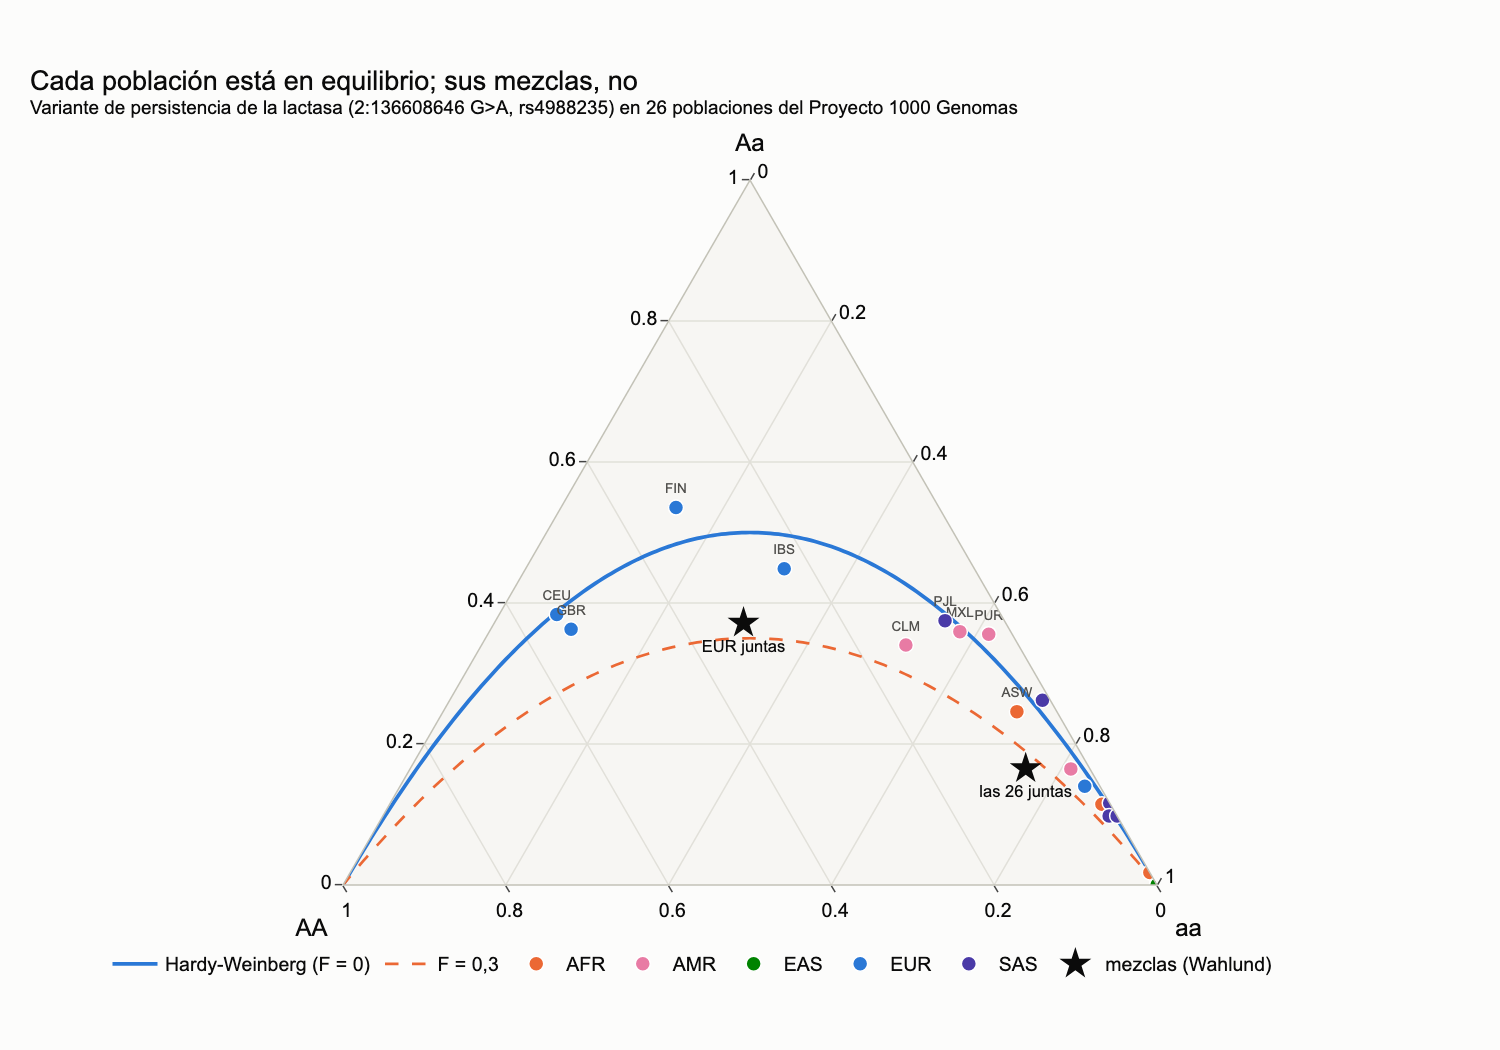

In [29]:
pp = np.linspace(0, 1, 201)
fig = go.Figure()
fig.add_trace(go.Scatterternary(a=2 * pp * (1 - pp), b=pp ** 2, c=(1 - pp) ** 2, mode="lines", name="Hardy-Weinberg (F = 0)",
                                line=dict(color=ec.BLUE, width=2.5), hoverinfo="skip"))
fig.add_trace(go.Scatterternary(a=2 * pp * (1 - pp) * 0.7, b=pp ** 2 + 0.3 * pp * (1 - pp), c=(1 - pp) ** 2 + 0.3 * pp * (1 - pp),
                                mode="lines", name="F = 0,3", line=dict(color=ec.ORANGE, width=1.8, dash="dash"), hoverinfo="skip"))

def hover_text(name, r):
    test = "monomórfica: no hay nada que probar" if pd.isna(r["p_exact"]) else f"HWE exacta: p = {r['p_exact']:.2g}"
    F_txt = "—" if pd.isna(r["F"]) else f"{r['F']:.3f}"
    return (f"<b>{name}</b> ({r['super']}, n = {r['n']})<br>AA {r['AA']} · Aa {r['Aa']} · aa {r['aa']}"
            f"<br>frecuencia del alelo de persistencia p = {r['p']:.3f}<br>H_obs = {r['H_obs']:.3f} · 2pq = {r['H_exp']:.3f}"
            f"<br>F̂ = {F_txt} · {test}")

for sp, col in SUPER_COLORS.items():
    d = lct[(lct["super"] == sp) & ~lct.index.str.contains("juntas")]
    fig.add_trace(go.Scatterternary(
        a=(d["Aa"] / d["n"]).astype(float), b=(d["AA"] / d["n"]).astype(float), c=(d["aa"] / d["n"]).astype(float),
        mode="markers+text", text=[k if r["p"] >= 0.15 else "" for k, r in d.iterrows()],   # etiqueta solo fuera del vértice aa
        textposition="top center", textfont=dict(size=9, color=ec.INK_2),
        name=sp, marker=dict(size=10, color=col, line=dict(width=1, color="white")),
        hovertext=[hover_text(k, r) for k, r in d.iterrows()], hoverinfo="text"))
mix = lct.loc[["EUR juntas", "las 26 juntas"]]
fig.add_trace(go.Scatterternary(
    a=(mix["Aa"] / mix["n"]).astype(float), b=(mix["AA"] / mix["n"]).astype(float), c=(mix["aa"] / mix["n"]).astype(float),
    mode="markers+text", text=["EUR juntas", "las 26 juntas"], textposition="bottom center", name="mezclas (Wahlund)",
    marker=dict(size=16, symbol="star", color=ec.INK), textfont=dict(size=11),
    hovertext=[hover_text(k, r) + "<br><i>déficit de heterocigotos por mezclar poblaciones</i>" for k, r in mix.iterrows()],
    hoverinfo="text"))
fig.update_layout(
    ternary=dict(sum=1, aaxis=dict(title="Aa", min=0, linecolor=ec.BASELINE, gridcolor=ec.GRID),
                 baxis=dict(title="AA", min=0, linecolor=ec.BASELINE, gridcolor=ec.GRID),
                 caxis=dict(title="aa", min=0, linecolor=ec.BASELINE, gridcolor=ec.GRID), bgcolor="#f7f6f3"),
    title="Cada población está en equilibrio; sus mezclas, no<br><sup>Variante de persistencia de la lactasa "
          "(2:136608646 G>A, rs4988235) en 26 poblaciones del Proyecto 1000 Genomas</sup>",
    legend=dict(orientation="h", yanchor="top", y=-0.08, x=0), height=700, margin=dict(t=120, l=70, r=70, b=110))
fig.show()

> 🔎 **Qué observamos.** Las 26 poblaciones caen sobre la parábola, repartidas a lo largo de ella según su
> frecuencia: las europeas del norte cerca del vértice $AA$, las asiáticas orientales y africanas occidentales en el
> vértice $aa$, las americanas y surasiáticas en medio. Las dos estrellas, en cambio, quedan **por debajo**: la mezcla
> mundial cae incluso algo más abajo que la curva discontinua $F=0{,}3$ (su $\hat F$ observado es $0{,}389$) sin que
> nadie se haya casado con un pariente.

> ✅ **Compruebe su comprensión.** Un estudio de casos y controles recluta los casos en Finlandia y los controles en
> Italia. ¿Qué pasará con el filtro de Hardy-Weinberg aplicado a toda la muestra, y qué problema mucho más grave
> anuncia? *(Muchas variantes con frecuencias distintas entre ambos países fallarán el filtro por efecto Wahlund; y
> todas ellas parecerán «asociadas» con la enfermedad: es la **estratificación poblacional**, el gran enemigo de los
> GWAS de la Lección 10.3.)*

### 8.2 El efecto Wahlund en todo el cromosoma 22

Pasemos de una variante a 3 292. Para cada grupo (cada población, cada superpoblación y la mezcla mundial)
contamos qué fracción de los SNP **polimórficos en ese grupo** falla la prueba exacta a $p<0{,}01$. Si todo
estuviera en equilibrio esperaríamos como mucho un 1 % (algo menos, porque la prueba exacta es conservadora).

> 🤔 **Antes de ejecutar, prediga.** ¿Qué fracción de SNP fallará en la mezcla de las 2 504 personas: 2 %, 10 % o
> más de la mitad?

In [30]:
def hwe_scan(G):
    """Valor p exacto de HWE para cada columna (SNP) de una matriz de genotipos 0/1/2; NaN si es monomórfica."""
    n2 = (G == 2).sum(0); n1 = (G == 1).sum(0); n0 = (G == 0).sum(0)
    out = np.full(G.shape[1], np.nan)
    for j in range(G.shape[1]):
        if n1[j] + n2[j] > 0 and n1[j] + n0[j] > 0:
            out[j] = hwe_exact(int(n1[j]), int(n2[j]), int(n0[j]))
    return out

def mean_F(G):
    q = G.mean(0) / 2; H_exp = 2 * q * (1 - q); ok = H_exp > 0
    return 1 - (G[:, ok] == 1).mean(0).mean() / H_exp[ok].mean()

groups = [(pop, "población", panel["pop"].values == pop) for pop in sorted(panel["pop"].unique())]
groups += [(sp, "superpoblación", panel["super_pop"].values == sp) for sp in sorted(panel["super_pop"].unique())]
groups += [("TODAS", "mundo", np.ones(len(panel), bool))]
scan = []
for name, level, mask in groups:
    pv = hwe_scan(G22[mask])
    ok = ~np.isnan(pv)
    scan.append(dict(grupo=name, nivel=level, super=POP_SUPER.get(name, name), n=int(mask.sum()),
                     polimórficos=int(ok.sum()), falla_1pc=(pv[ok] < 0.01).mean(), falla_1e6=(pv[ok] < 1e-6).mean(),
                     F_medio=mean_F(G22[mask]), pvals=pv))
scan = pd.DataFrame(scan)
scan.drop(columns="pvals").groupby("nivel", sort=False).agg(
    grupos=("grupo", "size"), falla_1pc_media=("falla_1pc", "mean"), falla_1e6_media=("falla_1e6", "mean"),
    F_medio=("F_medio", "mean")).round(4)

,grupos,falla_1pc_media,falla_1e6_media,F_medio
nivel,,,,
población,26,0.0295,0.0114,0.0025
superpoblación,5,0.0581,0.0265,0.0160
mundo,1,0.6838,0.4010,0.1009


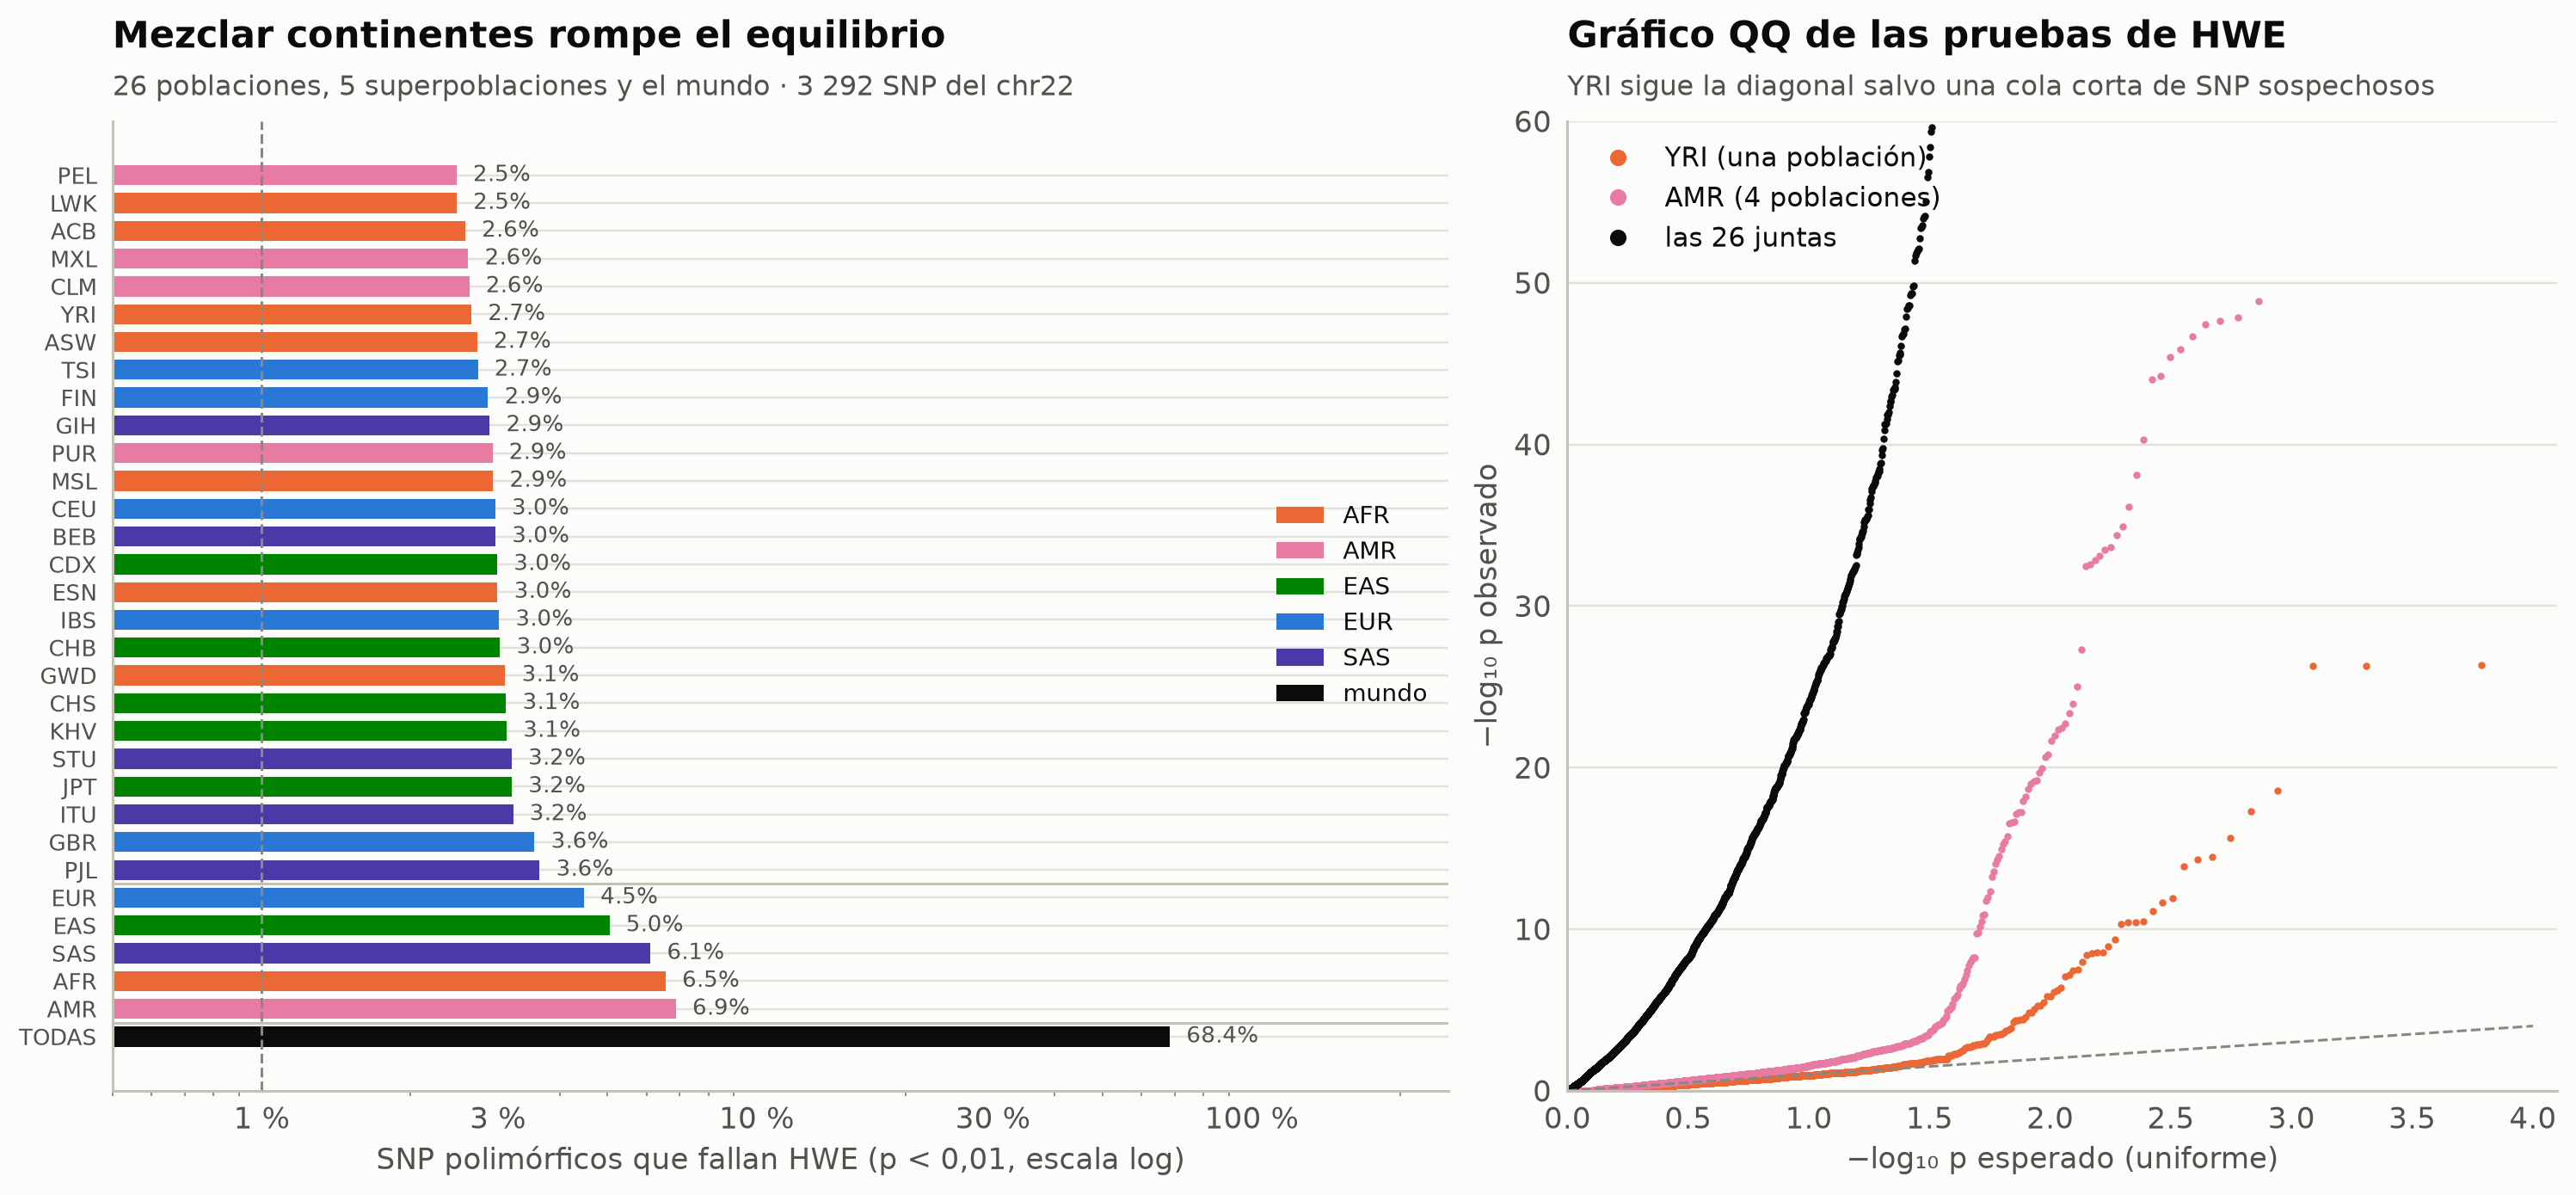

In [31]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 6.2), gridspec_kw=dict(width_ratios=[1.35, 1]))
d = scan.sort_values(["nivel", "falla_1pc"], key=lambda c: c.map({"población": 0, "superpoblación": 1, "mundo": 2}) if c.name == "nivel" else c)
ypos = np.arange(len(d))[::-1]
cols_ = [SUPER_COLORS.get(s, ec.INK) for s in d["super"]]
a1.barh(ypos, d["falla_1pc"] * 100, color=cols_, height=0.72)
for y_, (_, r) in zip(ypos, d.iterrows()):
    a1.text(r["falla_1pc"] * 100 * 1.08, y_, f"{r['falla_1pc']:.1%}", va="center", fontsize=8.5, color=ec.INK_2)
a1.set_yticks(ypos, [f"{g}" for g in d["grupo"]], fontsize=8.5)
a1.axvline(1, color=ec.MUTED, ls="--", lw=1); a1.set_xscale("log"); a1.set_xlim(0.5, 250)
a1.set_xticks([1, 3, 10, 30, 100], ["1 %", "3 %", "10 %", "30 %", "100 %"])
a1.set_xlabel("SNP polimórficos que fallan HWE (p < 0,01, escala log)")
n_pop = (scan["nivel"] == "población").sum()
a1.axhline(ypos[n_pop - 1] - 0.5, color=ec.BASELINE, lw=1); a1.axhline(ypos[n_pop + 4] - 0.5, color=ec.BASELINE, lw=1)
a1.legend(handles=[Patch(color=c, label=sp) for sp, c in SUPER_COLORS.items()] + [Patch(color=ec.INK, label="mundo")],
          frameon=False, loc="center right", fontsize=9)
ec.title(a1, "Mezclar continentes rompe el equilibrio", "26 poblaciones, 5 superpoblaciones y el mundo · 3 292 SNP del chr22")

for name, col, lab in (("YRI", ec.ORANGE, "YRI (una población)"), ("AMR", ec.MAGENTA, "AMR (4 poblaciones)"),
                       ("TODAS", ec.INK, "las 26 juntas")):
    pv = scan.set_index("grupo").loc[name, "pvals"]; pv = np.clip(np.sort(pv[~np.isnan(pv)]), 1e-300, 1)
    exp_ = -np.log10((np.arange(1, len(pv) + 1) - 0.5) / len(pv))
    a2.plot(exp_, -np.log10(pv), ".", ms=3.5, color=col, label=lab)
a2.plot([0, 4], [0, 4], color=ec.MUTED, lw=1, ls="--")
a2.set_xlabel("−log₁₀ p esperado (uniforme)"); a2.set_ylabel("−log₁₀ p observado"); a2.set_ylim(0, 60)
a2.legend(frameon=False, loc="upper left", markerscale=3)
a2.set_xlim(0, 4.1)
ec.title(a2, "Gráfico QQ de las pruebas de HWE", "YRI sigue la diagonal salvo una cola corta de SNP sospechosos")
plt.show()

> 🔎 **Qué observamos.** Dentro de cada población, solo el 2,5–3,6 % de los SNP falla a $p<0{,}01$ y $\hat F$ medio es
> prácticamente 0. Ese exceso está algo por encima del 1 % nominal; entre las explicaciones posibles están los errores de
> genotipado de una secuenciación de baja cobertura, parentescos no declarados o subestructura dentro de la propia
> muestra (hipótesis que no podemos distinguir con estos datos). En el gráfico QQ, YRI sigue la diagonal salvo
> un puñado de SNP con $p<10^{-10}$: justamente los que un control de calidad eliminaría. Al juntar las poblaciones de un continente la
> fracción sube un poco (4–7 %), y más en AMR, cuyas poblaciones mezclan ancestrías indígenas, europeas y africanas
> en proporciones distintas. Al juntar a todo el mundo, **dos de cada tres** SNP fallan y $\hat F\approx0{,}10$: la
> prueba de Hardy-Weinberg es, en la práctica, un detector de **estructura poblacional**. Por eso en un GWAS se aplica
> dentro de grupos de ancestría homogénea.

### 8.3 ¿Qué poblaciones son más diversas? El efecto fundador en serie

La heterocigosidad esperada media $\bar H=\overline{2pq}$ resume la diversidad de una población. Según la sección 5,
una población que pasó por cuellos de botella debería haber perdido heterocigosidad. La expansión humana fuera de
África fue precisamente una cadena de **fundaciones sucesivas**: grupos pequeños que se separaban para colonizar
territorios nuevos, llevándose solo una parte de la diversidad de su población de origen. La predicción es que la
diversidad debería **disminuir con la distancia a África** (Ramachandran et al., 2005), y el Proyecto 1000 Genomas
encontró que las personas de ancestría africana portan el mayor número de sitios variantes (The 1000 Genomes Project
Consortium, 2015).

> ⚠️ **Sesgo de verificación (*ascertainment bias*).** Nuestros SNP se eligieron por tener MAF ≥ 5 % **en el conjunto
> mundial**, y el 74 % de las 2 504 personas del proyecto no es africana. Un filtro así conserva sobre todo variantes
> comunes en Eurasia, muchas de ellas raras o ausentes en África, y excluye la mayoría de las variantes exclusivas de
> África (casi siempre raras). El resultado no es solo atenuar el contraste real: puede **invertirlo**. En este panel
> salen favorecidas las poblaciones cuyas frecuencias se parecen al promedio mundial (las del sur de Asia y las
> mezcladas). Cuando se secuencia sin filtrar por frecuencia, las poblaciones africanas son las más diversas (The 1000
> Genomes Project Consortium, 2015). Enseguida lo comprobaremos cambiando el filtro.

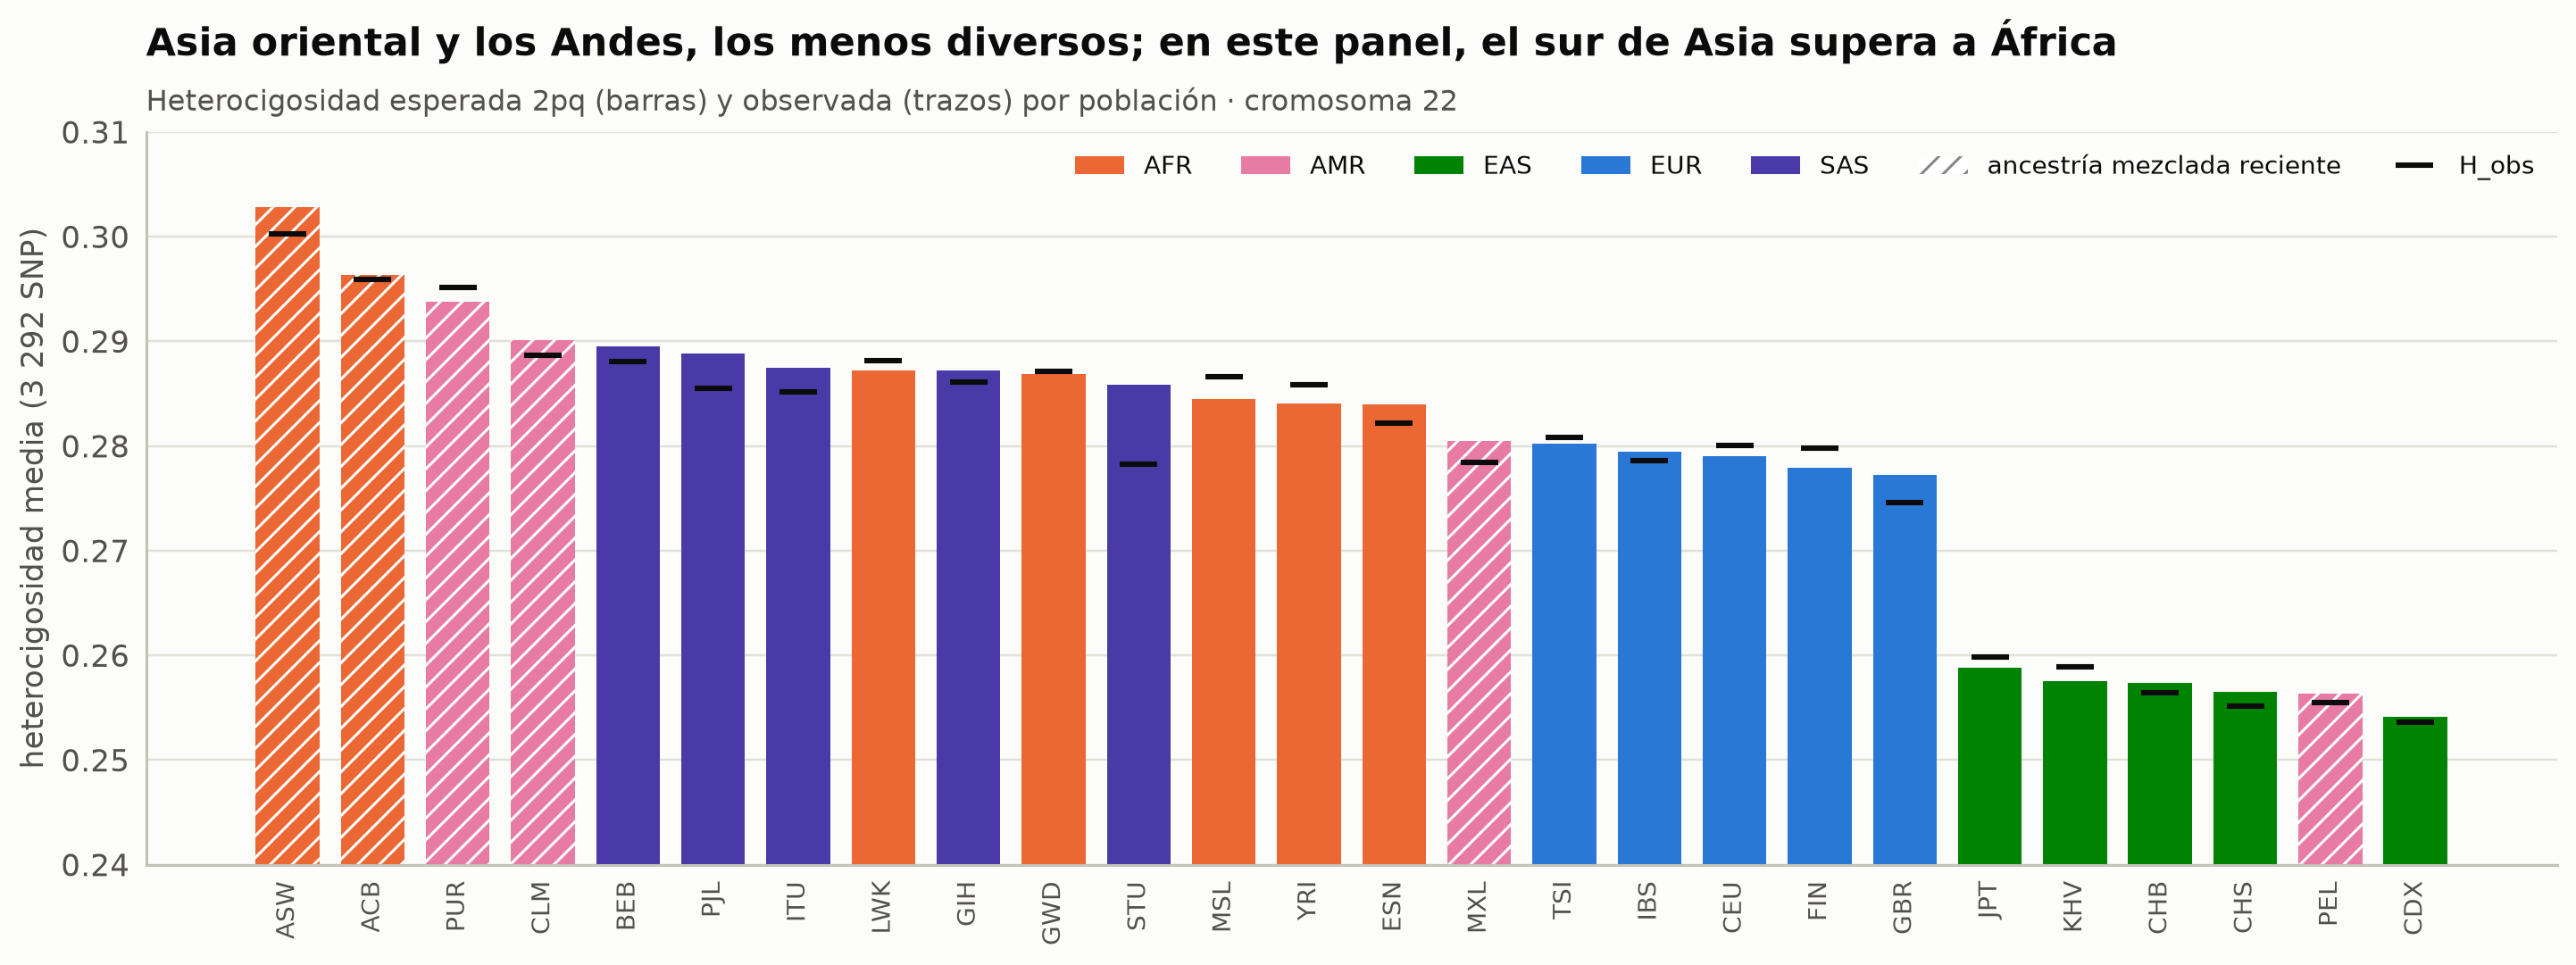

,min,max,mean
super,,,
AFR,0.2840,0.2873,0.2853
EAS,0.2541,0.2588,0.2569
EUR,0.2773,0.2802,0.2788
SAS,0.2859,0.2895,0.2878


In [32]:
div = []
for pop in sorted(panel["pop"].unique()):
    Gp = G22[panel["pop"].values == pop]
    q = Gp.mean(0) / 2
    div.append(dict(pop=pop, super=POP_SUPER[pop], H_exp=(2 * q * (1 - q)).mean(), H_obs=(Gp == 1).mean(),
                    monomorfos=((q == 0) | (q == 1)).mean(), mezclada=pop in ADMIXED))
div = pd.DataFrame(div).sort_values("H_exp", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 4.8))
x = np.arange(len(div))
for i, r in div.iterrows():
    ax.bar(i, r["H_exp"], color=SUPER_COLORS[r["super"]], width=0.75,
           hatch="///" if r["mezclada"] else None, edgecolor="white" if r["mezclada"] else SUPER_COLORS[r["super"]], lw=0)
ax.plot(x, div["H_obs"], "_", ms=14, mew=2, color=ec.INK)
ax.set_xticks(x, div["pop"], rotation=90, fontsize=9); ax.set_ylim(0.24, 0.31)
ax.set_ylabel("heterocigosidad media (3 292 SNP)")
handles = [Patch(color=c, label=sp) for sp, c in SUPER_COLORS.items()]
handles += [Patch(facecolor="white", edgecolor=ec.MUTED, hatch="///", label="ancestría mezclada reciente"),
            Line2D([], [], marker="_", ls="", ms=14, mew=2, color=ec.INK, label="H_obs")]
ax.legend(handles=handles, frameon=False, ncol=7, loc="upper right", fontsize=9)
ec.title(ax, "Asia oriental y los Andes, los menos diversos; en este panel, el sur de Asia supera a África",
         "Heterocigosidad esperada 2pq (barras) y observada (trazos) por población · cromosoma 22")
plt.show()
summ = div[~div["mezclada"]].groupby("super")["H_exp"].agg(["min", "max", "mean"]).round(4)
summ

> 🔎 **Qué observamos.** Entre las poblaciones sin mezcla reciente, las africanas (YRI, LWK, GWD, MSL, ESN) tienen
> $\bar H\approx0{,}284$–$0{,}287$; las europeas, $0{,}277$–$0{,}280$; las de Asia oriental, $0{,}254$–$0{,}259$: el
> descenso desde África hacia Asia oriental que predice el efecto fundador en serie. Los peruanos de Lima (PEL), con
> mucha ancestría indígena americana (el extremo del recorrido desde África), están junto a los asiáticos orientales.
> Pero el panel **no** pone a África en cabeza: las poblaciones del sur de Asia promedian $\bar H\approx0{,}288$ frente
> a $0{,}285$ en África (BEB, PJL e ITU superan a todas las africanas sin mezcla), y las poblaciones **mezcladas** (ACB,
> ASW, PUR, CLM) son las más heterocigotas de todas, porque mezclar ancestrías **suma** variantes de orígenes
> distintos. Es el sesgo de verificación en acción, no un rasgo de la historia humana. La observada (trazos) y la
> esperada coinciden en todas: cada población, por separado, está en equilibrio.

> 🤔 **Antes de ejecutar, prediga…** Si en vez del filtro mundial conserváramos solo los SNP con MAF ≥ 5 % **dentro de
> África** (o dentro de Europa), ¿qué superpoblación quedaría en cabeza en cada caso?

In [33]:
# El mismo cálculo con tres filtros distintos sobre los 3 292 SNP: el filtro decide el orden
def maf_within(mask):
    q = G22[mask].mean(0) / 2
    return np.minimum(q, 1 - q)

filters = {"MAF mundial ≥ 5 % (el panel)": np.ones(G22.shape[1], bool),
           "MAF ≥ 5 % dentro de AFR": maf_within(panel["super_pop"].values == "AFR") >= 0.05,
           "MAF ≥ 5 % dentro de EUR": maf_within(panel["super_pop"].values == "EUR") >= 0.05}
rows = {}
for name, keep in filters.items():
    H = pd.Series({pop: (2 * (q := G22[panel["pop"].values == pop][:, keep].mean(0) / 2) * (1 - q)).mean()
                   for pop in div.loc[~div["mezclada"], "pop"]})
    rows[f"{name} · {keep.sum()} SNP"] = H.groupby(H.index.map(POP_SUPER)).mean()
pd.DataFrame(rows).T.round(4)   # heterocigosidad media por superpoblación (poblaciones sin mezcla reciente)

,AFR,EAS,EUR,SAS
MAF mundial ≥ 5 % (el panel) · 3292 SNP,0.2853,0.2569,0.2788,0.2878
MAF ≥ 5 % dentro de AFR · 2754 SNP,0.3357,0.2595,0.2906,0.2957
MAF ≥ 5 % dentro de EUR · 2648 SNP,0.2872,0.2877,0.3389,0.3336


> 🔎 **Qué observamos.** Con el filtro mundial, el sur de Asia supera por poco a África. Si los SNP se eligen por ser
> comunes **en África**, África pasa a ser, con diferencia, la más heterocigota ($\bar H\approx0{,}336$ frente a
> $0{,}26$–$0{,}30$ en las demás); si se eligen por ser comunes **en Europa**, Europa encabeza la lista y África queda
> última, empatada con Asia oriental. La heterocigosidad de un panel de SNP mide, en parte, **cómo se eligieron los
> SNP**. Por eso las comparaciones de diversidad entre poblaciones se hacen con secuencias completas, sin filtrar por
> frecuencia, y por eso los chips de genotipado diseñados a partir de variantes europeas rinden peor en otras
> poblaciones.

### 8.4 Espectros de frecuencias alélicas

La deriva también cambia **la forma** de la distribución de frecuencias: en una población que pasó por cuellos de
botella, muchas variantes derivan hacia frecuencias bajas o se pierden. Comparemos el espectro de frecuencias del
alelo menos frecuente (MAF plegada) de cuatro poblaciones sin mezcla reciente de cuatro continentes y de PEL.

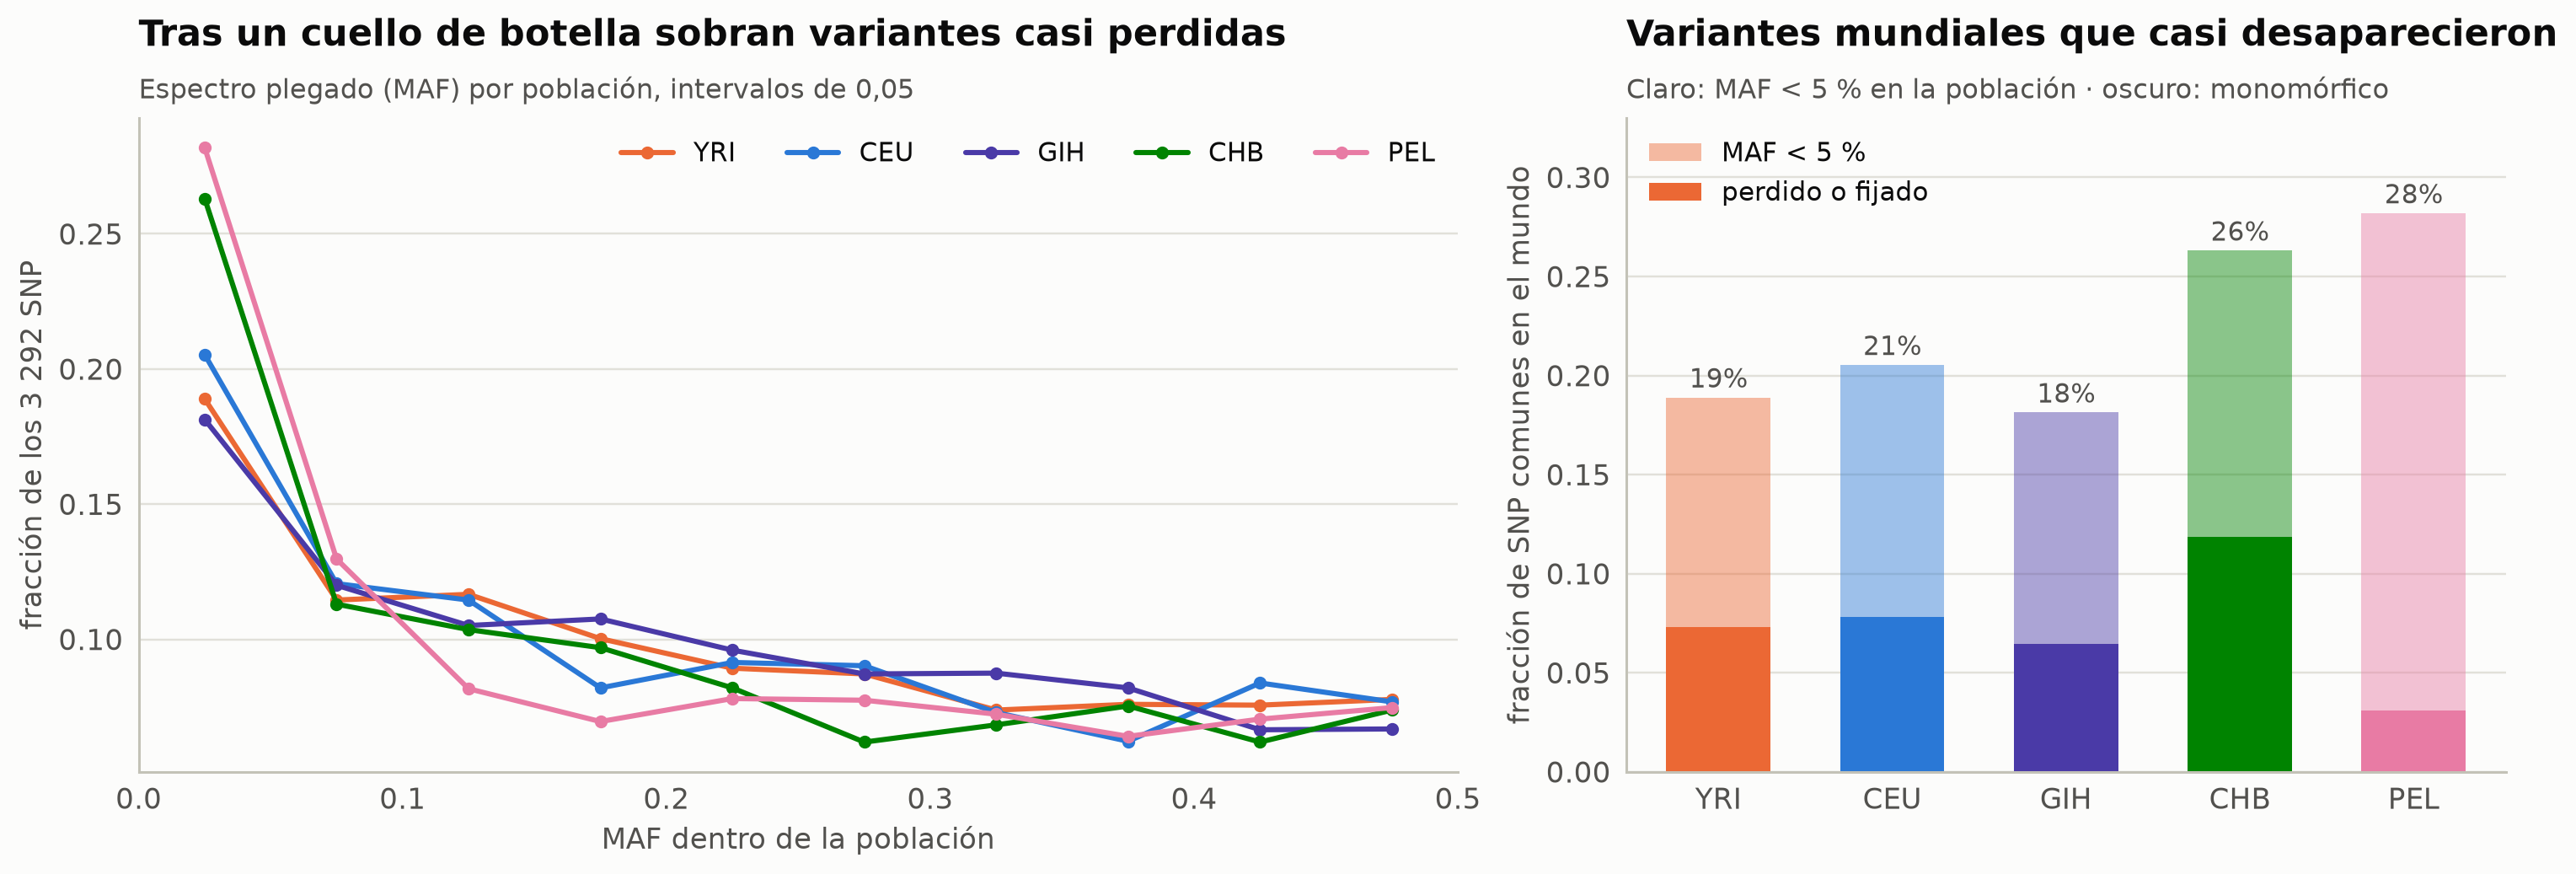

In [34]:
sfs_pops = [("YRI", ec.ORANGE), ("CEU", ec.BLUE), ("GIH", ec.VIOLET), ("CHB", ec.GREEN), ("PEL", ec.MAGENTA)]
edges_m = np.linspace(0, 0.5, 11)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.6), gridspec_kw=dict(width_ratios=[1.5, 1]))
low = {}
for pop, col in sfs_pops:
    q = G22[panel["pop"].values == pop].mean(0) / 2
    maf = np.minimum(q, 1 - q)
    h, _ = np.histogram(maf, bins=edges_m)
    a1.plot((edges_m[:-1] + edges_m[1:]) / 2, h / len(maf), "-o", ms=4, lw=2, color=col, label=pop)
    low[pop] = ((maf < 0.05).mean(), (maf == 0).mean())
a1.legend(frameon=False, ncol=5, loc="upper right")
a1.set_xlim(0, 0.5); a1.set_xlabel("MAF dentro de la población"); a1.set_ylabel("fracción de los 3 292 SNP")
a1.set_xticks(edges_m[::2])
ec.title(a1, "Tras un cuello de botella sobran variantes casi perdidas", "Espectro plegado (MAF) por población, intervalos de 0,05")
names = [p for p, _ in sfs_pops]
a2.bar(names, [low[p][0] for p in names], color=[c for _, c in sfs_pops], width=0.6, alpha=0.45, label="MAF < 5 %")
a2.bar(names, [low[p][1] for p in names], color=[c for _, c in sfs_pops], width=0.6, label="perdido o fijado")
for i, p in enumerate(names):
    a2.text(i, low[p][0] + 0.005, f"{low[p][0]:.0%}", ha="center", fontsize=10, color=ec.INK_2)
a2.set_ylim(0, 0.33); a2.set_ylabel("fracción de SNP comunes en el mundo"); a2.legend(frameon=False, loc="upper left")
ec.title(a2, "Variantes mundiales que casi desaparecieron", "Claro: MAF < 5 % en la población · oscuro: monomórfico")
plt.show()

> 🔎 **Qué observamos.** De los SNP que son comunes en el mundo, el 18–21 % es raro (MAF < 5 %) en YRI (18,9 %), GIH
> (18,1 %) y CEU (20,5 %), y el 7–8 % se perdió o se fijó del todo en YRI (7,3 %) y CEU (7,8 %): con este panel,
> África, Europa y Asia del Sur **no se distinguen**, por el mismo sesgo de verificación de la sección 8.3 (un SNP
> elegido por ser común en el mundo tiende a ser común en Eurasia, no necesariamente en África). La huella del efecto
> fundador en serie solo asoma al final del recorrido: en CHB y PEL el 26–28 % de los SNP es raro, y en CHB el 12 % se
> perdió o se fijó; allí la deriva empujó más variantes hacia los bordes, justo lo que predice la difusión de la
> sección 7. (En PEL hay pocos monomórficos porque su componente europea y africana reciente reintroduce alelos.) La
> mayor parte de las variantes, eso sí, sigue siendo **común en todas partes**: la variación humana es antigua y
> compartida.

## 9. 🏋️ Ejercicios

**Ejercicio 1 (a mano y con código).** Un banco de sangre genotipa a 400 donantes para un SNP: 190 $AA$, 150 $Aa$
y 60 $aa$. (a) Calcule a mano $\hat p$, los esperados y $X^2$. (b) Calcule $\hat F$ e interprételo. (c) Compare con la
prueba exacta usando `hwe_exact`.

**Ejercicio 2 (tamaño efectivo de un programa de cría).** Una población de lince pasa en cinco generaciones por
500, 40, 60, 800 y 1 000 reproductores. (a) Calcule $N_e$ por la media armónica. (b) Si en la generación de 40
reproductores solo hubo 8 machos, recalcule el $N_e$ de esa generación con la fórmula de sexos y repita (a).
(c) ¿Qué fracción de la heterocigosidad inicial queda, en promedio, al cabo de esas cinco generaciones?

**Ejercicio 3 (casi neutral).** Una mutación **perjudicial** nueva con $s=-0{,}001$ aparece en una sola copia. Con la
ecuación de Kimura, calcule su probabilidad de fijación relativa a la de una neutral ($1/2N$) para $N=100$, $1\,000$ y
$10\,000$. ¿Para qué tamaños se comporta «como neutral»? ¿Qué implica para especies de población pequeña?

**Ejercicio 4 (simulación).** Compruebe por simulación que $u(p_0)=p_0$ para $N=20$ y $p_0=0{,}2$ (use 5 000 réplicas
y 1 000 generaciones). Después verifique que el tiempo medio de absorción se parece a $\bar t(0{,}2)$.

**Ejercicio 5 (datos reales: ¿Wahlund o artefacto?).** En el cromosoma 22, busque el SNP con el mayor $\hat F$ en la
mezcla de las 2 504 personas. Muestre su frecuencia en cada superpoblación, cuente en cuántas de las 26 poblaciones
falla la prueba exacta y compare $\hat F$ con la predicción de Wahlund $\operatorname{Var}(p_i)/\bar p\bar q$. ¿Es un
efecto de la estructura poblacional o un problema técnico? Repita con el SNP de mayor $\operatorname{Var}(p_i)/\bar p\bar q$.

In [35]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
n_AA, n_Aa, n_aa = 190, 150, 60
r1 = hwe_chi2(n_AA, n_Aa, n_aa)
print(f"(a) p̂ = (2·190 + 150)/800 = {r1['p']:.4f} · esperados = {np.round(r1['expected'], 1)} · X² = {r1['X2']:.2f} · p = {r1['pval']:.2g}")
print(f"(b) F̂ = 1 − 150/{r1['expected'][1]:.1f} = {r1['F']:.3f}")
print(f"(c) p exacto = {hwe_exact(n_Aa, n_AA, n_aa):.2g}")
# p̂ = 0.6625; faltan unos 29 heterocigotos (F̂ ≈ 0.16). Con 400 donantes ambas pruebas rechazan con claridad.
# En un banco de sangre urbano, antes que endogamia sospecharíamos una mezcla de poblaciones (Wahlund) o un
# problema del ensayo; la muestra es grande, así que χ² y exacta coinciden.

(a) p̂ = (2·190 + 150)/800 = 0.6625 · esperados = [175.6 178.9  45.6] · X² = 10.42 · p = 0.0012
(b) F̂ = 1 − 150/178.9 = 0.161
(c) p exacto = 0.0017


In [36]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
sizes = [500, 40, 60, 800, 1000]
print(f"(a) N_e = {harmonic_Ne(sizes):.1f} (media aritmética {np.mean(sizes):.0f})")
ne_sex = 4 * 8 * 32 / 40
sizes_b = [500, ne_sex, 60, 800, 1000]
print(f"(b) generación con 8 machos y 32 hembras: N_e = {ne_sex:.1f} → N_e total = {harmonic_Ne(sizes_b):.1f}")
frac = np.prod([1 - 1 / (2 * n) for n in sizes_b])
print(f"(c) H_5/H_0 = Π(1 − 1/2N_t) = {frac:.4f}  → se pierde el {1 - frac:.1%}")
# La generación más pequeña domina: con el sesgo de sexos, el N_e cae aún más. Pocas generaciones de cuello de
# botella bastan para que la media armónica quede lejos del tamaño censal medio.

(a) N_e = 108.9 (media aritmética 480)
(b) generación con 8 machos y 32 hembras: N_e = 25.6 → N_e total = 83.4
(c) H_5/H_0 = Π(1 − 1/2N_t) = 0.9702  → se pierde el 3.0%


In [37]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
for N in (100, 1000, 10000):
    u = kimura_u(1 / (2 * N), N, -0.001)
    print(f"N = {N:>6}: 4Ns = {4 * N * -0.001:>6.1f} · u = {u:.3e} · u / (1/2N) = {u * 2 * N:.3f}")
# Con N = 100 (|4Ns| = 0.4) la mutación se fija casi tan a menudo como una neutral (≈ 0.82 veces);
# con N = 10 000 (|4Ns| = 40) casi nunca. En especies con N_e pequeño, las mutaciones levemente perjudiciales
# escapan a la selección y se acumulan: un argumento genético para mantener poblaciones grandes y conectadas.

N =    100: 4Ns =   -0.4 · u = 4.071e-03 · u / (1/2N) = 0.814
N =   1000: 4Ns =   -4.0 · u = 3.735e-05 · u / (1/2N) = 0.075
N =  10000: 4Ns =  -40.0 · u = 8.505e-21 · u / (1/2N) = 0.000


In [38]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
X4 = wright_fisher(20, 0.2, 1000, 5000, rng=np.random.default_rng(4))
fixed = (X4[-1] == 1).mean(); lost = (X4[-1] == 0).mean()
t_abs4 = ((X4 == 0) | (X4 == 1)).argmax(0)
t_theory = -4 * 20 * (0.2 * math.log(0.2) + 0.8 * math.log(0.8))
print(f"fijadas {fixed:.3f} (teoría 0,2) · perdidas {lost:.3f} · sin absorber {1 - fixed - lost:.4f}")
print(f"tiempo medio de absorción: simulación {t_abs4.mean():.1f} · difusión t̄(0,2) = {t_theory:.1f}")
# Como con N = 50, la difusión sobrestima un poco el tiempo exacto en poblaciones tan pequeñas.

fijadas 0.202 (teoría 0,2) · perdidas 0.798 · sin absorber 0.0000
tiempo medio de absorción: simulación 38.5 · difusión t̄(0,2) = 40.0


In [39]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
q_all = G22.mean(0) / 2
F_all = 1 - (G22 == 1).mean(0) / (2 * q_all * (1 - q_all))
pops_j = panel.groupby("pop").indices
w_j = np.array([len(ix) for ix in pops_j.values()]) / len(panel)
P_pop = np.array([G22[ix].mean(0) / 2 for ix in pops_j.values()])          # 26 x 3292 frecuencias
pbar = (w_j[:, None] * P_pop).sum(0)
wahlund = (w_j[:, None] * (P_pop - pbar) ** 2).sum(0) / (pbar * (1 - pbar))

def inspect(j, label):
    by_sp = pd.DataFrame({"q": G22[:, j] / 2, "super": panel["super_pop"]}).groupby("super")["q"].mean()
    pvals = np.array([hwe_row(G22[pops_j[pop], j])["p_exact"] for pop in pops_j])
    n_fail = int(np.sum(pvals[~np.isnan(pvals)] < 0.01))
    print(f"{label}: chr22:{npz['pos'][j]} {npz['ref'][j]}>{npz['alt'][j]} · F̂ mezcla = {F_all[j]:.3f} · "
          f"Wahlund Var/(p̄q̄) = {wahlund[j]:.3f} · poblaciones que fallan HWE: {n_fail}/26")
    print("   frecuencia de ALT por superpoblación:", {k: round(float(v), 3) for k, v in by_sp.items()})

inspect(int(np.nanargmax(F_all)), "mayor F̂")
inspect(int(np.nanargmax(wahlund)), "mayor Var(p_i)/p̄q̄")
# El SNP de mayor F̂ (≈ 0,9) falla HWE en muchas poblaciones y la estructura solo explica ≈ 0,2: casi no hay
# heterocigotos en ninguna parte. Es la firma de un artefacto técnico (p. ej., un error sistemático de genotipado),
# no de Wahlund. El SNP de mayor diferenciación, en cambio, tiene F̂ ≈ Var(p_i)/p̄q̄ y está en equilibrio dentro de
# casi todas las poblaciones: ese sí es un efecto Wahlund de libro. Moraleja: antes de interpretar un F̂ alto, mire
# dentro de los grupos.

mayor F̂: chr22:21836429 A>G · F̂ mezcla = 0.920 · Wahlund Var/(p̄q̄) = 0.218 · poblaciones que fallan HWE: 15/26
   frecuencia de ALT por superpoblación: {'AFR': 0.996, 'AMR': 0.98, 'EAS': 0.837, 'EUR': 0.991, 'SAS': 0.624}
mayor Var(p_i)/p̄q̄: chr22:36695942 C>T · F̂ mezcla = 0.557 · Wahlund Var/(p̄q̄) = 0.573 · poblaciones que fallan HWE: 0/26
   frecuencia de ALT por superpoblación: {'AFR': 0.265, 'AMR': 0.916, 'EAS': 0.999, 'EUR': 0.942, 'SAS': 0.986}


## 📌 Resumen

* Las frecuencias genotípicas determinan las alélicas, $p=P_{AA}+\tfrac12P_{Aa}$, pero no al revés; $H=2pq$ mide la
  diversidad de un locus.
* **Hardy-Weinberg**: con apareamiento aleatorio en una población infinita, $P_{AA}=p^2$, $P_{Aa}=2pq$, $P_{aa}=q^2$
  tras **una** generación, y $p$ no cambia. En el triángulo de De Finetti el equilibrio es una parábola.
* Se contrasta con $X^2$ (1 g.l.) o con la **prueba exacta** de Wigginton et al. El libro: (298, 489, 213) →
  $X^2=0{,}221$, $p=0{,}64$; (350, 380, 270) → $X^2=55{,}3$, $\hat F=0{,}235$; (91, 7, 2) → $p_{\chi^2}=0{,}0011$ frente a
  $p_{\text{exacto}}=0{,}0235$. Con alelos raros, $\chi^2$ rechaza de más.
* $F$ mide el déficit de heterocigotos: endogamia, errores de genotipado o **mezcla de poblaciones** (Wahlund:
  déficit $=2\operatorname{Var}(p_i)$).
* **Wright-Fisher**: $X_{t+1}\mid X_t\sim\text{Binomial}(2N,\,X_t/2N)$; $p_t$ es una martingala con varianza
  $p(1-p)/2N$ por generación; $u(p_0)=p_0$.
* **Heterocigosidad**: $H_t=H_0(1-1/2N)^t$. Población cautiva de 50: $H_{100}=0{,}183$ (−63 %), vida media 69 generaciones.
* **Tamaño efectivo**: media armónica y $4N_mN_f/(N_m+N_f)$; (1 000, 10, 1 000) → $N_e\approx29$; 10 machos y 90
  hembras → 36. Los cuellos de botella mandan.
* **Difusión de Kimura**: la distribución de $p_t$ se aplana y se escurre a los bordes ($N=50$, $t=100$: ≈ 23 % perdido,
  ≈ 23 % fijado, $\operatorname{Var}=0{,}1585$). $u(p)=(1-e^{-4Nsp})/(1-e^{-4Ns})$: decide $4Ns$, no $s$ ($N=10^4$,
  $s=0{,}01$: $u=0{,}0198$). $\bar t(1/2)=4N\ln2$ (138,6 para $N=50$).
* **1000 Genomas**: las 26 poblaciones están en equilibrio para la variante de la lactasa (frecuencia 0–0,74), pero
  su mezcla no ($p\approx10^{-67}$); en el chr22, el 2,5–3,6 % de los SNP falla dentro de cada población frente a dos de
  cada tres en la mezcla mundial. La heterocigosidad baja de África y Europa hacia Asia oriental y PEL, como predice el
  efecto fundador en serie, pero el filtro mundial de MAF (sesgo de verificación) coloca al sur de Asia por encima de
  África: basta elegir los SNP por su MAF dentro de África para que África vuelva a encabezar la lista. CHB y PEL,
  al final del recorrido, tienen más variantes empujadas a frecuencias bajas.

## 📚 Lecturas recomendadas

* Hardy, G. H. (1908). Mendelian proportions in a mixed population. *Science*, 28(706), 49–50.
  https://doi.org/10.1126/science.28.706.49
* Wigginton, J. E., Cutler, D. J. y Abecasis, G. R. (2005). A note on exact tests of Hardy-Weinberg equilibrium.
  *The American Journal of Human Genetics*, 76(5), 887–893. https://doi.org/10.1086/429864
* Fisher, R. A. (1930). *The genetical theory of natural selection*. Clarendon Press. https://doi.org/10.5962/bhl.title.27468
* Wright, S. (1931). Evolution in Mendelian populations. *Genetics*, 16(2), 97–159. https://doi.org/10.1093/genetics/16.2.97
* Kimura, M. (1955). Solution of a process of random genetic drift with a continuous model. *PNAS*, 41(3), 144–150.
  https://doi.org/10.1073/pnas.41.3.144
* Kimura, M. (1962). On the probability of fixation of mutant genes in a population. *Genetics*, 47(6), 713–719.
  https://doi.org/10.1093/genetics/47.6.713
* Kingman, J. F. C. (1982). The coalescent. *Stochastic Processes and their Applications*, 13(3), 235–248.
  https://doi.org/10.1016/0304-4149(82)90011-4
* The 1000 Genomes Project Consortium (2015). A global reference for human genetic variation. *Nature*, 526(7571),
  68–74. https://doi.org/10.1038/nature15393
* Ramachandran, S., Deshpande, O., Roseman, C. C., Rosenberg, N. A., Feldman, M. W. y Cavalli-Sforza, L. L. (2005).
  Support from the relationship of genetic and geographic distance in human populations for a serial founder effect
  originating in Africa. *PNAS*, 102(44), 15942–15947. https://doi.org/10.1073/pnas.0507611102
* Bersaglieri, T. et al. (2004). Genetic signatures of strong recent positive selection at the lactase gene. *The
  American Journal of Human Genetics*, 74(6), 1111–1120. https://doi.org/10.1086/421051
* Purcell, S. et al. (2007). PLINK: A tool set for whole-genome association and population-based linkage analyses.
  *The American Journal of Human Genetics*, 81(3), 559–575. https://doi.org/10.1086/519795
* Chang, C. C. et al. (2015). Second-generation PLINK: Rising to the challenge of larger and richer datasets.
  *GigaScience*, 4(1), 7. https://doi.org/10.1186/s13742-015-0047-8

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)